# <center> Redes neuronales para el Procesamiento del Lenguaje Natural </center>  


# Práctica 2: Redes convolucionales para el Procesamiento del Lenguage Natural
## Jesús Ferrándiz Alarcón

En esta práctica vamos a aborar un problema de Sentiment Analysis aplicado a un dataset
de reviews que pueden ser positivas o negativas.
Utilizaremos en concreto capas convolucionales,
compararemos representaciones de texto, exploraremos parámetros de las convoluciones y de las
redes neuronales y por último, emplearemos un mecanismo que sirva para explicar resultados del modelo.

**Adjunto también requirements.txt que son las dependencias que he usado. Sacado del virtualenv con el que he desarrollado, con pip freeze.**

# Imports
Comenzamos importando algunas dependencias.

In [1]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Carga del Dataset, introspección y procesado
Cargamos el dataset como en la práctica 1. Los datos tabulares en .csv se
leen y cargan en una estructura de pandas.

In [2]:
training_set = pd.read_csv('./Dataset_reviews/train_reviews.csv')
print(f"Training set shape: {training_set.shape},* columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('./Dataset_reviews/test_reviews.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (8000, 3),* columns: ['id', 'review', 'sentiment']
Test set shape: (2000, 3), columns: ['id', 'review', 'sentiment']


El dataset consta de reviews: Raw strings y sentiment: negative o positive.

In [3]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,id,review,sentiment
0,17527,People tried to make me believe that the premi...,negative
1,24155,I have been wanting to see cut since the day i...,positive
2,21972,This movie is terrible. The suspense is spent ...,negative
3,4565,I hope she can keep acting and directing. She'...,positive
4,22098,I fell in love with this silent action drama. ...,positive
5,5138,Shame Shame Shame on UA/DW for what you do! <b...,negative
6,16932,It's not very often a movie can literally make...,positive
7,13181,I was very interested to see this movie when i...,positive
8,3299,It might not be the best movie of 2006 but it ...,positive
9,18982,I went to see the Omega Code with a group of o...,negative


In [4]:
# Inspeccionamos el aspecto del conjunto de test
test_set.head(20)

,id,review,sentiment
0,6666,Movies about dinosaurs can be entertaining. So...,negative
1,23267,If it's action and adventure you want in a mov...,positive
2,2897,Barbra Streisand is a tour de force in this Ho...,positive
3,23177,I borrowed this movie despite its extremely lo...,positive
4,14171,"""Baby Face"" is a precode melodrama starring a ...",positive
5,17212,Pokemon 3 is little more than three or four ep...,negative
6,22006,"Well, I'd be lying if I said that this could e...",negative
7,11408,"""GI Samurai"" sees Sonny Chiba and some other g...",positive
8,10017,Very low-budget police procedural film about h...,negative
9,4824,I was excited to hear that Cesar Montano had d...,negative


Se muestra el balance de muestras con etiqueta positiva y etiqueta negativa.

([0, 1], [Text(0, 0, 'positive'), Text(1, 0, 'negative')])

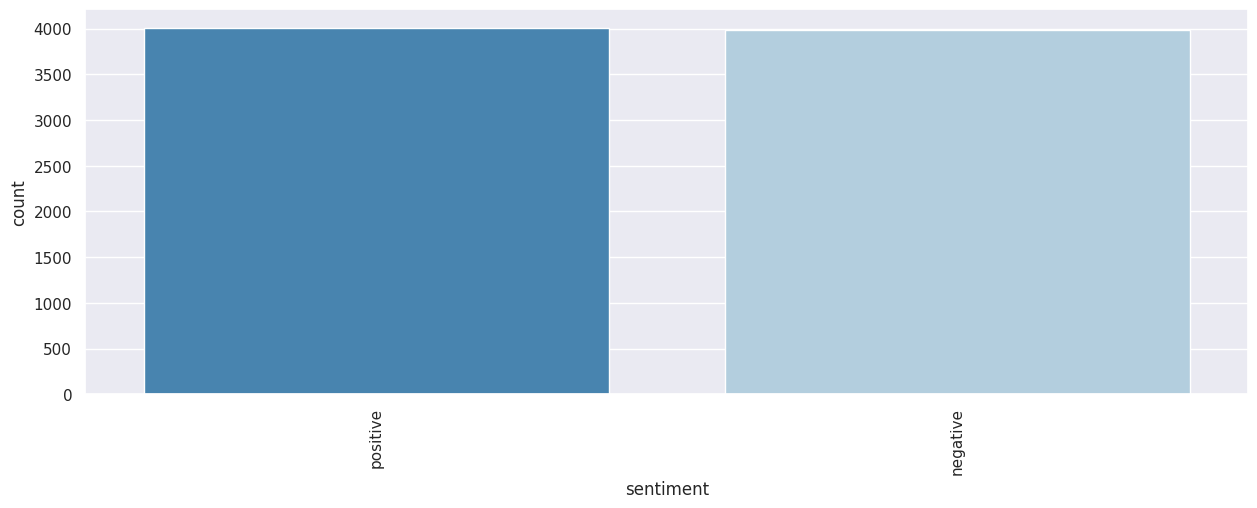

In [5]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.sentiment, order=[x for x, count in sorted(Counter(training_set.sentiment).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Método para eliminar los "artefactos" xml que tienen las reseñas.
Es el mismo que se usó en la práctica 1.

In [6]:
from bs4 import BeautifulSoup
import re

def strip_html_remove_links(text):
    soup = BeautifulSoup(text, "html.parser")
    for a in soup.find_all("a"):
        a.decompose()

    text = soup.get_text(separator=" ")

    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

Método para procesar el texto.
Se recibe un raw string y se:
- Elimina artefactos xml
- Se convierte a minúscula
- Se eliminan carácteres especiales
- Se eliminan "stop words" en inglés
- Se aplica lematización: Convertir palabras a su raíz. (e.g. cars a car, leaves a leaf). No hay truncamiento como en stemming.

In [7]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

import re
import contractions

nltk.download('stopwords')
nltk.download('wordnet')

negation_words = {"not", "no", "never", "nor"}

def process_text(raw_text, keep_numbers=True):

    text = contractions.fix(raw_text)

    text = strip_html_remove_links(text)

    text = text.lower()

    pattern = r"[^a-z0-9 ]" if keep_numbers else r"[^a-z ]"
    text = re.sub(pattern, " ", text)

    words = text.split()

    stop_words = set(stopwords.words("english")) - negation_words
    words = [w for w in words if w not in stop_words]

    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/jesus.ferrandiz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/jesus.ferrandiz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['id', 'review', 'sentiment'], dtype='object')

Creamos una nueva columna con las reviews procesadas.

In [9]:
from tqdm import tqdm
tqdm.pandas()

dataset['processed_review'] = dataset['review'].progress_apply(lambda x: process_text(x))

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:06<00:00, 1542.47it/s]


In [10]:
dataset.head()

,id,review,sentiment,processed_review
0,17527,People tried to make me believe that the premi...,negative,people tried make believe premise rubbishy sup...
1,24155,I have been wanting to see cut since the day i...,positive,wanting see cut since day heard sometime last ...
2,21972,This movie is terrible. The suspense is spent ...,negative,movie terrible suspense spent waiting point no...
3,4565,I hope she can keep acting and directing. She'...,positive,hope keep acting directing surely task could e...
4,22098,I fell in love with this silent action drama. ...,positive,fell love silent action drama kurt russell kur...


In [11]:
X_train = dataset[0:len(training_set)][["id", "processed_review"]]
y_train = dataset[0:len(training_set)][["sentiment"]]

X_test = dataset[len(training_set):len(dataset)][["id", "processed_review"]]
y_test = dataset[len(training_set):len(dataset)][["sentiment"]]

Convertimos las etiquetas 'positive', 'negative' a 0 y 1.
Donde negative = 0, positive = 1

In [12]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.sentiment.values}")
le.fit(y_train.sentiment.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.sentiment.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

encoded_y_test = le.transform(y_test.sentiment.values)


Values before encoding: ['negative' 'positive' 'negative' ... 'negative' 'negative' 'negative']
Labels after encoding: [0 1 0 ... 0 0 0]
Target labels: ['negative' 'positive']


# Entrenamiento de Redes Neuronales

## Utilidades

He decidido desarrollar esta tarea con Pytorch para tener más familiaridad con este framework.
En las siguientes celdas, defino funciones que utilizaré posteriormente para preparar los datos,
entrenar los modelos y evaluarlos.

Al menos en el campo en el que trabajo (robótica) encuentro en la literatura más implementaciones hechas en Pytorch sobre
modelos de percepción o de aprendizaje por refuerzo.

In [13]:
# Importamos capas densas, capas de embeddings y capas para el aplanaEl hecho de que de una manera se pueda explicar el resultado del modelo ayuda do de dimensiones
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Estructura que guarda las métricas de entrenamiento y validación:
- Train loss
- Train accuracy
- Validation loss
- Validation accuracy

Y función para crear las gráficas.

In [14]:
# Con esta función podremos ver cómo evoluciona el entrenamiento y la validación de los modelos.

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Clase similar a la estructura que se obtiene al entrenar los modelos en tf.keras
class History:
    def __init__(self):
        self.history = {
            'loss': [],
            'acc': [],
            'val_loss': [],
            'val_acc': []
        }

def plot_history(history, metric='acc'):
    acc = history.history[metric]
    val_acc = history.history[f'val_{metric}']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

Función para crear un gráfico con la matriz de confusión.

In [15]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    import itertools
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

Función para mostrar información de un modelo de pytorch:
- Arquitectura
- Número de parámetros
- Tamaño del modelo

In [16]:
def print_model_info(model):
    print("=" * 80)
    print("MODEL ARCHITECTURE")
    print("=" * 80)
    print(model)
    print()
    
    print("=" * 80)
    print("MODEL PARAMETERS")
    print("=" * 80)
    
    total_params = 0
    trainable_params = 0
    
    print(f"{'Layer':<40} {'Parameters':<15} {'Shape':<20}")
    print("-" * 80)
    
    for name, param in model.named_parameters():
        num_params = param.numel()
        total_params += num_params
        if param.requires_grad:
            trainable_params += num_params
        
        print(f"{name:<40} {num_params:<15,} {str(list(param.shape)):<20}")
    
    print("-" * 80)
    print(f"{'Total Parameters:':<40} {total_params:,}")
    print(f"{'Trainable Parameters:':<40} {trainable_params:,}")
    print(f"{'Non-trainable Parameters:':<40} {(total_params - trainable_params):,}")
    
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / 1024**2
    
    print(f"{'Model Size:':<40} {size_mb:.2f} MB")
    print("=" * 80)

Método para entrenar un modelo de pytorch. Los argumentos incluyen:
- Modelo de torch a entrenar
- X_train: Datos de entrenamiento
- y_train: Etiquetas de entrenamiento
- Número de epochs
- Tamaño del batch
- Porcentage de datos de X_train que se usan para validar (y el resto para entrenar)
- Optimizador
- Criterio de loss
- Dispositivo
- Patience: Implementa early stopping. Número de validaciones máximo en la que si
la loss de validación no mejora con respecto a la mejor hasta ahora, se para el entrenamiento.

Se devuelve el histórico con las métricas de entrenamiento y de validación para que se puedan mostrar.

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

def train_pytorch_model(
    model,
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    optimizer=None,
    criterion=None,
    device=None,
    patience=5,
    scheduler=None
):    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    # Se mueve el modelo al device (CPU o GPU)
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    is_text_data = isinstance(X_train, torch.Tensor) and X_train.dtype == torch.long

    if hasattr(X_train, 'toarray'):
        X_train = X_train.toarray()

    if not isinstance(X_train, torch.Tensor):
        if is_text_data or X_train.dtype in [np.int32, np.int64]:
            X_train = torch.LongTensor(np.array(X_train))
        else:
            X_train = torch.FloatTensor(np.array(X_train).astype('float32'))

    if isinstance(criterion, nn.BCELoss):
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.FloatTensor(np.array(y_train).astype('float32'))
    elif isinstance(criterion, nn.CrossEntropyLoss):
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.LongTensor(np.array(y_train))
    else:
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.FloatTensor(np.array(y_train).astype('float32'))

    # Train/validation split
    if validation_split > 0:
        X_numpy = X_train.numpy() if isinstance(X_train, torch.Tensor) else X_train
        y_numpy = y_train.numpy() if isinstance(y_train, torch.Tensor) else y_train
        
        X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
            X_numpy, y_numpy, test_size=validation_split, random_state=42
        )

        if X_train.dtype == torch.long:
            X_train_split = torch.LongTensor(X_train_split)
            X_val_split = torch.LongTensor(X_val_split)
        else:
            X_train_split = torch.FloatTensor(X_train_split)
            X_val_split = torch.FloatTensor(X_val_split)

        if y_train.dtype == torch.long:
            y_train_split = torch.LongTensor(y_train_split)
            y_val_split = torch.LongTensor(y_val_split)
        else:
            y_train_split = torch.FloatTensor(y_train_split)
            y_val_split = torch.FloatTensor(y_val_split)
    else:
        X_train_split, y_train_split = X_train, y_train
        X_val_split, y_val_split = None, None

    if isinstance(criterion, nn.BCELoss) and y_train_split.dim() == 1:
        y_train_split = y_train_split.unsqueeze(1)
        if validation_split > 0:
            y_val_split = y_val_split.unsqueeze(1)

    # Los datasets son directamente TensorDataset de Pytorch
    train_dataset = TensorDataset(X_train_split, y_train_split)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    if validation_split > 0:
        val_dataset = TensorDataset(X_val_split, y_val_split)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Inicializar el histórico
    history = History()

    # Rutina de entrenamiento
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            if isinstance(criterion, nn.CrossEntropyLoss):
                predicted = torch.argmax(outputs, dim=1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()
            else:
                # Para calcular la accuracy en un problema de clasificación binaria con una sola neurona,
                # como la salida de una neurona (después de la activación) se espera que sea entre [0,1]
                # ponemos un threshold de 0.5 para diferenciar si es una clase u otra (review positiva o negativa)
                predicted = (outputs > 0.5).float()
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()

        # Métricas de entrenamiento: Train loss, train accuracy
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total
        history.history['loss'].append(epoch_train_loss)
        history.history['acc'].append(epoch_train_acc)

        if validation_split > 0:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            # Modelo en modo inferencia sin guardar los gradientes
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()

                    if isinstance(criterion, nn.CrossEntropyLoss):
                        predicted = torch.argmax(outputs, dim=1)
                    else:
                        # Threshold de 0.5 para cuando se usa una neurona solo
                        # Para el cálculo de cuáles son correctas para accuracy
                        predicted = (outputs > 0.5).float()

                    val_total += batch_y.size(0)
                    val_correct += (predicted == batch_y).sum().item()

            epoch_val_loss = val_loss / len(val_loader)
            epoch_val_acc = val_correct / val_total
            history.history['val_loss'].append(epoch_val_loss)
            history.history['val_acc'].append(epoch_val_acc)

            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(epoch_val_loss)
                else:
                    scheduler.step()
                print(f"Stepping learning rate to value: {scheduler.get_lr()}")

            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                patience_counter = 0
                # Guardar mejor modelo
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
                print(f" (patience: {patience_counter}/{patience})")

            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                # Restaurar mejor modelo
                model.load_state_dict(best_model_state)
                break
        else:
            history.history['val_loss'].append(0.0)
            history.history['val_acc'].append(0.0)

        if validation_split > 0:
            print(f'Epoch {epoch+1}/{epochs} - '
                  f'loss: {epoch_train_loss:.4f} - '
                  f'acc: {epoch_train_acc:.4f} - '
                  f'val_loss: {epoch_val_loss:.4f} - '
                  f'val_acc: {epoch_val_acc:.4f}')
        else:
            print(f'Epoch {epoch+1}/{epochs} - '
                  f'loss: {epoch_train_loss:.4f} - '
                  f'acc: {epoch_train_acc:.4f}')

    return history

Método para evaluar un modelo de torch en los datos de test.
Argumentos:
- model: Modelo de torch a testear.
- X_test: Datos (features) de test.
- y_test: Etiquetas de test
- le: Label Encoding
- target labels
- device

Al evaluar modelos basados en CNN, he tenido problemas de memoria al pasar todos los datos de test en un mismo batch
como se hacía en la práctica anterior. He cambiado la función de evaluación para pasar un mini-batch.
Los resultados de evaluación deberían ser los mismos.

In [18]:
def evaluate_pytorch_model(model, X_test, y_test, le=None, target_labels=None, device=None, batch_size=32):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval()

    if hasattr(X_test, 'toarray'):
        X_test_array = X_test.toarray().astype('float32')
        X_test_tensor = torch.FloatTensor(X_test_array)
    elif isinstance(X_test, torch.Tensor):
        X_test_tensor = X_test.cpu()
    else:
        X_test_array = np.array(X_test)
        if X_test_array.dtype in [np.int32, np.int64]:
            X_test_tensor = torch.LongTensor(X_test_array)
        else:
            X_test_tensor = torch.FloatTensor(X_test_array.astype('float32'))

    if isinstance(y_test, torch.Tensor):
        y_test = y_test.cpu().numpy()
    else:
        y_test = np.array(y_test)

    from torch.utils.data import TensorDataset, DataLoader

    dataset = TensorDataset(X_test_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_predictions = []

    with torch.no_grad():
        # En algunos entrenamientos con CNN, pasar como en la prácica anterior un batch del tamaño del test set
        # hacia que la GPU se quedara sin memoria, por eso paso un mini batch. Los resultados de 
        # evaluación deberían ser los mismos.
        for batch in dataloader:
            batch_X = batch[0].to(device)
            outputs = model(batch_X).cpu()
            
            if outputs.shape[1] == 1:
                # Si la salida es tamaño 1, como mencionado anteriormente, se usa un threshold
                # en 0.5 para diferenciar entre una clase u otra
                batch_pred = (outputs.numpy() > 0.5).astype(int).flatten()
            else:
                # Si la salida es de tamaño > 1, entonces la clase escogida
                # es aquella que tenga la probabilidad más alta (por eso argmax)
                batch_pred = torch.argmax(outputs, dim=1).numpy()
            
            all_predictions.append(batch_pred)
    
    y_pred = np.concatenate(all_predictions)
    
    if le is not None:
        y_pred_labels = le.inverse_transform(y_pred)
        if y_test.dtype in [np.int32, np.int64]:
            y_test_labels = le.inverse_transform(y_test)
        else:
            y_test_labels = y_test
    else:
        y_pred_labels = y_pred
        y_test_labels = y_test
    
    if target_labels is None:
        unique_labels = np.unique(np.concatenate([y_test_labels, y_pred_labels]))
        target_labels = sorted(unique_labels)
    
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT - {type(model).__name__}")
    print('='*60)
    print(classification_report(y_test_labels, y_pred_labels, target_names=target_labels))
    
    cm = confusion_matrix(y_test_labels, y_pred_labels, labels=target_labels)
    plot_confusion_matrix(cm, classes=target_labels)
    
    print("\nFINAL ACCURACY")
    accuracy = accuracy_score(y_test_labels, y_pred_labels)
    print(f"{accuracy:.4f} ({accuracy*100:.2f}%)")
    print('='*60)
    
    return y_pred_labels

Definimos unos parámetros iniciales

In [19]:
#Número de épocas (iteraciones globales)
epochs = 40
#Dimensión de la capa de embeddings
emb_dim = 50
#Tamaño de batch (lote)
batch_size = 32
#Número de palabras tenidas en cuenta (reducción del vocabulario)
n_most_common_words = 50000
#Máxima longitud del documento
max_len = 512

## Entrenamiento de modelos con datos en representación tf-idf

Igual que en la práctica 1, vamos a comenzar con features basadas en pesado TF-IDF.
Para ello, a partir del texto procesado, se convierte este a una
representación vectorial con pesado TF-IDF. En datos de entrenamiento,
esto es una matriz (8000: Número de muestras x 41847: Tamaño del vocabulario)

In [20]:
X_train["all"] = X_train[['processed_review']].apply(lambda x: ''.join(x), axis=1)
X_test["all"] = X_test[['processed_review']].apply(lambda x: ''.join(x), axis=1)

print(X_train['all'][0])

count_vect = CountVectorizer(analyzer = "word")
train_features = count_vect.fit_transform(X_train['all'])
test_features = count_vect.transform(X_test['all'])

# Se utiliza L2 (norma euclídea) para normalizar los vectores resultantes
tfidf = TfidfTransformer(norm="l2")
train_text_tfidf_features = tfidf.fit_transform(train_features)
print(train_text_tfidf_features.shape)

test_text_tfidf_features = tfidf.transform(test_features)
print(test_text_tfidf_features.shape)

people tried make believe premise rubbishy supernatural horror thriller inspired actual last word spoken authentic serial killer whose name escape moment whilst awaiting execution electric chair claimed soul would return life continue go never ending murder spree not highly original idea revolve horror film way low budget turkey implemented exact basic premise like house 3 shocker ghost machine anyway first power k pentagram not completely terrible effort script overly reverts clich lack genuine thrill film start okay albeit mundane serial killer flick obsessive cop hero lou diamond philip pursues maniac carves bloody pentagram chest victim receives unexpected help spiritual medium played gorgeous underrated tracy griffith lead killer also begs not execute would result even bigger catastrophe thanks tess helpful hint detective logan quickly capture killer celebrates death penalty patrick channing made pact satan return rotten street california killing first power get pretty bad murdere

In [21]:
Y_train = encoded_y_train  # Shape: (n_samples,)
Y_test = le.transform(y_test.values)

print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print(Y_train[0:10])

Y_train shape: (8000,)
Y_test shape: (2000,)
[0 1 0 1 1 0 1 1 1 0]


Quiero mencionar que en todos los modelos que he hecho en esta práctica, la salida tiene la siguiente forma:
- 1 sola neurona de salida
- Activación Sigmoid [0,1]
- Uso de BCE Loss
- Para el cálculo de accuracy, hay un threshold en 0.5 para diferenciar entre clases predichas dada la probabilidad.

En la práctica anterior, experimenté combinaciones de:
- 2 neuronas de salida, activación Softmax, CrossEntropyLoss
- 1 neurona de salida, activación sigmoide, BCELoss

En la siguiente práctica volveré a valorar si usar CELoss.

Defino primero un modelo basado en MLP muy parecido al de la práctica 1.

Como he cambiado la implementación a torch. Quiero comenzar con un modelo "base" y ver que obtenga
resultados similares a la práctica anterior.

In [22]:
class BinaryClassifierMLP(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifierMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        # Single output neuron
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.softmax(x, dim=1)

        x = self.fc2(x)
        x = F.softmax(x, dim=1)
        
        x = self.fc3(x)
        x = F.sigmoid(x)

        return x

### Entrenamiento ID=1 Binary classifier MLP base
Modelo base MLP de la práctica anterior.
Con 2 capas ocultas (128, 64) y una capa de salida de 2 neuronas. Softmax de salida para 
normalizar como probabilidades los logits de las 2 neuronas de salida.
Aunque no sea muy común, softmax como activación en las capas ocultas (para que sea igual al
modelo de la práctica anterior).

Los datos tienen las siguientes características:
- Las características de entrenamineto son de tamaño (8000: número de ejemplos, 41847: tamaño del vocabulario). Las características son representaciones con pesado TF-IDF.
- Las etiquetas tienen tamaño (8000,) y valen 0, ó 1.
- Se usa la clase **TensorDataset** para convertir las matrices X_train, Y_train a un dataset compatible con torch.

El objetivo de este entrenamiento es solamente validar que con la implementación de torch y un modelo base al de la práctica 1 se obtiene un resultado en evaluación muy similar después de entrenar.
Este modelo tiene **~5M parámetros**.

In [23]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierMLP(input_dim)
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierMLP(
  (fc1): Linear(in_features=41847, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               5,356,416       [128, 41847]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        5,364,8

Epoch 1/40 - loss: 0.6936 - acc: 0.5009 - val_loss: 0.6931 - val_acc: 0.5038
Epoch 2/40 - loss: 0.6931 - acc: 0.5009 - val_loss: 0.6928 - val_acc: 0.5038
Epoch 3/40 - loss: 0.6916 - acc: 0.5689 - val_loss: 0.6893 - val_acc: 0.8450
Epoch 4/40 - loss: 0.6748 - acc: 0.8175 - val_loss: 0.6579 - val_acc: 0.8562
Epoch 5/40 - loss: 0.6046 - acc: 0.9092 - val_loss: 0.5807 - val_acc: 0.8681
Epoch 6/40 - loss: 0.4977 - acc: 0.9384 - val_loss: 0.4992 - val_acc: 0.8738
Epoch 7/40 - loss: 0.3975 - acc: 0.9567 - val_loss: 0.4348 - val_acc: 0.8769
Epoch 8/40 - loss: 0.3143 - acc: 0.9689 - val_loss: 0.3853 - val_acc: 0.8794
Epoch 9/40 - loss: 0.2463 - acc: 0.9786 - val_loss: 0.3484 - val_acc: 0.8806
Epoch 10/40 - loss: 0.1909 - acc: 0.9848 - val_loss: 0.3221 - val_acc: 0.8819
Epoch 11/40 - loss: 0.1471 - acc: 0.9900 - val_loss: 0.3051 - val_acc: 0.8831
Epoch 12/40 - loss: 0.1137 - acc: 0.9920 - val_loss: 0.2964 - val_acc: 0.8844
Epoch 13/40 - loss: 0.0888 - acc: 0.9941 - val_loss: 0.2938 - val_acc: 0.

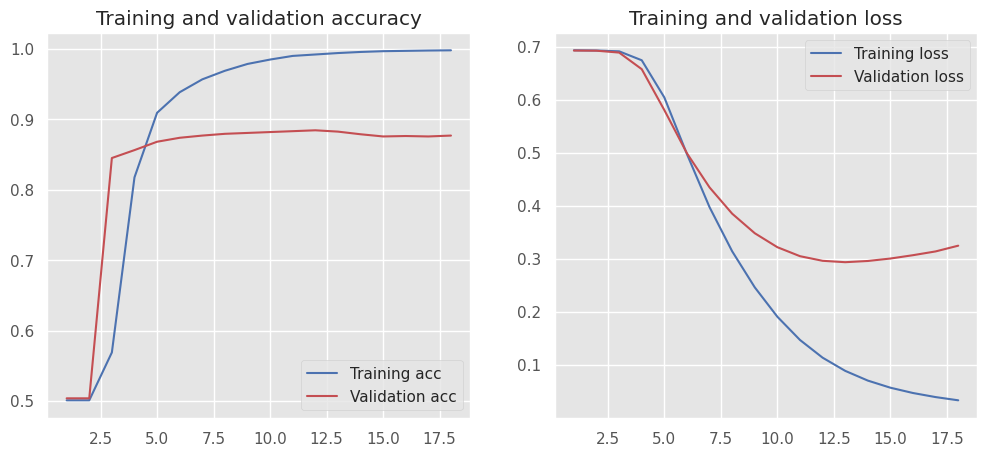

In [24]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierMLP
              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      1025
    positive       0.85      0.88      0.87       975

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion matrix, without normalization


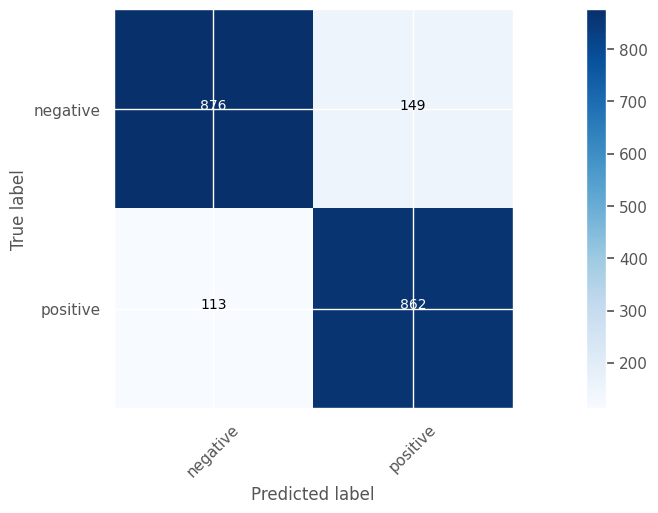


FINAL ACCURACY
0.8690 (86.90%)


In [25]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

La accuracy obtenida es muy similar al de la práctica 1 para este modelo denso con softmax (0.875).
Las curvas de pérdidas de entrenamiento, validación y de exactitud también son muy parecidas.

## Modelo con capas CNN y representación TF-IDF

Comenzamos con el primer modelo que tiene convoluciones.
Estas convoluciones van a trabajar directamente sobre la representación TF-IDF.
No espero obtener buenos resultados, porque la representación TF-IDF es sparese y pierde el orden de la secuencia de texto de entrada.

En este modelo uso pooling para colapsar el tensor de salida de la última convolución de forma:
[B, C=128, Embedded dim] -> [B, C=128]
Estas 128 features, son la entrada dos capas MLP que reduciran las features de 128 a 1 (neurona de salida).

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BinaryClassifierPureCNN(nn.Module):
    def __init__(self, pooling_type='max'):
        super(BinaryClassifierPureCNN, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self._pooling_type = pooling_type

        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x):

        # Input: [B, vocab_size=41847]

        x = x.unsqueeze(1)  # [B, C=1, vocab_size=41847]
        x = self.conv1(x)
        x = F.relu(x)

        # Conv layer 2
        x = self.conv2(x)  # [batch_size, C=128, embedding_dim]
        x = F.relu(x)

        # Global max pooling
        if self._pooling_type == "max":
            x = F.max_pool1d(x, kernel_size=x.size(2))  # [batch_size, 128, 1]
        elif self._pooling_type == "avg":
            x = F.avg_pool1d(x, kernel_size=x.size(2))
        elif self._pooling_type == "ad_avg":
            x = F.adaptive_avg_pool1d(x, output_size=1)  # [batch_size, 128, 1]
        else:
            raise RuntimeError(f"Wrong pooling type: {self._pooling_type}")

        x = x.squeeze(2)  # [batch_size, 128]

        # Fully connected layers
        x = self.fc1(x)  # [batch_size, 32]
        x = F.relu(x)

        x = self.fc2(x)  # [batch_size, 1]
        x = torch.sigmoid(x)

        return x  # [batch_size, 1]

### Entrenamiento ID=2 TF-IDF - CNN - MLP


In [27]:
model = BinaryClassifierPureCNN()
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierPureCNN(
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
conv1.weight                             192             [64, 1, 3]          
conv1.bias                               64              [64]                
conv2.weight                             24,576          [128, 64, 3]        
conv2.bias                               128             [128]               
fc1.weight                               4,096           [32, 128]           
fc1.bias                                 32              [32]                
fc2.weight                               32    

El siguiente modelo **BinaryClassifierCNN** se basa en una capa MLP para reducir los datos del tamaño
del vocabulario (muy grande) en 128 features. Después, hay 2 capas convolucionales de 1 dimensión.
Después de las convoluciones, los feature maps de tamaño [batch size, 128, 128] se colapsan a través de pooling a features de tamaño [batch size, 128]. Hay unas últimas capas MLP que convierten estos features de 128 a una única neurona que después de una 
activación sigmoide se convierte en una probabilidad entre [0,1].

Epoch 1/40 - loss: 0.6936 - acc: 0.5014 - val_loss: 0.6929 - val_acc: 0.4975
Epoch 2/40 - loss: 0.6933 - acc: 0.4989 - val_loss: 0.6923 - val_acc: 0.5500
Epoch 3/40 - loss: 0.6929 - acc: 0.5164 - val_loss: 0.6916 - val_acc: 0.5387
 (patience: 1/5)
Epoch 4/40 - loss: 0.6926 - acc: 0.5203 - val_loss: 0.6919 - val_acc: 0.5056
Epoch 5/40 - loss: 0.6922 - acc: 0.5197 - val_loss: 0.6905 - val_acc: 0.5475
 (patience: 1/5)
Epoch 6/40 - loss: 0.6924 - acc: 0.5159 - val_loss: 0.6907 - val_acc: 0.5381
Epoch 7/40 - loss: 0.6923 - acc: 0.5202 - val_loss: 0.6904 - val_acc: 0.5244
Epoch 8/40 - loss: 0.6922 - acc: 0.5227 - val_loss: 0.6896 - val_acc: 0.5375
Epoch 9/40 - loss: 0.6919 - acc: 0.5238 - val_loss: 0.6893 - val_acc: 0.5463
 (patience: 1/5)
Epoch 10/40 - loss: 0.6920 - acc: 0.5242 - val_loss: 0.6897 - val_acc: 0.5250
 (patience: 2/5)
Epoch 11/40 - loss: 0.6920 - acc: 0.5219 - val_loss: 0.6894 - val_acc: 0.5387
 (patience: 3/5)
Epoch 12/40 - loss: 0.6919 - acc: 0.5222 - val_loss: 0.6904 - val_

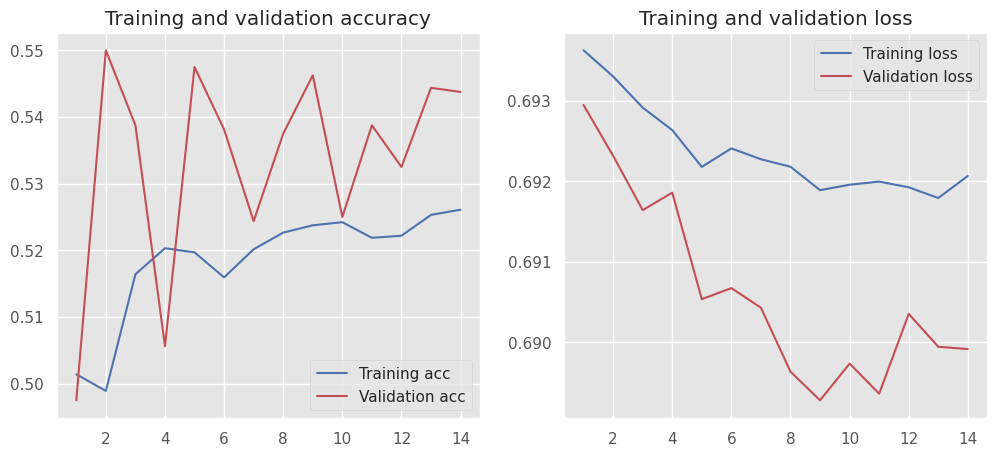

In [28]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)

Este modelo no consigue aprender. La accuracy tanto en entrenamiento como en validación está cerca del 50% que es algo practicamente aleatorio.

Hemos aplicado una convolución directamente a una representación del texto TF-IDF. Pienso que esta representación no es adecuada como entrada a una convolución
porque se pierde la información del orden de las palabras. Pero las CNN's modelan features **locales** donde sí importa el orden.

Con la idea de que es posible que la convolución mejore al tener una entrada más densa, vamos a poner un MLP entre los datos de entrada en TF-IDF y la primera convolución.
No es ideal, en siguientes apartados, utilizaremos directamente una representación de la secuencia más acecuada para la CNN.

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BinaryClassifierCNN(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, pooling_type='max'):
        super(BinaryClassifierCNN, self).__init__()

        self.embedding_dim = embedding_dim

        self.embed = nn.Linear(input_dim, embedding_dim)

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self._pooling_type = pooling_type

        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x):
        # x es un tensor de forma [Batch size, tamaño del vocabulario]

        x = self.embed(x)  # [batch_size, embedding_dim]
        x = F.relu(x)

        x = x.unsqueeze(1)  # [batch_size, C=1, embedding_dim]

        # Conv layer 1 (aumenta el tamaño de los canales de 1 a 64)
        # El padding de 1 mantiene el mismo tamaño "espacial" embedding_dim
        x = self.conv1(x)  # [batch_size, C=64, embedding_dim]
        x = F.relu(x)

        # Conv layer 2
        x = self.conv2(x)  # [batch_size, C=128, embedding_dim]
        x = F.relu(x)

        # Global max pooling
        if self._pooling_type == "max":
            x = F.max_pool1d(x, kernel_size=x.size(2))  # [batch_size, 128, 1]
        elif self._pooling_type == "avg":
            x = F.avg_pool1d(x, kernel_size=x.size(2))
        elif self._pooling_type == "ad_avg":
            x = F.adaptive_avg_pool1d(x, output_size=1)  # [batch_size, 128, 1]
        else:
            raise RuntimeError(f"Wrong pooling type: {self._pooling_type}")

        x = x.squeeze(2)  # [batch_size, 128]

        # Fully connected layers
        x = self.fc1(x)  # [batch_size, 32]
        x = F.relu(x)

        x = self.fc2(x)  # [batch_size, 1]
        x = torch.sigmoid(x)

        return x  # [batch_size, 1]

### Entrenamiento ID=3 TF-IDF - MLP - CNN - MLP
- Pooling type: Max

Se usa max pooling para colapsar en un solo valor (el máximo) la dimensión embedding después de la 2 convolución.

In [30]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierCNN(input_dim, pooling_type="max")
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierCNN(
  (embed): Linear(in_features=41847, out_features=128, bias=True)
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embed.weight                             5,356,416       [128, 41847]        
embed.bias                               128             [128]               
conv1.weight                             192             [64, 1, 3]          
conv1.bias                               64              [64]                
conv2.weight                             24,576          [128, 64, 3]        
conv2.bias                               128             [128] 

En este modelo se tienen convoluciones con un kernel de 1 dimensión. El kernel tiene tamaño 3.
Esto significa que cada filtro de la convolución tiene 3 parámetros. Por eso el número de pesos de conv1.weight es: 64 filtros x 3 kernel size = 192
Después se le añade el bias que son conv1.bias = 64 filtros x 1 = 64

Epoch 1/40 - loss: 0.5362 - acc: 0.7220 - val_loss: 0.2914 - val_acc: 0.8738
 (patience: 1/5)
Epoch 2/40 - loss: 0.1155 - acc: 0.9592 - val_loss: 0.3070 - val_acc: 0.8706
 (patience: 2/5)
Epoch 3/40 - loss: 0.0198 - acc: 0.9956 - val_loss: 0.4123 - val_acc: 0.8631
 (patience: 3/5)
Epoch 4/40 - loss: 0.0040 - acc: 0.9994 - val_loss: 0.4335 - val_acc: 0.8675
 (patience: 4/5)
Epoch 5/40 - loss: 0.0015 - acc: 0.9998 - val_loss: 0.4711 - val_acc: 0.8694
 (patience: 5/5)
Early stopping triggered at epoch 6


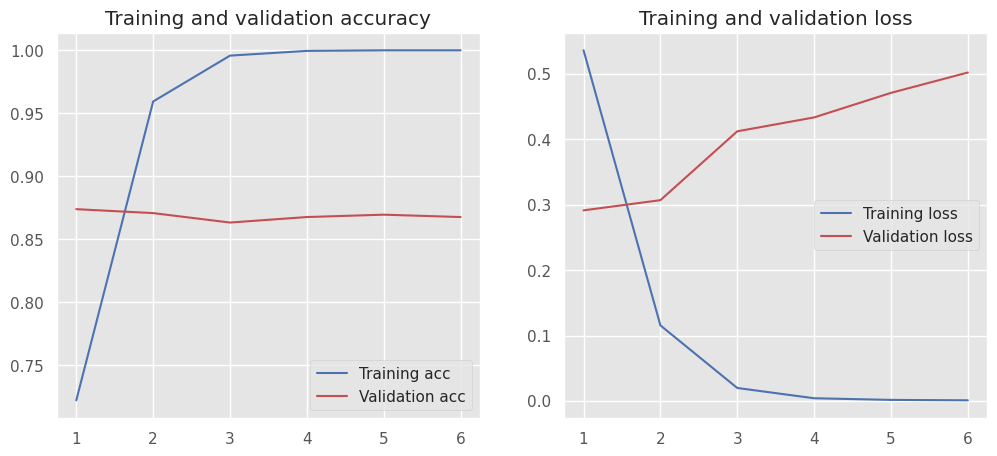

In [31]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierCNN
              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      1025
    positive       0.85      0.89      0.87       975

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion matrix, without normalization


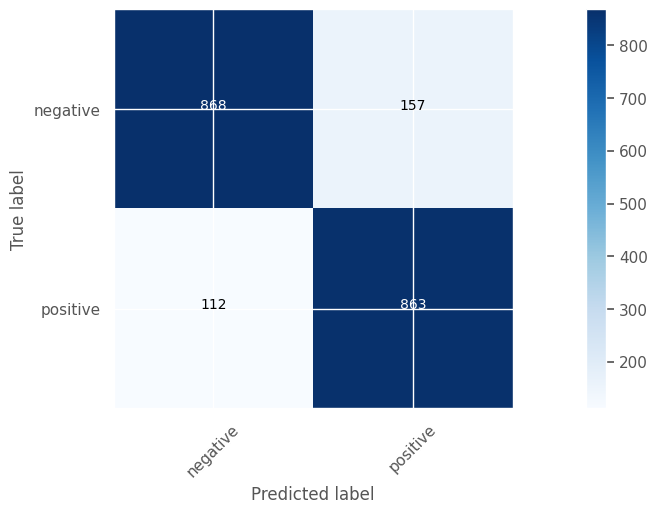


FINAL ACCURACY
0.8655 (86.55%)


In [32]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

Se obtiene una accuracy similar al modelo anterior basado en MLP. Ambos tienen un número similar de parámetros, sobre ~5M.
Es posible que la mayoría del trabajo lo haga el MLP de la entrada. En los siguientes apartados, exploraremos parámetros específicos de las convoluciones.

### Entrenamiento ID=4 TF-IDF - MLP - CNN - MLP

- Pooling type: avg

In [33]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierCNN(input_dim, pooling_type="avg")
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierCNN(
  (embed): Linear(in_features=41847, out_features=128, bias=True)
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embed.weight                             5,356,416       [128, 41847]        
embed.bias                               128             [128]               
conv1.weight                             192             [64, 1, 3]          
conv1.bias                               64              [64]                
conv2.weight                             24,576          [128, 64, 3]        
conv2.bias                               128             [128] 

Epoch 1/40 - loss: 0.5388 - acc: 0.6922 - val_loss: 0.2869 - val_acc: 0.8844
 (patience: 1/5)
Epoch 2/40 - loss: 0.1205 - acc: 0.9605 - val_loss: 0.3130 - val_acc: 0.8794
 (patience: 2/5)
Epoch 3/40 - loss: 0.0238 - acc: 0.9948 - val_loss: 0.3967 - val_acc: 0.8706
 (patience: 3/5)
Epoch 4/40 - loss: 0.0071 - acc: 0.9988 - val_loss: 0.4280 - val_acc: 0.8700
 (patience: 4/5)
Epoch 5/40 - loss: 0.0040 - acc: 0.9995 - val_loss: 0.4570 - val_acc: 0.8762
 (patience: 5/5)
Early stopping triggered at epoch 6


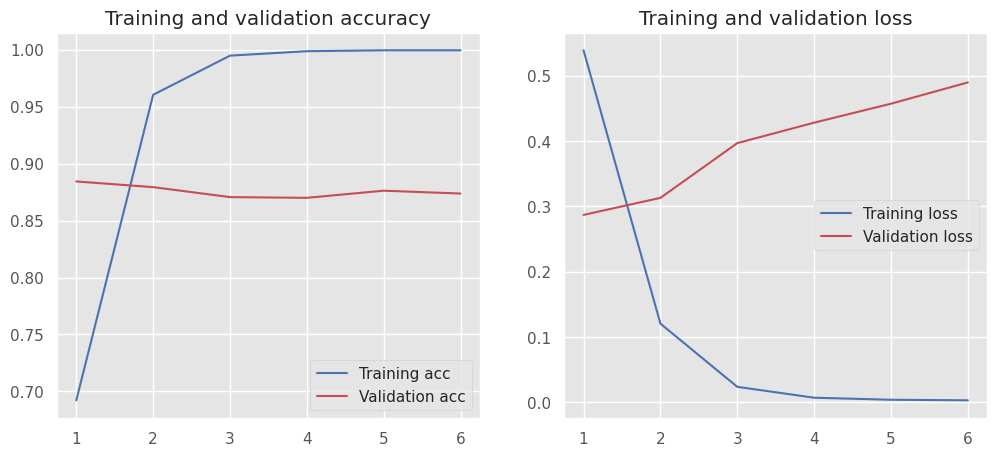

In [34]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierCNN
              precision    recall  f1-score   support

    negative       0.87      0.86      0.86      1025
    positive       0.85      0.86      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


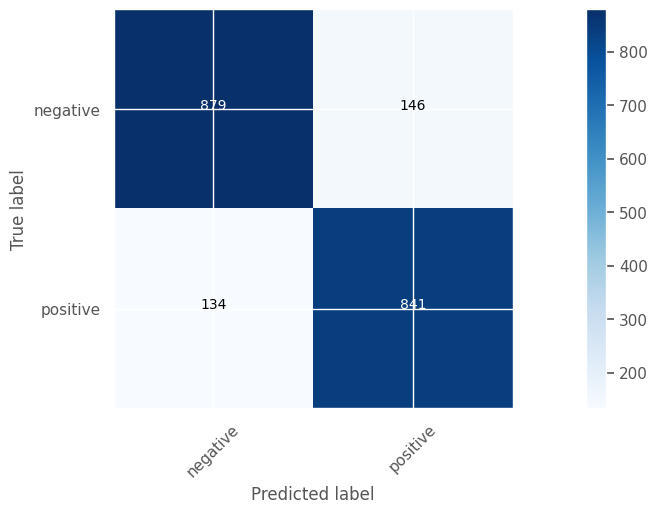


FINAL ACCURACY
0.8600 (86.00%)


In [35]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

La accuracy con avg pooling es similar a la anterior.

### Entrenamiento ID=5 TF-IDF - MLP - CNN - MLP

- Pooling type: ad_avg

In [36]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierCNN(input_dim, pooling_type="ad_avg")
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierCNN(
  (embed): Linear(in_features=41847, out_features=128, bias=True)
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embed.weight                             5,356,416       [128, 41847]        
embed.bias                               128             [128]               
conv1.weight                             192             [64, 1, 3]          
conv1.bias                               64              [64]                
conv2.weight                             24,576          [128, 64, 3]        
conv2.bias                               128             [128] 

Epoch 1/40 - loss: 0.5094 - acc: 0.7202 - val_loss: 0.2830 - val_acc: 0.8794
 (patience: 1/5)
Epoch 2/40 - loss: 0.1049 - acc: 0.9655 - val_loss: 0.3286 - val_acc: 0.8738
 (patience: 2/5)
Epoch 3/40 - loss: 0.0223 - acc: 0.9958 - val_loss: 0.4068 - val_acc: 0.8662
 (patience: 3/5)
Epoch 4/40 - loss: 0.0114 - acc: 0.9981 - val_loss: 0.4210 - val_acc: 0.8669
 (patience: 4/5)
Epoch 5/40 - loss: 0.0082 - acc: 0.9984 - val_loss: 0.4758 - val_acc: 0.8656
 (patience: 5/5)
Early stopping triggered at epoch 6


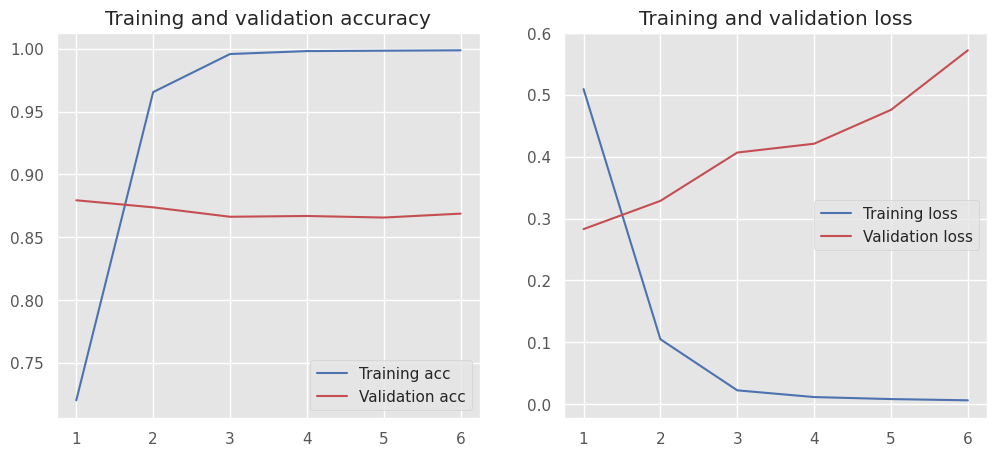

In [37]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierCNN
              precision    recall  f1-score   support

    negative       0.89      0.82      0.86      1025
    positive       0.83      0.90      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


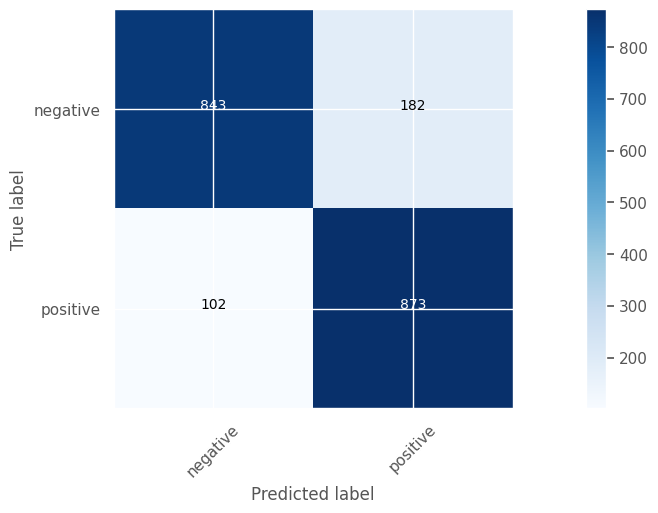


FINAL ACCURACY
0.8580 (85.80%)


In [38]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

La accuracy un poco peor que con max y avg pooling, pero está al mismo nivel.

Vamos a explorar ahora los parámetros de las capas convolucionales que son los siguientes:
- Número de filtros (F)
- Tamaño del kernel (K)
- Stride (S) (tamaño del salto del kernel)
- Padding (P) (cuánto se añade de padding)

### Entrenamiento ID=6 TF-IDF - MLP - CNN - MLP
- Pooling type: Max
- S=2
- K=3

Quiero explorar reducir el tamaño espacial de los feature maps de las convoluciones a partir de aumentar el stride de 1 a 2.
Un stride de 2 hace que los filtros se salten un elemento al hacer la convolución y entonces se reduce la dimensión espacial de la salida.

En las 2 capas convolucionales, este modelo va a mantener el tamaño del kernel a 3 y se añade un stride de 2 en vez de 1.
Por ejemplo:
Si la entrada es [B,C,embedded_dim]
con stride 2, la salida es aproximadamente [B,C+F, ~embedded_dim/2]

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BinaryClassifierCNNV1(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, pooling_type='max'):
        super(BinaryClassifierCNNV1, self).__init__()

        self.embedding_dim = embedding_dim

        self.embed = nn.Linear(input_dim, embedding_dim)

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1, stride=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1, stride=2)

        self._pooling_type = pooling_type

        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x):
        # x es un tensor de forma [Batch size, tamaño del vocabulario]

        x = self.embed(x)  # [batch_size, embedding_dim]
        x = F.relu(x)

        x = x.unsqueeze(1)  # [batch_size, C=1, embedding_dim]

        # Conv layer 1 (aumenta el tamaño de los canales de 1 a 64)
        # El padding de 1 mantiene el mismo tamaño "espacial" embedding_dim
        x = self.conv1(x)  # [batch_size, C=64, embedding_dim]
        x = F.relu(x)

        # Conv layer 2
        x = self.conv2(x)  # [batch_size, C=128, embedding_dim]
        x = F.relu(x)

        # Global max pooling
        if self._pooling_type == "max":
            x = F.max_pool1d(x, kernel_size=x.size(2))  # [batch_size, 128, 1]
        elif self._pooling_type == "avg":
            x = F.avg_pool1d(x, kernel_size=x.size(2))
        elif self._pooling_type == "ad_avg":
            x = F.adaptive_avg_pool1d(x, output_size=1)  # [batch_size, 128, 1]
        else:
            raise RuntimeError(f"Wrong pooling type: {self._pooling_type}")

        x = x.squeeze(2)  # [batch_size, 128]

        # Fully connected layers
        x = self.fc1(x)  # [batch_size, 32]
        x = F.relu(x)

        x = self.fc2(x)  # [batch_size, 1]
        x = torch.sigmoid(x)

        return x  # [batch_size, 1]

In [40]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierCNNV1(input_dim, pooling_type="max")
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierCNNV1(
  (embed): Linear(in_features=41847, out_features=128, bias=True)
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embed.weight                             5,356,416       [128, 41847]        
embed.bias                               128             [128]               
conv1.weight                             192             [64, 1, 3]          
conv1.bias                               64              [64]                
conv2.weight                             24,576          [128, 64, 3]        
conv2.bias                               128             [128

Epoch 1/40 - loss: 0.5991 - acc: 0.6511 - val_loss: 0.3358 - val_acc: 0.8531
Epoch 2/40 - loss: 0.1401 - acc: 0.9498 - val_loss: 0.3212 - val_acc: 0.8725
 (patience: 1/5)
Epoch 3/40 - loss: 0.0192 - acc: 0.9959 - val_loss: 0.3931 - val_acc: 0.8694
 (patience: 2/5)
Epoch 4/40 - loss: 0.0025 - acc: 0.9995 - val_loss: 0.4496 - val_acc: 0.8625
 (patience: 3/5)
Epoch 5/40 - loss: 0.0006 - acc: 1.0000 - val_loss: 0.4834 - val_acc: 0.8694
 (patience: 4/5)
Epoch 6/40 - loss: 0.0003 - acc: 1.0000 - val_loss: 0.5031 - val_acc: 0.8656
 (patience: 5/5)
Early stopping triggered at epoch 7


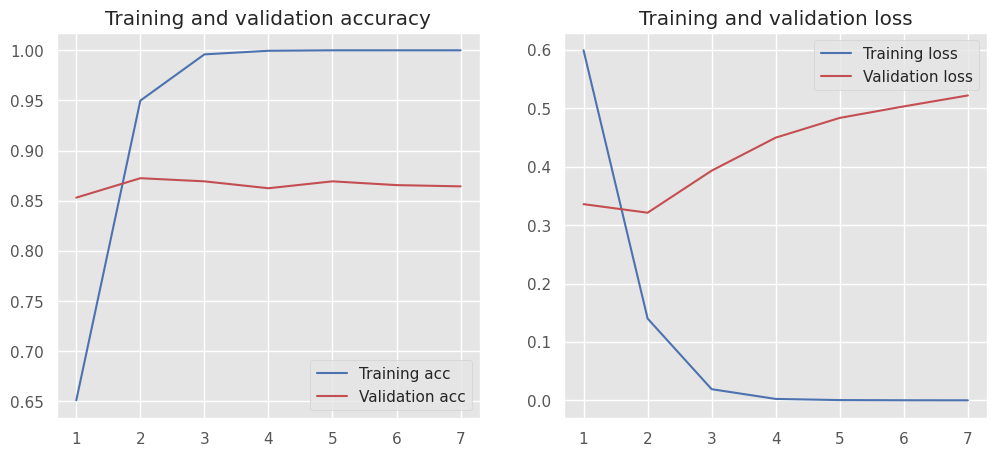

In [41]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierCNNV1
              precision    recall  f1-score   support

    negative       0.86      0.87      0.86      1025
    positive       0.86      0.85      0.85       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


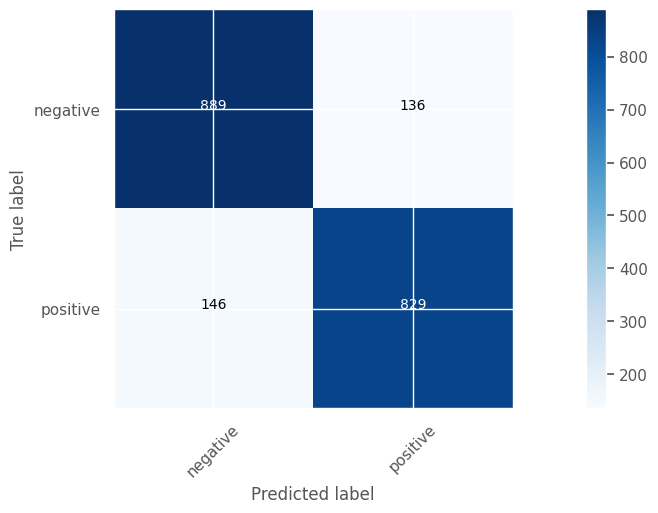


FINAL ACCURACY
0.8590 (85.90%)


In [42]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

Tenemos un resultado similar a lo anterior.

Epoch 1/40 - loss: 0.0001 - acc: 1.0000 - val_loss: 0.8635 - val_acc: 0.8575
 (patience: 1/5)
Epoch 2/40 - loss: 0.0000 - acc: 1.0000 - val_loss: 0.8985 - val_acc: 0.8575
 (patience: 2/5)
Epoch 3/40 - loss: 0.0000 - acc: 1.0000 - val_loss: 0.9951 - val_acc: 0.8588
 (patience: 3/5)
Epoch 4/40 - loss: 0.0000 - acc: 1.0000 - val_loss: 1.1666 - val_acc: 0.8600
 (patience: 4/5)
Epoch 5/40 - loss: 0.0000 - acc: 1.0000 - val_loss: 1.3957 - val_acc: 0.8588
 (patience: 5/5)
Early stopping triggered at epoch 6


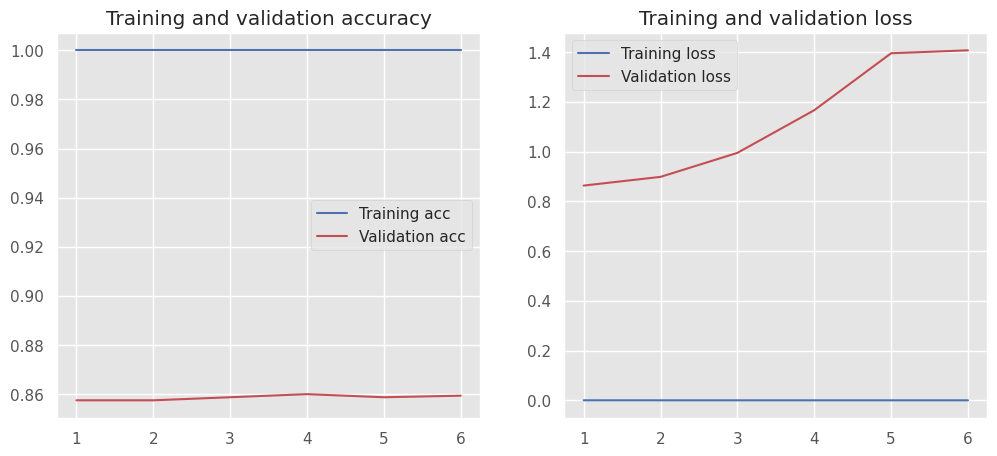

In [43]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)

### Entrenamiento ID=7 TF-IDF - MLP - CNN - MLP
Filtro con ventana más grande
- K=5
- S=2

In [44]:
class BinaryClassifierCNNV2(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, pooling_type='max'):
        super(BinaryClassifierCNNV2, self).__init__()

        self.embedding_dim = embedding_dim

        self.embed = nn.Linear(input_dim, embedding_dim)

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, padding=1, stride=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=1, stride=2)

        self._pooling_type = pooling_type

        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x):
        # x es un tensor de forma [Batch size, tamaño del vocabulario]

        x = self.embed(x)  # [batch_size, embedding_dim]
        x = F.relu(x)

        x = x.unsqueeze(1)  # [batch_size, C=1, embedding_dim]

        # Conv layer 1 (aumenta el tamaño de los canales de 1 a 64)
        # El padding de 1 mantiene el mismo tamaño "espacial" embedding_dim
        x = self.conv1(x)  # [batch_size, C=64, embedding_dim]
        x = F.relu(x)

        # Conv layer 2
        x = self.conv2(x)  # [batch_size, C=128, embedding_dim]
        x = F.relu(x)

        # Global max pooling
        if self._pooling_type == "max":
            x = F.max_pool1d(x, kernel_size=x.size(2))  # [batch_size, 128, 1]
        elif self._pooling_type == "avg":
            x = F.avg_pool1d(x, kernel_size=x.size(2))
        elif self._pooling_type == "ad_avg":
            x = F.adaptive_avg_pool1d(x, output_size=1)  # [batch_size, 128, 1]
        else:
            raise RuntimeError(f"Wrong pooling type: {self._pooling_type}")

        x = x.squeeze(2)  # [batch_size, 128]

        # Fully connected layers
        x = self.fc1(x)  # [batch_size, 32]
        x = F.relu(x)

        x = self.fc2(x)  # [batch_size, 1]
        x = torch.sigmoid(x)

        return x  # [batch_size, 1]

In [45]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierCNNV2(input_dim, pooling_type="max")
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierCNNV2(
  (embed): Linear(in_features=41847, out_features=128, bias=True)
  (conv1): Conv1d(1, 64, kernel_size=(5,), stride=(2,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(1,))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embed.weight                             5,356,416       [128, 41847]        
embed.bias                               128             [128]               
conv1.weight                             320             [64, 1, 5]          
conv1.bias                               64              [64]                
conv2.weight                             40,960          [128, 64, 5]        
conv2.bias                               128             [128

Epoch 1/40 - loss: 0.5211 - acc: 0.7111 - val_loss: 0.3471 - val_acc: 0.8538
Epoch 2/40 - loss: 0.0975 - acc: 0.9697 - val_loss: 0.3230 - val_acc: 0.8781
 (patience: 1/5)
Epoch 3/40 - loss: 0.0123 - acc: 0.9975 - val_loss: 0.4516 - val_acc: 0.8662
 (patience: 2/5)
Epoch 4/40 - loss: 0.0015 - acc: 0.9998 - val_loss: 0.4867 - val_acc: 0.8594
 (patience: 3/5)
Epoch 5/40 - loss: 0.0003 - acc: 1.0000 - val_loss: 0.5072 - val_acc: 0.8688
 (patience: 4/5)
Epoch 6/40 - loss: 0.0002 - acc: 1.0000 - val_loss: 0.5480 - val_acc: 0.8688
 (patience: 5/5)
Early stopping triggered at epoch 7


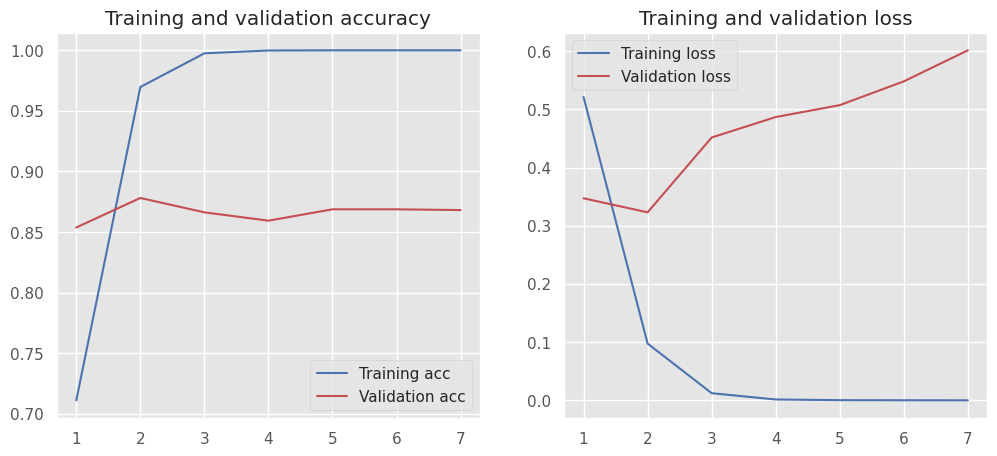

In [46]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierCNNV2
              precision    recall  f1-score   support

    negative       0.87      0.86      0.87      1025
    positive       0.86      0.87      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


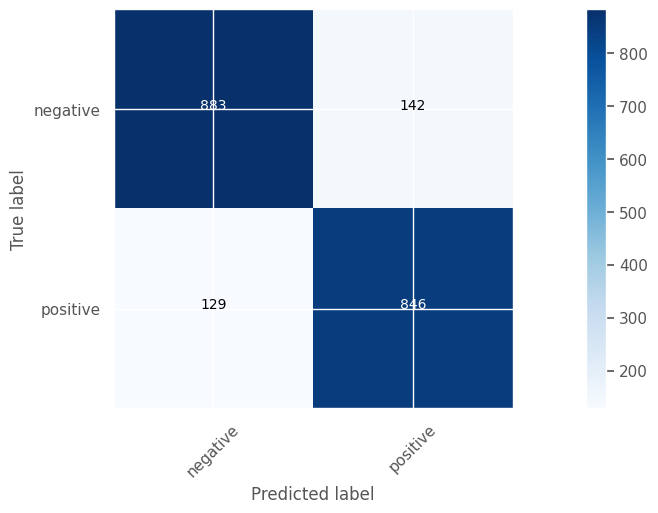


FINAL ACCURACY
0.8645 (86.45%)


In [47]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

Con la ventana de filtro más grande parece que se ha obtenido una accuracy ligeramente mejor.

### Entrenamiento ID=8 TF-IDF - MLP - CNN - MLP
- S=2
- K=7
- P=3 (Esto hace que con estos parámetros, la convolución divide la dimensión espacial entre 2)
Cambiamos el padding de 1 a 3.

In [48]:
class BinaryClassifierCNNV3(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, pooling_type='max'):
        super(BinaryClassifierCNNV3, self).__init__()

        self.embedding_dim = embedding_dim

        self.embed = nn.Linear(input_dim, embedding_dim)

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=7, padding=3, stride=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=7, padding=3, stride=2)

        self._pooling_type = pooling_type

        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x, verbose=False):
        # x es un tensor de forma [Batch size, tamaño del vocabulario]

        x = self.embed(x)  # [batch_size, embedding_dim]
        x = F.relu(x)

        x = x.unsqueeze(1)  # [batch_size, C=1, embedding_dim]

        if verbose:
            print(f"Tamaño de entrada a primera convolución: {x.shape}")

        # Conv layer 1 (aumenta el tamaño de los canales de 1 a 64)
        # El padding de 1 mantiene el mismo tamaño "espacial" embedding_dim
        x = self.conv1(x)  # [batch_size, C=64, embedding_dim / 2 = 64]
        if verbose:
            print(f"Tamaño del primer feature map: {x.shape}")
        x = F.relu(x)

        # Conv layer 2
        x = self.conv2(x)  # [batch_size, C=128, 64 / 2 = 32]
        if verbose:
            print(f"Tamaño del segundo feature map: {x.shape}")
        x = F.relu(x)

        # Global max pooling
        if self._pooling_type == "max":
            x = F.max_pool1d(x, kernel_size=x.size(2))  # [batch_size, 128, 1]
        elif self._pooling_type == "avg":
            x = F.avg_pool1d(x, kernel_size=x.size(2))
        elif self._pooling_type == "ad_avg":
            x = F.adaptive_avg_pool1d(x, output_size=1)  # [batch_size, 128, 1]
        else:
            raise RuntimeError(f"Wrong pooling type: {self._pooling_type}")

        x = x.squeeze(2)  # [batch_size, 128]

        # Fully connected layers
        x = self.fc1(x)  # [batch_size, 32]
        x = F.relu(x)

        x = self.fc2(x)  # [batch_size, 1]
        x = torch.sigmoid(x)

        return x  # [batch_size, 1]

In [49]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierCNNV3(input_dim, pooling_type="max")
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierCNNV3(
  (embed): Linear(in_features=41847, out_features=128, bias=True)
  (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (conv2): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embed.weight                             5,356,416       [128, 41847]        
embed.bias                               128             [128]               
conv1.weight                             448             [64, 1, 7]          
conv1.bias                               64              [64]                
conv2.weight                             57,344          [128, 64, 7]        
conv2.bias                               128             [128

Epoch 1/40 - loss: 0.5369 - acc: 0.7089 - val_loss: 0.2856 - val_acc: 0.8762
 (patience: 1/5)
Epoch 2/40 - loss: 0.1113 - acc: 0.9614 - val_loss: 0.3321 - val_acc: 0.8656
 (patience: 2/5)
Epoch 3/40 - loss: 0.0153 - acc: 0.9969 - val_loss: 0.4606 - val_acc: 0.8644
 (patience: 3/5)
Epoch 4/40 - loss: 0.0023 - acc: 0.9997 - val_loss: 0.4980 - val_acc: 0.8638
 (patience: 4/5)
Epoch 5/40 - loss: 0.0008 - acc: 0.9998 - val_loss: 0.5481 - val_acc: 0.8606
 (patience: 5/5)
Early stopping triggered at epoch 6


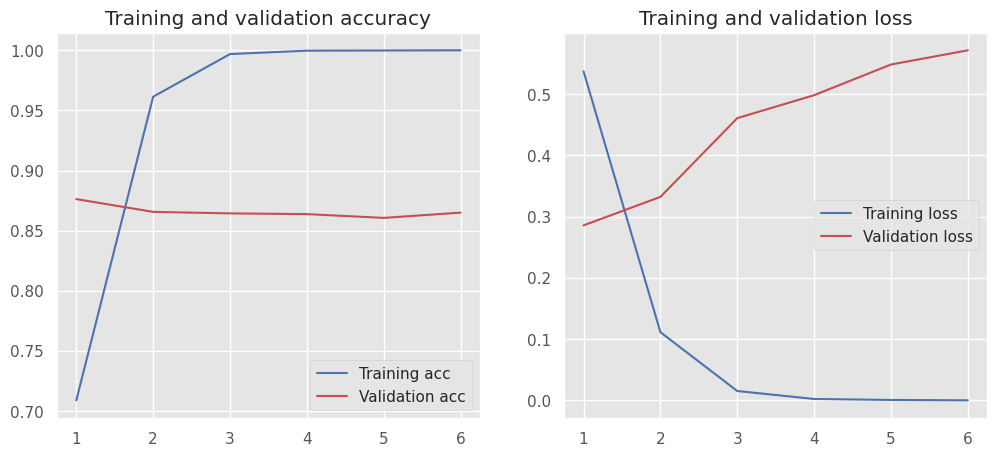

In [50]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierCNNV3
              precision    recall  f1-score   support

    negative       0.87      0.86      0.86      1025
    positive       0.85      0.87      0.86       975

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion matrix, without normalization


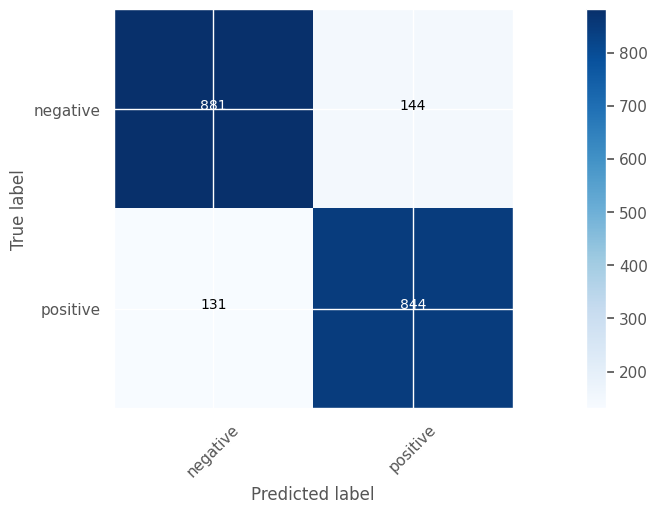


FINAL ACCURACY
0.8625 (86.25%)


In [51]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

Resultado similar a lo anterior.

Vamos a revisar cómo son los tamaños de los feature maps ahora con este modelo que tiene estos parámetros en
las convoluciones:

- S=2
- P=3
- K=7

Se ve que con estos parámetros se consigue que el tamaño de la dimensión espacial se divide entre 2.
El tamaño de los canales va aumentando según el número de filtros.

In [52]:
input_tensor = torch.randn((64,train_text_tfidf_features.shape[1]), device=device)
print(f"Input tensor shape: {input_tensor.shape}")
output = model(input_tensor, verbose=True)

Input tensor shape: torch.Size([64, 41847])
Tamaño de entrada a primera convolución: torch.Size([64, 1, 128])
Tamaño del primer feature map: torch.Size([64, 64, 64])
Tamaño del segundo feature map: torch.Size([64, 128, 32])


### Entrenamiento ID=9 TF-IDF - MLP - CNN - MLP
- Añadir dropout al modelo. p=0.5

Al añadir dropout se espera que se reduzca la posibilidad de hacer overfitting a los datos de entrenamiento.
Al desconectar neuronas en tiempo de entrenamiento con la probabilidad indicada, se espera que el modelo
aprenda a tener redundancias y esto puede que mejore cómo generaliza el sistema.

Se tiene ahora un nuevo parámetro para crear el modelo que es la probabilidad de dropout. Se añade
dropout en:
- Después de primera capa densa
- Después de conv1
- Después de conv2
- Después de fc1

In [53]:
class BinaryClassifierCNNV4(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, pooling_type='max', dropout=0.5):
        super(BinaryClassifierCNNV4, self).__init__()
        self.embedding_dim = embedding_dim
        self.embed = nn.Linear(input_dim, embedding_dim)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=7, padding=3, stride=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=7, padding=3, stride=2)
        self._pooling_type = pooling_type
        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)
        
        self.dropout = nn.Dropout(p=dropout)
    
    def forward(self, x, verbose=False):
        x = self.embed(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = x.unsqueeze(1)
        
        if verbose:
            print(f"Tamaño de entrada a primera convolución: {x.shape}")
        
        x = self.conv1(x)
        if verbose:
            print(f"Tamaño del primer feature map: {x.shape}")
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x)
        if verbose:
            print(f"Tamaño del segundo feature map: {x.shape}")
        x = F.relu(x)
        x = self.dropout(x)
        
        if self._pooling_type == "max":
            x = F.max_pool1d(x, kernel_size=x.size(2))
        elif self._pooling_type == "avg":
            x = F.avg_pool1d(x, kernel_size=x.size(2))
        elif self._pooling_type == "ad_avg":
            x = F.adaptive_avg_pool1d(x, output_size=1)
        else:
            raise RuntimeError(f"Wrong pooling type: {self._pooling_type}")
        
        x = x.squeeze(2)
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = torch.sigmoid(x)
        return x

In [54]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierCNNV4(input_dim, pooling_type="max", dropout=0.5)
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierCNNV4(
  (embed): Linear(in_features=41847, out_features=128, bias=True)
  (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (conv2): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embed.weight                             5,356,416       [128, 41847]        
embed.bias                               128             [128]               
conv1.weight                             448             [64, 1, 7]          
conv1.bias                               64              [64]                
conv2.weight                             57,344          [128, 64, 7]        
conv2.bias        

Epoch 1/40 - loss: 0.6949 - acc: 0.4881 - val_loss: 0.6939 - val_acc: 0.4963
Epoch 2/40 - loss: 0.5507 - acc: 0.6994 - val_loss: 0.4173 - val_acc: 0.8656
Epoch 3/40 - loss: 0.2231 - acc: 0.9263 - val_loss: 0.3809 - val_acc: 0.8606
 (patience: 1/5)
Epoch 4/40 - loss: 0.1019 - acc: 0.9722 - val_loss: 0.3827 - val_acc: 0.8369
Epoch 5/40 - loss: 0.0532 - acc: 0.9877 - val_loss: 0.3762 - val_acc: 0.8519
 (patience: 1/5)
Epoch 6/40 - loss: 0.0379 - acc: 0.9923 - val_loss: 0.4591 - val_acc: 0.8337
 (patience: 2/5)
Epoch 7/40 - loss: 0.0285 - acc: 0.9939 - val_loss: 0.5320 - val_acc: 0.8363
 (patience: 3/5)
Epoch 8/40 - loss: 0.0261 - acc: 0.9938 - val_loss: 0.4822 - val_acc: 0.8475
 (patience: 4/5)
Epoch 9/40 - loss: 0.0207 - acc: 0.9958 - val_loss: 0.4643 - val_acc: 0.8550
 (patience: 5/5)
Early stopping triggered at epoch 10


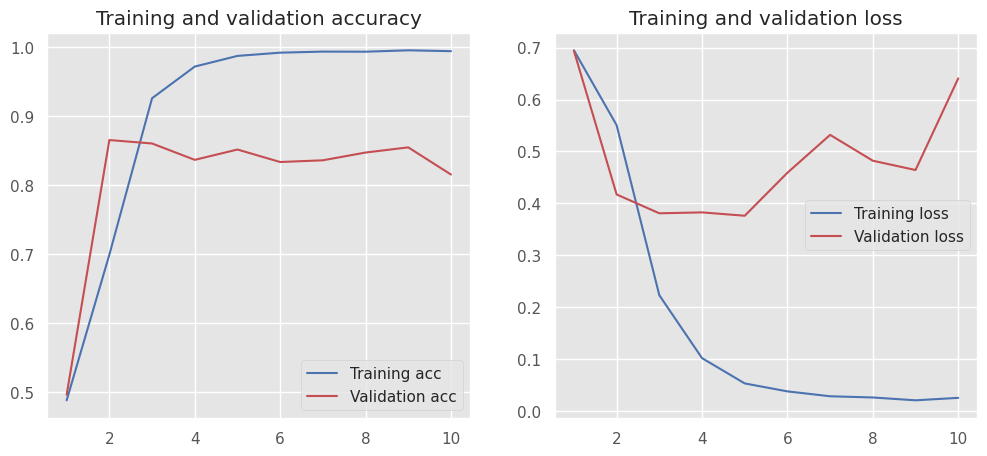

In [55]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierCNNV4
              precision    recall  f1-score   support

    negative       0.76      0.95      0.84      1025
    positive       0.93      0.69      0.79       975

    accuracy                           0.82      2000
   macro avg       0.84      0.82      0.82      2000
weighted avg       0.84      0.82      0.82      2000

Confusion matrix, without normalization


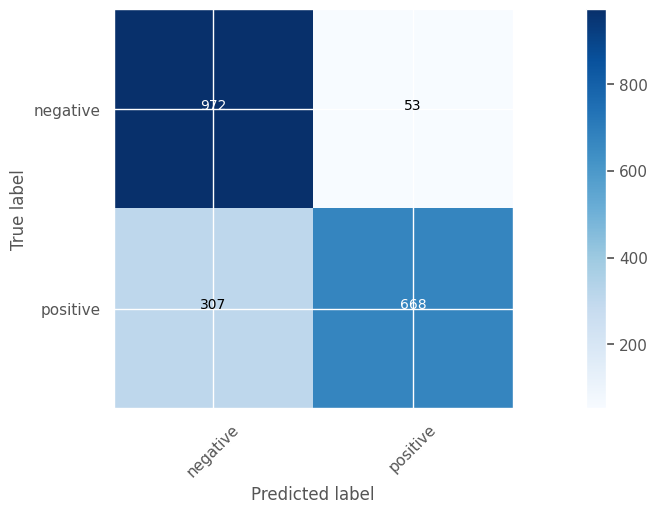


FINAL ACCURACY
0.8200 (82.00%)


In [56]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

Aunque la métrica de test sea peor a las anteriores, un cambio que se nota en este entrenamiento
es que se tarda más en hacer overfitting. El early stopping ha hecho que este entrenamiento termine en la
epoch 10 en vez de la epoch 6 como los anteriores entrenamientos.

### Entrenamiento ID=10 TD-IDF - MLP - CNN - MLP
En este experimento, vamos a probar la función de "aplanamiento".
En los modelos anteriores no se ha utilizado porque se ha utilizado la función pooling.
Esta colapsa la dimensión espacial de los feature maps en 1. Por ejemplo (vamos a llamar aquí a la dimensión espacial W de Width):

[B=64,C=128,W=128]

Si aplicamos pooling se convierte a:

[B=64, C=128, W=1]

Ahora vamos a cambiar la arquitectura para que en el siguiente modelo, se "aplanen" los canales de la siguiente manera:

[B=64, W=128x128]

Y después pondremos un MLP que pueda procesar este tamaño de entrada

In [57]:
class BinaryClassifierCNNVFlat(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, dropout=0.5):
        super(BinaryClassifierCNNVFlat, self).__init__()
        self.embedding_dim = embedding_dim
        self.embed = nn.Linear(input_dim, embedding_dim)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=7, padding=3, stride=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=7, padding=3, stride=2)

        # Aquí hay que tener cuidado con el tamaño de entrada de esta capa lineal. Hay que saber
        # cuál es el tamaño de salida de la convolución anterior ahora que se aplanan los canales a una
        # sola dimensión.
        # Como en este modelo se divide el tamaño espacial entre dos, la entrada es (C=128 * W=128/2/2 = 4096):
        fc1_input_shape = 128 * 32
        self.fc1 = nn.Linear(fc1_input_shape, 128)
        self.fc2 = nn.Linear(128, 32)
        self.fc3 = nn.Linear(32, 1)
        
        self.dropout = nn.Dropout(p=dropout)
    
    def forward(self, x, verbose=False):
        x = self.embed(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = x.unsqueeze(1)
        
        if verbose:
            print(f"Tamaño de entrada a primera convolución: {x.shape}")
        
        x = self.conv1(x)
        if verbose:
            print(f"Tamaño del primer feature map: {x.shape}")
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x)
        if verbose:
            print(f"Tamaño del segundo feature map: {x.shape}")
        x = F.relu(x)
        x = self.dropout(x)

        if verbose:
            print(f"Conv output shape: {x.shape}")

        # Aplanamiento:
        x = torch.flatten(x, start_dim=1)
        if verbose:
            print(f"Después del aplanamiento: {x.shape}")

        x = self.fc1(x)
        if verbose:
            print(f"Fc1 output shape: {x.shape}")
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        if verbose:
            print(f"Fc2 output shape: {x.shape}")
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)
        if verbose:
            print(f"Fc3 output shape: {x.shape}")
        x = torch.sigmoid(x)
        return x

In [58]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierCNNVFlat(input_dim, dropout=0.5)
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierCNNVFlat(
  (embed): Linear(in_features=41847, out_features=128, bias=True)
  (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (conv2): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embed.weight                             5,356,416       [128, 41847]        
embed.bias                               128             [128]               
conv1.weight                             448             [64, 1, 7]          
conv1.bias                               64              [64]                
conv2.weight                  

In [59]:
input_tensor = torch.randn((64,train_text_tfidf_features.shape[1]), device=device)
print(f"Input tensor shape: {input_tensor.shape}")
output = model(input_tensor, verbose=True)

Input tensor shape: torch.Size([64, 41847])
Tamaño de entrada a primera convolución: torch.Size([64, 1, 128])
Tamaño del primer feature map: torch.Size([64, 64, 64])
Tamaño del segundo feature map: torch.Size([64, 128, 32])
Conv output shape: torch.Size([64, 128, 32])
Después del aplanamiento: torch.Size([64, 4096])
Fc1 output shape: torch.Size([64, 128])
Fc2 output shape: torch.Size([64, 32])
Fc3 output shape: torch.Size([64, 1])


Epoch 1/40 - loss: 0.6957 - acc: 0.4927 - val_loss: 0.6933 - val_acc: 0.4963
Epoch 2/40 - loss: 0.6282 - acc: 0.5997 - val_loss: 0.3302 - val_acc: 0.8669
 (patience: 1/5)
Epoch 3/40 - loss: 0.2780 - acc: 0.9022 - val_loss: 0.3408 - val_acc: 0.8450
 (patience: 2/5)
Epoch 4/40 - loss: 0.0848 - acc: 0.9756 - val_loss: 0.3755 - val_acc: 0.8656
 (patience: 3/5)
Epoch 5/40 - loss: 0.0569 - acc: 0.9911 - val_loss: 0.8108 - val_acc: 0.8581
 (patience: 4/5)
Epoch 6/40 - loss: 0.0188 - acc: 0.9947 - val_loss: 0.8065 - val_acc: 0.8431
 (patience: 5/5)
Early stopping triggered at epoch 7


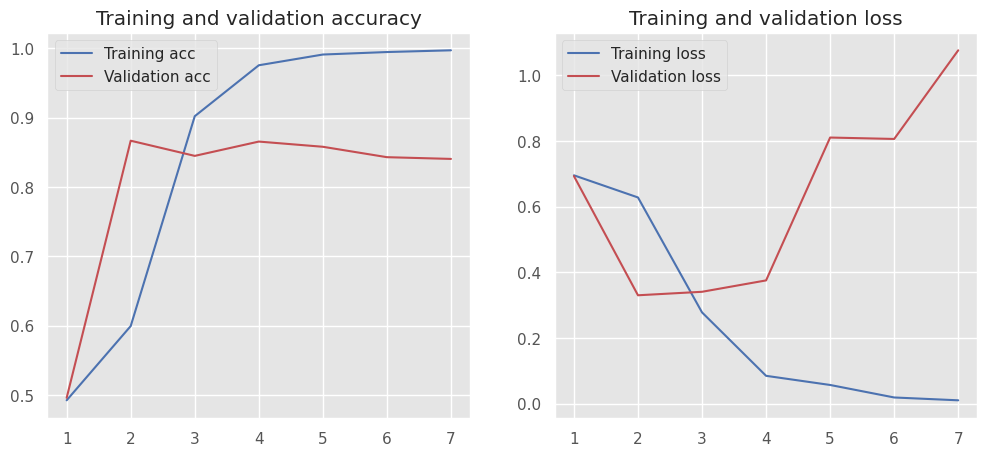

In [60]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassifierCNNVFlat
              precision    recall  f1-score   support

    negative       0.80      0.92      0.86      1025
    positive       0.90      0.75      0.82       975

    accuracy                           0.84      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.85      0.84      0.84      2000

Confusion matrix, without normalization


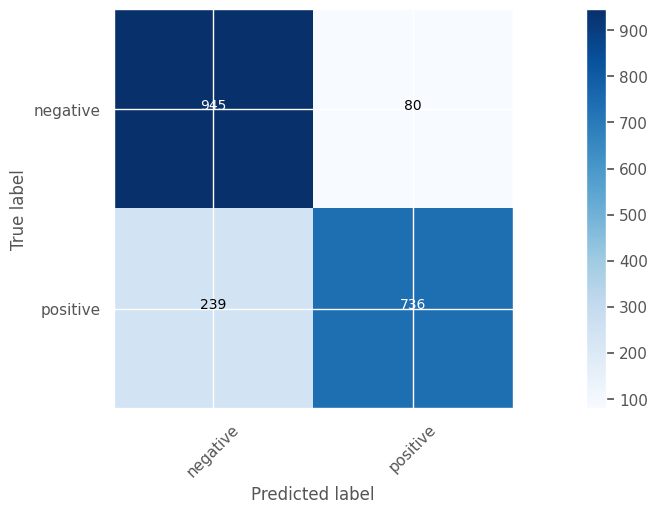


FINAL ACCURACY
0.8405 (84.05%)


In [61]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

Es un resultado bueno comparable al base MLP. En este modelo con el aplanamiento y la capa MLP hemos sustituido el pooling por parámetros aprendibles.

Con la representación TF-IDF se ha demonstrado que no funciona bien si se usa como entrada de convoluciones.
Se ha hecho un modelo combinado MLP - CNN - MLP
para ver si funciona mejor y se ha hecho una exploración de ciertos parámetros de las convoluciones (Tamaño del filtro, padding, stride) pero más por motivos de aprendizaje.

Intrínsicamente se necesita una representación mejor para las CNNs. Es lo que veremos en el siguiente apartado.

### Resultados

- ID=1 Accuracy = 86.90% TF-IDF Binary Classifier MLP (Experimento baseline)
- ID=2 (Validation) Accuracy = 52% TF-IDF CNN; CNN no extrae características útiles de TF-IDF 
- ID=3 Accuracy = 86.55% TF-IDF MLP CNN MLP
- ID=4 Accuracy = 86.00%
- ID=5 Accuracy = 85.80%
- ID=6 Accuracy = 85.90%
- ID=7 Accuracy = 86.45%
- ID=8 Accuracy = 86.25%
- ID=9 Accuracy = 82.00%
- ID=10 Accuracy = 84.05%

El mejor sigue siendo ligeramente el modelo con arquitectura más "simple". TF-IDF con capas MLP.

Pienso que algunos de estos resultados son sensibles en alrededor 0.5% - 1.0% a la inicialización de la red.

## Modelo basado en Word Embeddings y CNN

Para este problema, necesitaremos el texto tokenizado y compatible con la entrada que espera una capa de Word Embeddings, esto se calculará a continuación:

In [62]:
from tokenizers import Tokenizer, models, pre_tokenizers, trainers
tokenizer = Tokenizer(models.WordLevel(unk_token="<UNK>"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

VOCAB_SIZE = 41215

# Entrenamos un tokenizador WordLevel
# Vamos a usar este tokenizador, para que nos ayude a tener una representación de los tokens
# compatible con la entrada de word embeddings.
trainer = trainers.WordLevelTrainer(
    special_tokens=["<PAD>", "<UNK>"],
    vocab_size=VOCAB_SIZE,
    min_frequency=2
)

# Cogemos las reviews (raw) procesadas
train_text_list = X_train['processed_review'].to_list()
test_text_list = X_test['processed_review'].to_list()

# Entrenamos el tokenizador solamente sobre los datos de entrenamiento
tokenizer.train_from_iterator(train_text_list, trainer)

Quiero ver ahora, cuál es la distribución de las longitudes de las muestras de entrenamiento, para saber cuál
sería un valor razonable de longitud máxima de secuencia a procesar. Al tokenizar las reviews,
si una review es menor que la longitud máxima, se hará padding con padding token. Si una review es de longitud
mayor, se truncará.

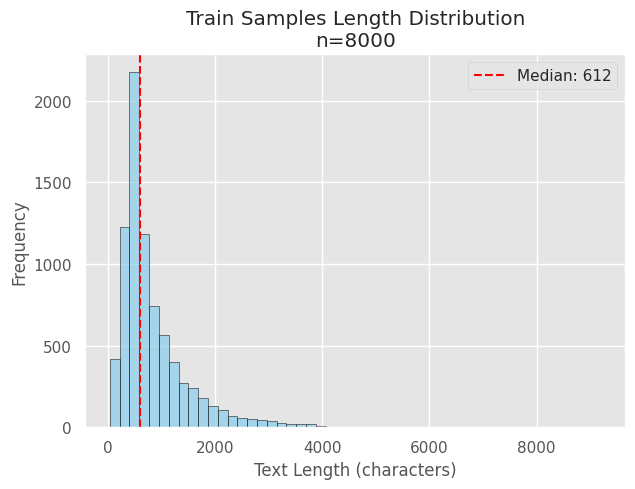

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate lengths (in characters)
train_lengths = [len(text) for text in train_text_list]

# Create the plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.title(f'Train Samples Length Distribution\nn={len(train_lengths)}')
plt.axvline(np.median(train_lengths), color='red', linestyle='--', label=f'Median: {np.median(train_lengths):.0f}')
plt.legend()

plt.tight_layout()
plt.show()

Selecciono 2000 como una longitud máxima

In [64]:
MAX_LENGTH=2000

# Configurar padding
tokenizer.enable_padding(pad_id=0, pad_token="<PAD>", length=MAX_LENGTH)
tokenizer.enable_truncation(max_length=MAX_LENGTH)

train_text_tokenized = tokenizer.encode_batch(train_text_list)
test_text_tokenized = tokenizer.encode_batch(test_text_list)

idx = 10
print(f"Texto original: {train_text_list[idx]}")
print(f"Token IDs: {train_text_tokenized[idx].ids}")
print(f"Tokens: {train_text_tokenized[idx].tokens}")
print(f"Longitud: {len(train_text_tokenized[idx].ids)}")

ids = torch.tensor([enc.ids for enc in train_text_tokenized])
print(ids)

Texto original: willing put lot late spring summer action fluff movie general due fact reasonable payoff e cool special effect interesting plot twist comic value steve buscemi etc movie however none got cheap thrill several minute eva longoria cleavage issue maxim cheaper movie ticket embarrassing lack plot suspense back story character development continuity etc would get specific quite frankly already maybe willingly forgotten movie entire time theater kicking not spending afternoon watching 24 season dvd save money one folk unless really really really like eva longoria cleavage
Token IDs: [1542, 150, 66, 393, 3082, 1398, 94, 4828, 3, 636, 534, 95, 4020, 6225, 554, 592, 215, 145, 121, 43, 518, 432, 531, 1152, 10355, 407, 3, 106, 448, 90, 581, 1960, 389, 101, 3297, 6179, 10393, 831, 1, 7981, 3, 2708, 2266, 353, 43, 717, 60, 11, 10, 686, 2525, 407, 8, 14, 2928, 91, 1998, 361, 178, 7157, 1446, 3, 328, 7, 458, 5152, 2, 2929, 2317, 68, 3219, 455, 183, 394, 190, 5, 1142, 775, 17, 17, 17, 6

In [65]:
# Convertir a tensor de PyTorch
X_train_text = torch.tensor([enc.ids for enc in train_text_tokenized], dtype=torch.long)
X_test_text = torch.tensor([enc.ids for enc in test_text_tokenized], dtype=torch.long)

print(f"X train shape: {X_train_text.shape}")
print(f"X test shape {X_test_text.shape}")

X train shape: torch.Size([8000, 2000])
X test shape torch.Size([2000, 2000])


In [66]:
print(X_train_text.max())
print(VOCAB_SIZE)

tensor(25971)
41215


### Entrenamiento ID=11 WE - MLP (Modelo base)


Usamos un modelo base como "experimento de control". Con la experiencia de la práctica anterior un modelo WE + MLP
debería obtener un resultado razonablemente bueno.

In [67]:
class SimpleEmbeddingNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, verbose=False):
        # x: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        if verbose:
            print(f"Embedded shape: {embedded.shape}")

        # Aplicar global average pooling
        pooled = torch.mean(embedded, dim=1)  # [batch_size, embedding_dim]

        if verbose:
            print(f"Pooled shape: {pooled.shape}")

        hidden = F.relu(self.fc1(pooled))
        output_logits = self.fc2(hidden)

        if verbose:
            print(f"Output logits shape: {output_logits.shape}")

        output = torch.sigmoid(output_logits)

        return output

In [68]:
model = SimpleEmbeddingNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=512,
    hidden_dim=128,
)
model = model.to(device)
print_model_info(model)

test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
SimpleEmbeddingNN(
  (embedding): Embedding(41215, 512, padding_idx=0)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         21,102,080      [41215, 512]        
fc1.weight                               65,536          [128, 512]          
fc1.bias                                 128             [128]               
fc2.weight                               128             [1, 128]            
fc2.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        21,167,873
Trainable Parameters:                    21,167,873
Non-trainable Parameters:         

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6354 - acc: 0.6998 - val_loss: 0.4953 - val_acc: 0.8187
Epoch 2/40 - loss: 0.3434 - acc: 0.8723 - val_loss: 0.3425 - val_acc: 0.8694
Epoch 3/40 - loss: 0.1997 - acc: 0.9314 - val_loss: 0.3181 - val_acc: 0.8750
 (patience: 1/5)
Epoch 4/40 - loss: 0.1284 - acc: 0.9597 - val_loss: 0.3305 - val_acc: 0.8725
 (patience: 2/5)
Epoch 5/40 - loss: 0.0841 - acc: 0.9770 - val_loss: 0.3375 - val_acc: 0.8794
 (patience: 3/5)
Epoch 6/40 - loss: 0.0551 - acc: 0.9872 - val_loss: 0.3675 - val_acc: 0.8750
 (patience: 4/5)
Epoch 7/40 - loss: 0.0363 - acc: 0.9930 - val_loss: 0.4482 - val_acc: 0.8769
 (patience: 5/5)
Early stopping triggered at epoch 8


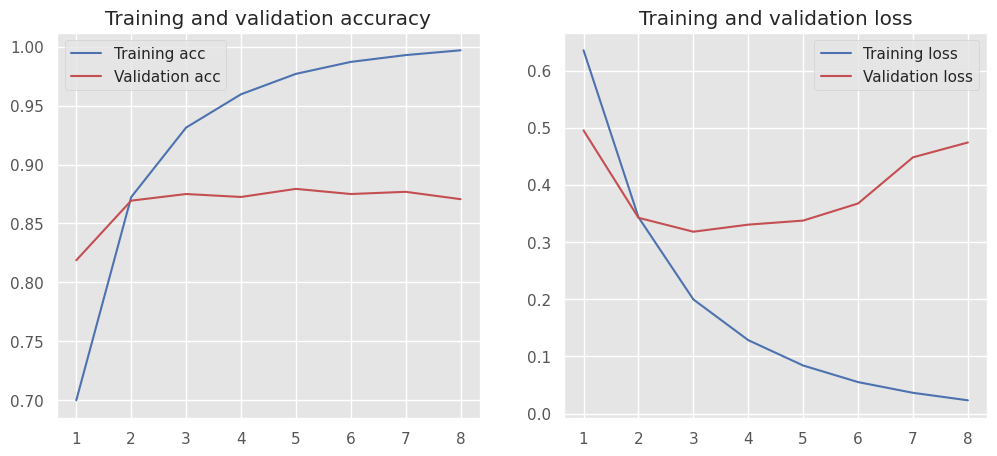

In [69]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - SimpleEmbeddingNN
              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      1025
    positive       0.85      0.89      0.87       975

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion matrix, without normalization


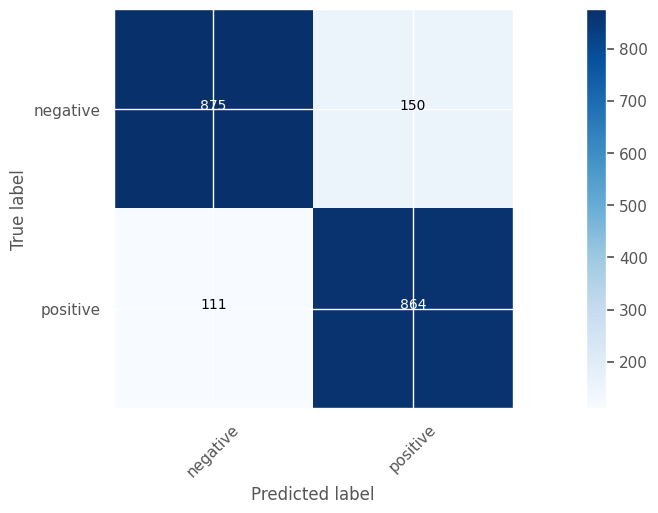


FINAL ACCURACY
0.8695 (86.95%)


In [70]:
y_pred = evaluate_pytorch_model(model, X_test_text, Y_test, le, target_labels, device)

El resultado está bien. Continuaremos los experimentos añadiendo capas convolucionales después de Word Embeddings.

### Entrenamiento ID=12 WE - CNN - MLP
S = 2
K = 7
P = 3

Esta es la primera vez, que usamos una CNN después de la representación word embeddings.
Recordamos que anteriormente, una CNN después de la representación TF-IDF no funcionó bien.
Esperamos ahora que como la representación de word embeddings sí que mantiene información
del orden de la secuencia, la CNN sea capaz de encontrar patrones locales que sean útiles
para la clasificación de la secuencia.

In [71]:
class EmbeddingCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=embedding_dim*2, kernel_size=7, padding=3, stride=2)
        self.conv2 = nn.Conv1d(in_channels=embedding_dim*2, out_channels=embedding_dim*4, kernel_size=7, padding=3, stride=2)

        self.global_avg_pool = nn.AdaptiveAvgPool1d(output_size=1)

        self.fc1 = nn.Linear(embedding_dim*2*2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, verbose=False):
        # x: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        if verbose:
            print(f"Embedded shape: {embedded.shape}")

        # Cambiamos de [B, S, E] a [B, E, S]
        # Los "canales" de la convolusión ahora es E (Embedded dim)
        embedded_transposed = embedded.permute(0, 2, 1)

        x = self.conv1(embedded_transposed)
        if verbose:
            print(f"Tamaño del primer feature map: {x.shape}")
        x = F.relu(x)

        x = self.conv2(x)
        if verbose:
            print(f"Tamaño del segundo feature map: {x.shape}")
        # [B, E*2*2, S/2/2]
        x = F.relu(x)

        # Aplicamos aquí global avg pooling
        # Colapsa la dimensión "espacial"
        pooled = self.global_avg_pool(x) # -> [B, E*2*2, 1]

        if verbose:
            print(f"Pooled shape: {pooled.shape}")

        # Ahora usamos los MLPs para procesar las features globales
        # Hay que eliminar la última dimensión
        mlp_input = pooled.squeeze(-1)
        if verbose:
            print(f"MLP input shape: {mlp_input.shape}")

        x = self.fc1(mlp_input)
        if verbose:
            print(f"Fc1 output shape: {x.shape}")
        x = F.relu(x)
        
        x = self.fc2(x)
        if verbose:
            print(f"Fc2 output shape: {x.shape}")
        x = torch.sigmoid(x)
        return x

In [72]:
model = EmbeddingCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_dim=128,
)
model = model.to(device)
print_model_info(model)

test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
EmbeddingCNN(
  (embedding): Embedding(41215, 64, padding_idx=0)
  (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,))
  (conv2): Conv1d(128, 256, kernel_size=(7,), stride=(2,), padding=(3,))
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,637,760       [41215, 64]         
conv1.weight                             57,344          [128, 64, 7]        
conv1.bias                               128             [128]               
conv2.weight                             229,376         [256, 128, 7]       
conv2.bias                               256             [256]               
fc1.weight                

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6567 - acc: 0.5761 - val_loss: 0.5156 - val_acc: 0.7475
Epoch 2/40 - loss: 0.4258 - acc: 0.8106 - val_loss: 0.4149 - val_acc: 0.8313
 (patience: 1/5)
Epoch 3/40 - loss: 0.2722 - acc: 0.8902 - val_loss: 0.4206 - val_acc: 0.8300
 (patience: 2/5)
Epoch 4/40 - loss: 0.1746 - acc: 0.9370 - val_loss: 0.4237 - val_acc: 0.8394
 (patience: 3/5)
Epoch 5/40 - loss: 0.0880 - acc: 0.9739 - val_loss: 0.5962 - val_acc: 0.8462
 (patience: 4/5)
Epoch 6/40 - loss: 0.0339 - acc: 0.9917 - val_loss: 0.7352 - val_acc: 0.8450
 (patience: 5/5)
Early stopping triggered at epoch 7


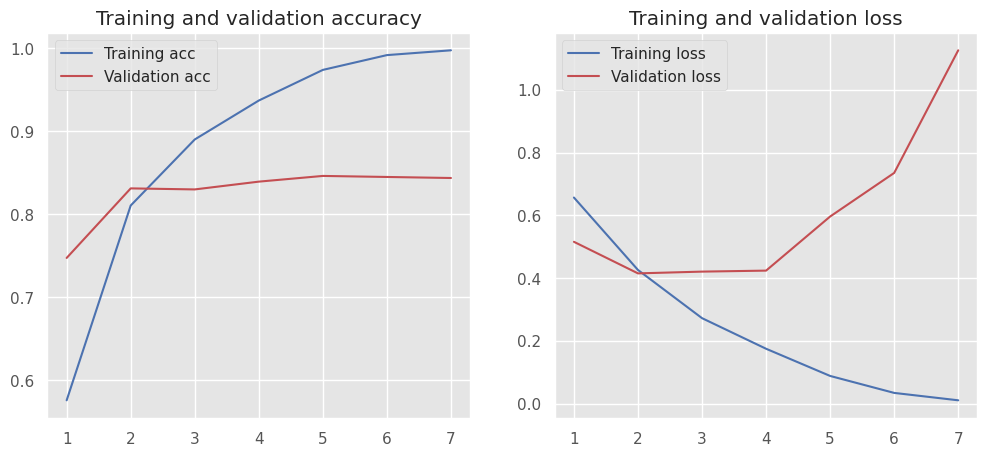

In [73]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - EmbeddingCNN
              precision    recall  f1-score   support

    negative       0.83      0.80      0.81      1025
    positive       0.79      0.82      0.81       975

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

Confusion matrix, without normalization


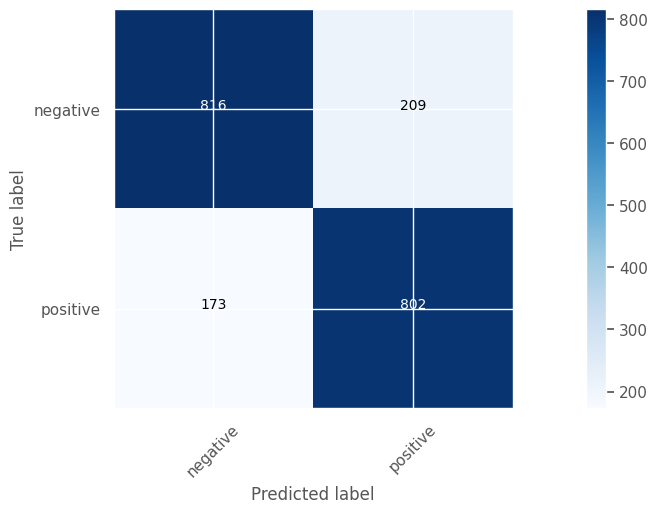


FINAL ACCURACY
0.8090 (80.90%)


In [74]:
y_pred = evaluate_pytorch_model(model, X_test_text, Y_test, le, target_labels, device)

El modelo puede aprender mucho mejor que con la representación TF-IDF. Pero es peor que el modelo WE + MLP.
Vamos a ver si podemos hacer algo.

### Entrenamiento ID=13 WE - CNN - MLP
- Reducir el tamaño del kernel a 3
- Añadir otra convolución para aumentar la profundidad del modelo

In [75]:
class EmbeddingCNNV2(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=embedding_dim*2, kernel_size=3, padding=1, stride=1)
        self.conv2 = nn.Conv1d(in_channels=embedding_dim*2, out_channels=embedding_dim*4, kernel_size=3, padding=1, stride=1)
        self.conv3 = nn.Conv1d(in_channels=embedding_dim*4, out_channels=embedding_dim*8, kernel_size=3, padding=1, stride=1)

        self.global_max_pool = nn.AdaptiveMaxPool1d(output_size=1)

        self.fc1 = nn.Linear(embedding_dim*2*2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, verbose=False):
        # x: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        if verbose:
            print(f"Embedded shape: {embedded.shape}")

        # Cambiamos de [B, S, E] a [B, E, S]
        # Los "canales" de la convolusión ahora es E (Embedded dim)
        embedded_transposed = embedded.permute(0, 2, 1)

        x = self.conv1(embedded_transposed)
        if verbose:
            print(f"Tamaño del primer feature map: {x.shape}")
        x = F.relu(x)

        x = self.conv2(x)
        if verbose:
            print(f"Tamaño del segundo feature map: {x.shape}")
        # [B, E*2*2, S/2/2]
        x = F.relu(x)

        # Aplicamos aquí global max pooling
        # Colapsa la dimensión "espacial"
        pooled = self.global_max_pool(x) # -> [B, E*2*2, 1]

        if verbose:
            print(f"Pooled shape: {pooled.shape}")

        # Ahora usamos los MLPs para procesar las features globales
        # Hay que eliminar la última dimensión
        mlp_input = pooled.squeeze(-1)
        if verbose:
            print(f"MLP input shape: {mlp_input.shape}")

        x = self.fc1(mlp_input)
        if verbose:
            print(f"Fc1 output shape: {x.shape}")
        x = F.relu(x)
        
        x = self.fc2(x)
        if verbose:
            print(f"Fc2 output shape: {x.shape}")
        x = torch.sigmoid(x)
        return x

In [76]:
model = EmbeddingCNNV2(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_dim=128,
)
model = model.to(device)
print_model_info(model)

test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
EmbeddingCNNV2(
  (embedding): Embedding(41215, 64, padding_idx=0)
  (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv3): Conv1d(256, 512, kernel_size=(3,), stride=(1,), padding=(1,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,637,760       [41215, 64]         
conv1.weight                             24,576          [128, 64, 3]        
conv1.bias                               128             [128]               
conv2.weight                             98,304          [256, 128, 3]       
conv2.bias                   

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6538 - acc: 0.5972 - val_loss: 0.5506 - val_acc: 0.7094
Epoch 2/40 - loss: 0.4485 - acc: 0.7933 - val_loss: 0.5349 - val_acc: 0.7394
Epoch 3/40 - loss: 0.2480 - acc: 0.9047 - val_loss: 0.4509 - val_acc: 0.8069
 (patience: 1/5)
Epoch 4/40 - loss: 0.0814 - acc: 0.9778 - val_loss: 0.5788 - val_acc: 0.8075
 (patience: 2/5)
Epoch 5/40 - loss: 0.0157 - acc: 0.9977 - val_loss: 0.6875 - val_acc: 0.7963
 (patience: 3/5)
Epoch 6/40 - loss: 0.0023 - acc: 1.0000 - val_loss: 0.7304 - val_acc: 0.8081
 (patience: 4/5)
Epoch 7/40 - loss: 0.0008 - acc: 1.0000 - val_loss: 0.7752 - val_acc: 0.8113
 (patience: 5/5)
Early stopping triggered at epoch 8


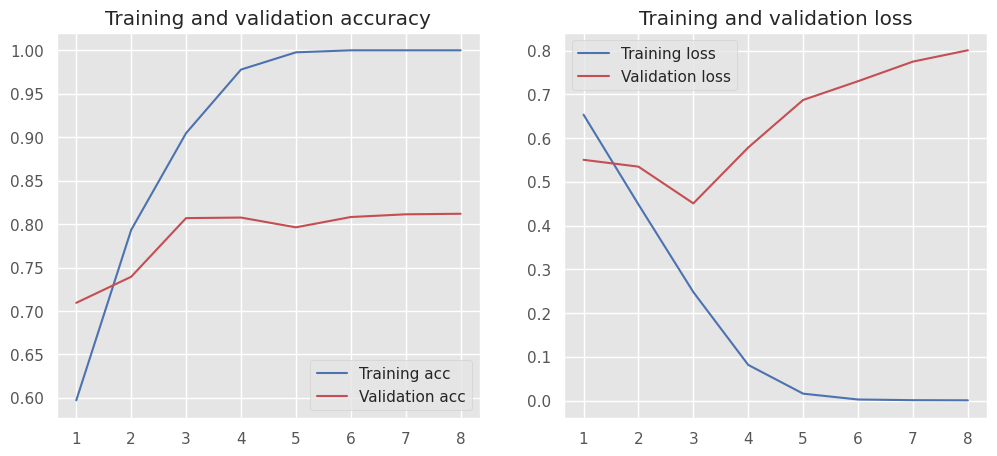

In [77]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - EmbeddingCNNV2
              precision    recall  f1-score   support

    negative       0.81      0.80      0.81      1025
    positive       0.80      0.80      0.80       975

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000

Confusion matrix, without normalization


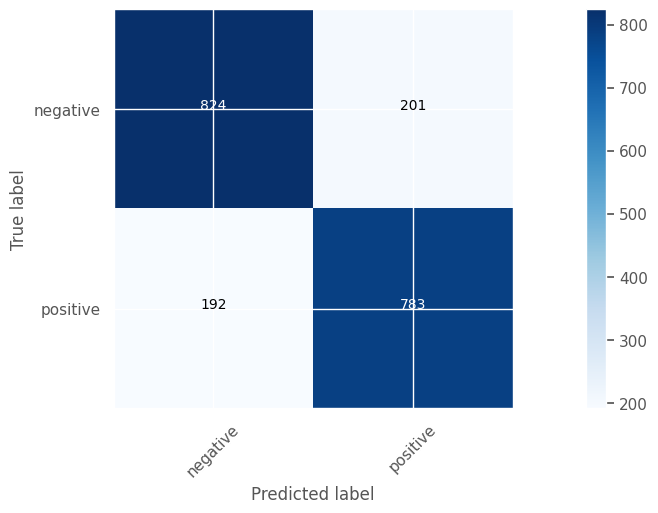


FINAL ACCURACY
0.8035 (80.35%)


In [78]:
y_pred = evaluate_pytorch_model(model, X_test_text, Y_test, le, target_labels, device)

La accuracy es similar que en entrenamiento anterior. Como el training loss disiminuye, mientras que la validation loss aumenta, pienso que hay overfitting. Vamos a probar ahora con regularizaciones (dropout)

### Entrenamiento ID=14 WE - CNN - MLP
- Dropout = 0.3


In [79]:
class EmbeddingCNNV3(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=embedding_dim*2, kernel_size=3, padding=1, stride=1)
        self.conv2 = nn.Conv1d(in_channels=embedding_dim*2, out_channels=embedding_dim*4, kernel_size=3, padding=1, stride=1)
        self.conv3 = nn.Conv1d(in_channels=embedding_dim*4, out_channels=embedding_dim*8, kernel_size=3, padding=1, stride=1)

        self.global_max_pool = nn.AdaptiveMaxPool1d(output_size=1)

        self.fc1 = nn.Linear(embedding_dim*2*2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, verbose=False):
        # x: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        if verbose:
            print(f"Embedded shape: {embedded.shape}")

        # Cambiamos de [B, S, E] a [B, E, S]
        # Los "canales" de la convolusión ahora es E (Embedded dim)
        embedded_transposed = embedded.permute(0, 2, 1)

        x = self.conv1(embedded_transposed)
        if verbose:
            print(f"Tamaño del primer feature map: {x.shape}")
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x)
        if verbose:
            print(f"Tamaño del segundo feature map: {x.shape}")
        # [B, E*2*2, S/2/2]
        x = F.relu(x)
        x = self.dropout(x)

        # Aplicamos aquí global max pooling
        # Colapsa la dimensión "espacial"
        pooled = self.global_max_pool(x) # -> [B, E*2*2, 1]

        if verbose:
            print(f"Pooled shape: {pooled.shape}")

        # Ahora usamos los MLPs para procesar las features globales
        # Hay que eliminar la última dimensión
        mlp_input = pooled.squeeze(-1)
        if verbose:
            print(f"MLP input shape: {mlp_input.shape}")

        x = self.fc1(mlp_input)
        if verbose:
            print(f"Fc1 output shape: {x.shape}")
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        if verbose:
            print(f"Fc2 output shape: {x.shape}")
        x = torch.sigmoid(x)
        return x

In [80]:
model = EmbeddingCNNV3(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_dim=128,
    dropout=0.3
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
EmbeddingCNNV3(
  (embedding): Embedding(41215, 64, padding_idx=0)
  (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv3): Conv1d(256, 512, kernel_size=(3,), stride=(1,), padding=(1,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,637,760       [41215, 64]         
conv1.weight                             24,576          [128, 64, 3]        
conv1.bias                               128             [128]               
conv2.weight                             98,304          [256, 1

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6956 - acc: 0.5136 - val_loss: 0.6835 - val_acc: 0.5737
Epoch 2/40 - loss: 0.5989 - acc: 0.6781 - val_loss: 0.5586 - val_acc: 0.7306
Epoch 3/40 - loss: 0.4517 - acc: 0.7963 - val_loss: 0.4738 - val_acc: 0.7794
Epoch 4/40 - loss: 0.3181 - acc: 0.8703 - val_loss: 0.4087 - val_acc: 0.8181
Epoch 5/40 - loss: 0.2164 - acc: 0.9187 - val_loss: 0.3935 - val_acc: 0.8263
 (patience: 1/5)
Epoch 6/40 - loss: 0.1343 - acc: 0.9516 - val_loss: 0.4544 - val_acc: 0.8056
 (patience: 2/5)
Epoch 7/40 - loss: 0.0896 - acc: 0.9711 - val_loss: 0.4455 - val_acc: 0.8156
 (patience: 3/5)
Epoch 8/40 - loss: 0.0563 - acc: 0.9827 - val_loss: 0.4950 - val_acc: 0.8156
 (patience: 4/5)
Epoch 9/40 - loss: 0.0535 - acc: 0.9809 - val_loss: 0.4890 - val_acc: 0.8131
 (patience: 5/5)
Early stopping triggered at epoch 10


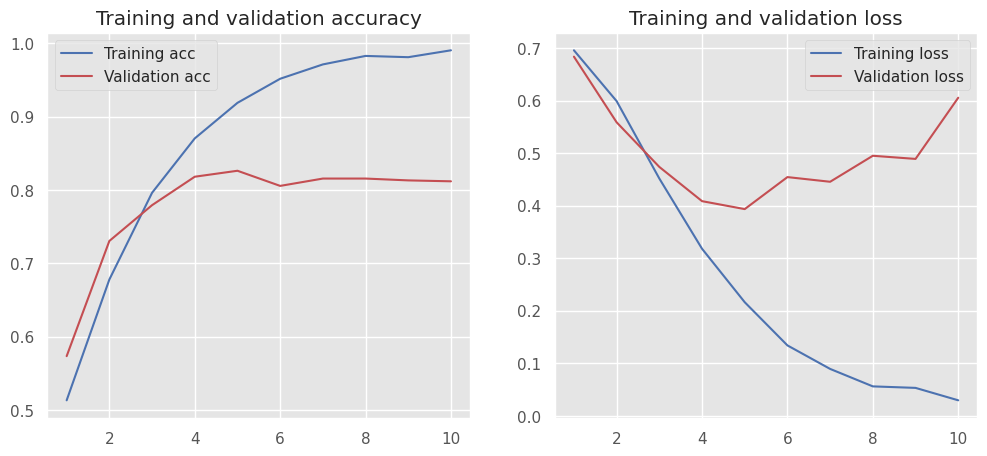

In [81]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - EmbeddingCNNV3
              precision    recall  f1-score   support

    negative       0.79      0.86      0.82      1025
    positive       0.84      0.76      0.80       975

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

Confusion matrix, without normalization


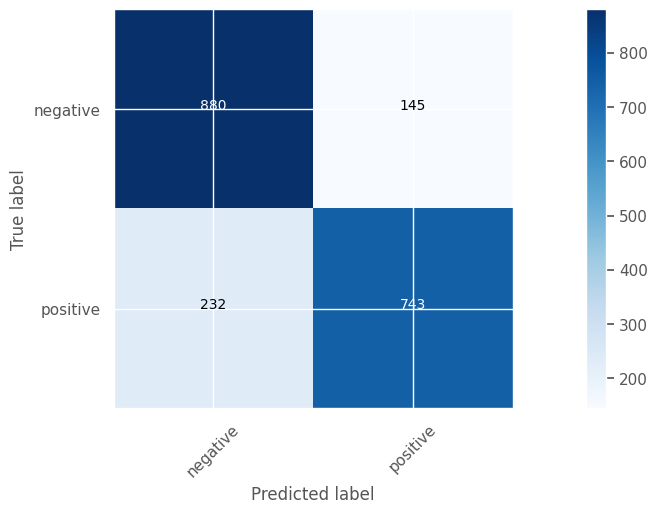


FINAL ACCURACY
0.8115 (81.15%)


In [82]:
y_pred = evaluate_pytorch_model(model, X_test_text, Y_test, le, target_labels, device)

Ha mejorado un poco. Voy a aumentar el Dropout a 0.5

### Entrenamiento ID=15 WE - CNN - MLP
- Dropout = 0.5

In [83]:
model = EmbeddingCNNV3(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_dim=128,
    dropout=0.5
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
EmbeddingCNNV3(
  (embedding): Embedding(41215, 64, padding_idx=0)
  (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv3): Conv1d(256, 512, kernel_size=(3,), stride=(1,), padding=(1,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,637,760       [41215, 64]         
conv1.weight                             24,576          [128, 64, 3]        
conv1.bias                               128             [128]               
conv2.weight                             98,304          [256, 1

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.7005 - acc: 0.5059 - val_loss: 0.6930 - val_acc: 0.5062
 (patience: 1/5)
Epoch 2/40 - loss: 0.6934 - acc: 0.4983 - val_loss: 0.6931 - val_acc: 0.5038
 (patience: 2/5)
Epoch 3/40 - loss: 0.6930 - acc: 0.5191 - val_loss: 0.6931 - val_acc: 0.5038
Epoch 4/40 - loss: 0.6917 - acc: 0.5186 - val_loss: 0.6845 - val_acc: 0.6587
Epoch 5/40 - loss: 0.5920 - acc: 0.6817 - val_loss: 0.5210 - val_acc: 0.7575
Epoch 6/40 - loss: 0.4063 - acc: 0.8264 - val_loss: 0.4700 - val_acc: 0.7875
Epoch 7/40 - loss: 0.2910 - acc: 0.8839 - val_loss: 0.4652 - val_acc: 0.7675
Epoch 8/40 - loss: 0.2155 - acc: 0.9220 - val_loss: 0.4116 - val_acc: 0.8181
 (patience: 1/5)
Epoch 9/40 - loss: 0.1520 - acc: 0.9478 - val_loss: 0.4141 - val_acc: 0.8156
 (patience: 2/5)
Epoch 10/40 - loss: 0.1136 - acc: 0.9605 - val_loss: 0.4195 - val_acc: 0.8113
 (patience: 3/5)
Epoch 11/40 - loss: 0.0796 - acc: 0.9748 - val_loss: 0.4241 - val_acc: 0.8163
 (patience: 4/5)
Epoch 12/40 - loss: 0.0545 - acc: 0.9822 - val_lo

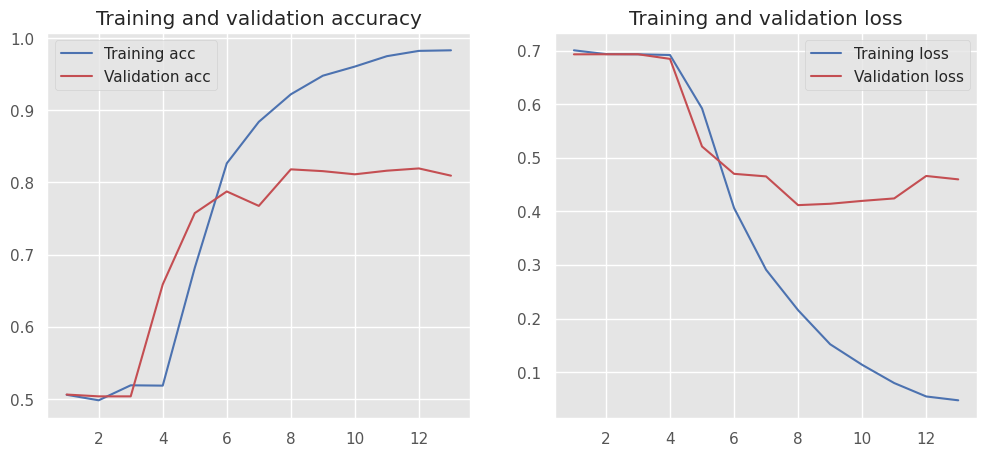

In [84]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - EmbeddingCNNV3
              precision    recall  f1-score   support

    negative       0.80      0.85      0.82      1025
    positive       0.83      0.77      0.80       975

    accuracy                           0.81      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

Confusion matrix, without normalization


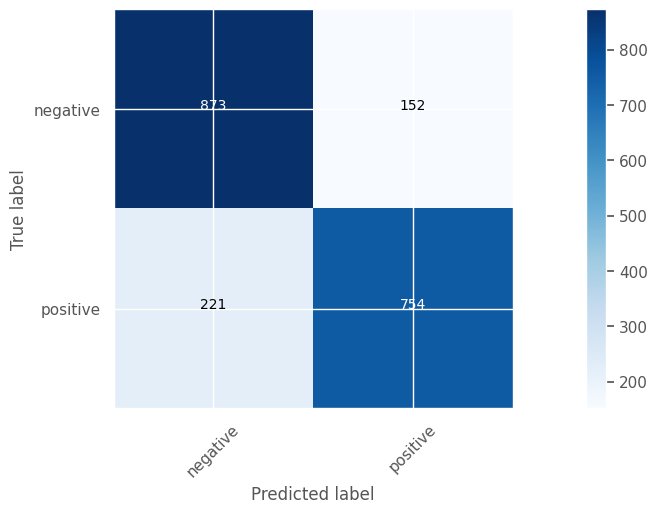


FINAL ACCURACY
0.8135 (81.35%)


In [85]:
y_pred = evaluate_pytorch_model(model, X_test_text, Y_test, le, target_labels, device)

Similar al dropout 0.3 también.

Voy a cambiar ahora el learning rate, a ver si el entrenamiento es algo más estable y 
converge mejor.

### Entrenamiento ID=16 WE - CNN - MLP

- Entrenamiento con Cosine Scheduler LR

In [86]:
model = EmbeddingCNNV3(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_dim=128,
    dropout=0.3
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
EmbeddingCNNV3(
  (embedding): Embedding(41215, 64, padding_idx=0)
  (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv3): Conv1d(256, 512, kernel_size=(3,), stride=(1,), padding=(1,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,637,760       [41215, 64]         
conv1.weight                             24,576          [128, 64, 3]        
conv1.bias                               128             [128]               
conv2.weight                             98,304          [256, 1

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Stepping learning rate to value: [0.000978266982572228]
Epoch 1/40 - loss: 0.6732 - acc: 0.5611 - val_loss: 0.6093 - val_acc: 0.6881
Stepping learning rate to value: [0.0009255265423839751]
Epoch 2/40 - loss: 0.5438 - acc: 0.7208 - val_loss: 0.4969 - val_acc: 0.7531
Stepping learning rate to value: [0.0008550992276841412]
Epoch 3/40 - loss: 0.3910 - acc: 0.8311 - val_loss: 0.4369 - val_acc: 0.7969
Stepping learning rate to value: [0.0007700306270606676]
Epoch 4/40 - loss: 0.2693 - acc: 0.8925 - val_loss: 0.4215 - val_acc: 0.7994
Stepping learning rate to value: [0.0006740035774996317]
Epoch 5/40 - loss: 0.1790 - acc: 0.9397 - val_loss: 0.4098 - val_acc: 0.8106
Stepping learning rate to value: [0.0005711751638541405]
 (patience: 1/5)
Epoch 6/40 - loss: 0.1149 - acc: 0.9602 - val_loss: 0.4396 - val_acc: 0.8194
Stepping learning rate to value: [0.00046599208849497923]
 (patience: 2/5)
Epoch 7/40 - loss: 0.0784 - acc: 0.9755 - val_loss: 0.4641 - val_acc: 0.8137
Stepping learning rate to va

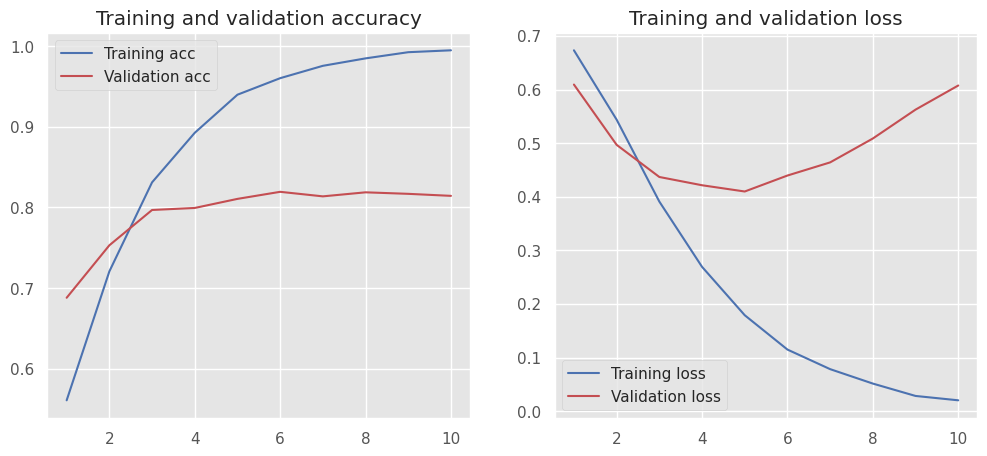

In [87]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
lr_scheduler = CosineAnnealingLR(optimizer, T_max=15)

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=optimizer,
  criterion=criterion,
  patience=5,
  scheduler=lr_scheduler)
plot_history(history)


CLASSIFICATION REPORT - EmbeddingCNNV3
              precision    recall  f1-score   support

    negative       0.78      0.88      0.83      1025
    positive       0.86      0.74      0.79       975

    accuracy                           0.81      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.82      0.81      0.81      2000

Confusion matrix, without normalization


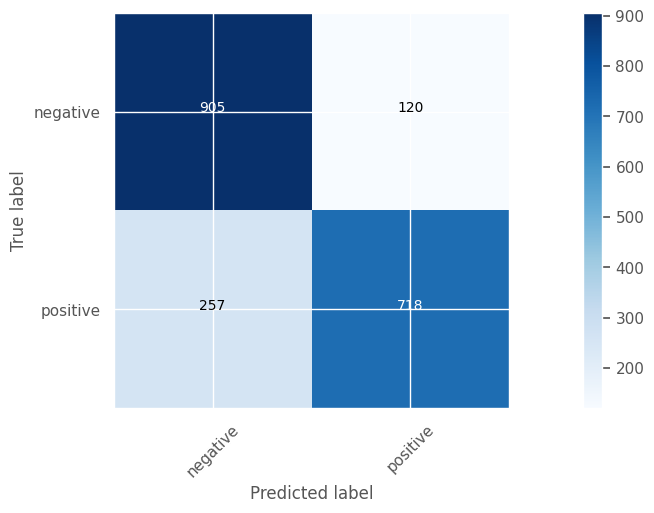


FINAL ACCURACY
0.8115 (81.15%)


In [88]:
y_pred = evaluate_pytorch_model(model, X_test_text, Y_test, le, target_labels, device)

La accuracy está en el mismo orden. Learning rate no parece ser un problema. No veo inestabilidades notables en las curva de pérdidas.
Y tampoco veo que se aprenda muy lento.

### Entrenamiento ID=17 WE - CNN - MLP: CNN con diferentes tamaño de kernel

En anteriores experimentos, hemos probado con diferentes tamaños de kernel.

He buscado en la literatura arquitecturas conocidas de CNN para texto (o secuencias unidimensionales) y he encontrado la idea de usar en paralelo convoluciones con diferente
tamaño de filtro: https://arxiv.org/pdf/1408.5882

En el siguiente modelo, en paralelo, se va a procesar los word embeddings con un filtro de tamaño 3, con otro de tamaño 5 y otro de
tamaño 7. En la salida de cada convolución se aplica max pooling (esto hará también que el tamaño de salida de todas las convoluciones
sea el mismo) y la salida de cada filtro se concatena.

In [89]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, 
                 kernel_sizes=[3, 4, 5], num_filters=100, dropout=0.5):
        super(TextCNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, 
                     out_channels=num_filters, 
                     kernel_size=k)
            for k in kernel_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, 1)
    
    def forward(self, x, verbose=False):
        # [batch_size, seq_len]
        x = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        if verbose:
            print(f"Embedded dim: {x.shape}")
        
        # Permutamos, para cambiar al canal y espacial [batch_size, embedding_dim, seq_len]
        x = x.permute(0, 2, 1)  # [batch_size, embedding_dim, seq_len]
        
        conv_outputs = []
        for idx, conv in enumerate(self.convs):
            if verbose:
                print(f"Conv {idx} input shape: {x.shape}")

            conv_out = F.relu(conv(x))  # [batch_size, num_filters, seq_len - kernel_size + 1]

            if verbose:
                print(f"Conv {idx} output shape: {conv_out.shape}")
            pooled = F.max_pool1d(conv_out, conv_out.size(2))  # [batch_size, num_filters, 1]

            if verbose:
                print(f"Pooled output shape: {pooled.shape}")

            conv_outputs.append(pooled.squeeze(2))  # [batch_size, num_filters]
        
        # Concatenate all outputs
        x = torch.cat(conv_outputs, dim=1)  # [batch_size, num_filters * len(kernel_sizes)]
        
        x = self.dropout(x)

        if verbose:
            print(f"FC input shape: {x.shape}")

        x = self.fc(x)  # [batch_size, num_classes]
        
        x = torch.sigmoid(x)

        return x

In [90]:
model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=300,
    num_filters=100,
    dropout=0.5
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
TextCNN(
  (embedding): Embedding(41215, 300)
  (convs): ModuleList(
    (0): Conv1d(300, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(300, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         12,364,500      [41215, 300]        
convs.0.weight                           90,000          [100, 300, 3]       
convs.0.bias                             100             [100]               
convs.1.weight                           120,000         [100, 300, 4]       
convs.1.bias                             100             [100]               
convs.2.weight                           150,000         [100, 300

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6400 - acc: 0.6541 - val_loss: 0.4528 - val_acc: 0.7994
Epoch 2/40 - loss: 0.4169 - acc: 0.8102 - val_loss: 0.3873 - val_acc: 0.8275
Epoch 3/40 - loss: 0.3299 - acc: 0.8562 - val_loss: 0.3578 - val_acc: 0.8419
Epoch 4/40 - loss: 0.2501 - acc: 0.8933 - val_loss: 0.3525 - val_acc: 0.8544
Epoch 5/40 - loss: 0.1838 - acc: 0.9311 - val_loss: 0.3481 - val_acc: 0.8544
 (patience: 1/5)
Epoch 6/40 - loss: 0.1513 - acc: 0.9372 - val_loss: 0.3495 - val_acc: 0.8544
 (patience: 2/5)
Epoch 7/40 - loss: 0.1298 - acc: 0.9486 - val_loss: 0.3824 - val_acc: 0.8469
 (patience: 3/5)
Epoch 8/40 - loss: 0.1043 - acc: 0.9616 - val_loss: 0.3691 - val_acc: 0.8612
 (patience: 4/5)
Epoch 9/40 - loss: 0.0848 - acc: 0.9673 - val_loss: 0.3758 - val_acc: 0.8612
 (patience: 5/5)
Early stopping triggered at epoch 10


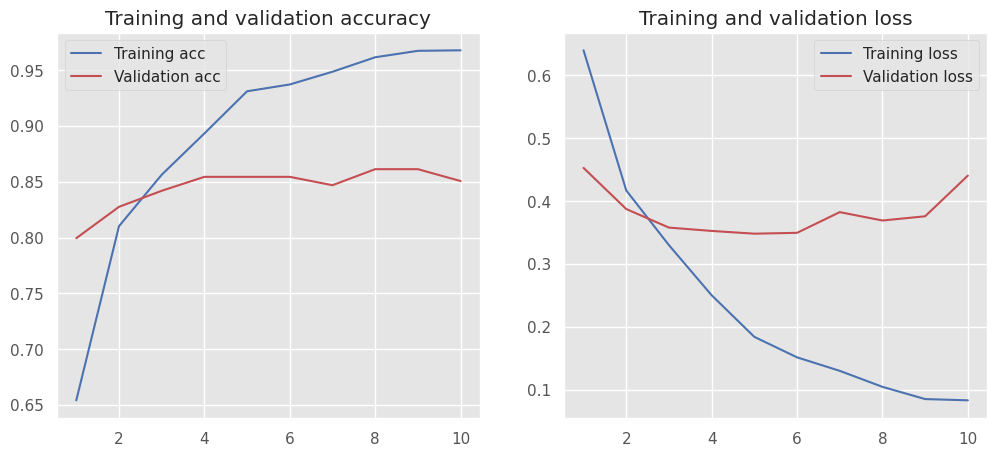

In [91]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - TextCNN
              precision    recall  f1-score   support

    negative       0.80      0.92      0.85      1025
    positive       0.90      0.75      0.82       975

    accuracy                           0.84      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.84      0.84      0.84      2000

Confusion matrix, without normalization


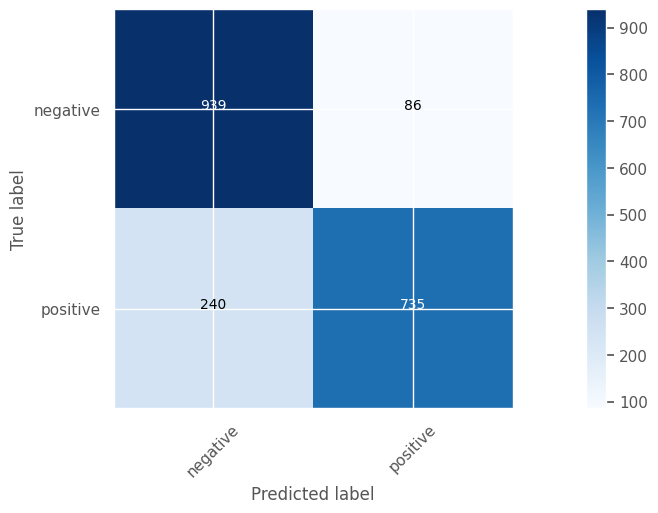


FINAL ACCURACY
0.8370 (83.70%)


In [92]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

Se obtiene una accuracy mejor que las anteriores en la combinación WE+CNN.

A partir de este modelo, vamos a explorar más hiper parámetros:
- Optimizador
- Tamaño del batch

### Entrenamiento ID=18 WE - CNN - MLP: CNN con diferentes tamaño de kernel - Weight decay
Quiero usar otra técnica de regularización, esta vez sobre los pesos de la red.
En este entrenamiento utilizo el mismo optimizador Adam de torch, pasando un valor de weight decay.
Con regularización espero que el modelo generalice mejor.

In [93]:
model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=300,
    num_filters=100,
    dropout=0.5
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
TextCNN(
  (embedding): Embedding(41215, 300)
  (convs): ModuleList(
    (0): Conv1d(300, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(300, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         12,364,500      [41215, 300]        
convs.0.weight                           90,000          [100, 300, 3]       
convs.0.bias                             100             [100]               
convs.1.weight                           120,000         [100, 300, 4]       
convs.1.bias                             100             [100]               
convs.2.weight                           150,000         [100, 300

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6387 - acc: 0.6530 - val_loss: 0.4915 - val_acc: 0.7431
Epoch 2/40 - loss: 0.4294 - acc: 0.7994 - val_loss: 0.4027 - val_acc: 0.8169
Epoch 3/40 - loss: 0.3426 - acc: 0.8505 - val_loss: 0.3799 - val_acc: 0.8369
Epoch 4/40 - loss: 0.2869 - acc: 0.8819 - val_loss: 0.3521 - val_acc: 0.8444
 (patience: 1/5)
Epoch 5/40 - loss: 0.2344 - acc: 0.9072 - val_loss: 0.3621 - val_acc: 0.8269
Epoch 6/40 - loss: 0.2014 - acc: 0.9211 - val_loss: 0.3393 - val_acc: 0.8525
 (patience: 1/5)
Epoch 7/40 - loss: 0.1657 - acc: 0.9400 - val_loss: 0.3466 - val_acc: 0.8438
 (patience: 2/5)
Epoch 8/40 - loss: 0.1465 - acc: 0.9469 - val_loss: 0.3480 - val_acc: 0.8431
Epoch 9/40 - loss: 0.1258 - acc: 0.9563 - val_loss: 0.3262 - val_acc: 0.8625
 (patience: 1/5)
Epoch 10/40 - loss: 0.1132 - acc: 0.9608 - val_loss: 0.3406 - val_acc: 0.8588
 (patience: 2/5)
Epoch 11/40 - loss: 0.0952 - acc: 0.9706 - val_loss: 0.3351 - val_acc: 0.8562
 (patience: 3/5)
Epoch 12/40 - loss: 0.0803 - acc: 0.9788 - val_lo

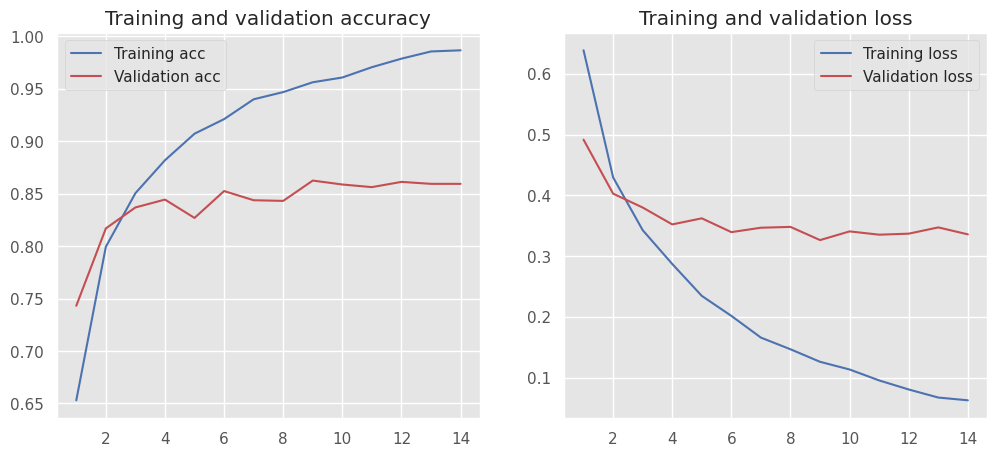

In [94]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - TextCNN
              precision    recall  f1-score   support

    negative       0.84      0.87      0.85      1025
    positive       0.86      0.82      0.84       975

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion matrix, without normalization


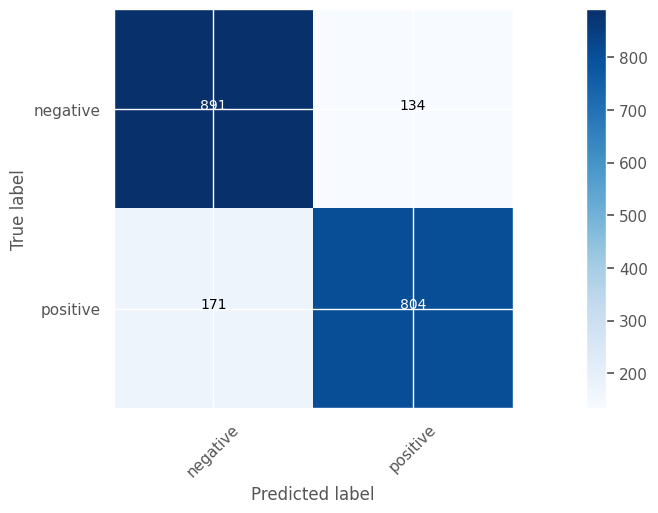


FINAL ACCURACY
0.8475 (84.75%)


In [95]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

La accuray es muy superior a la anterior.
No sé cuánto de sensible el valor es a la inicialización de los pesos.

Pero algo que se puede ver es que el entrenamiento ha sido más largo, la curva de validation loss es más estable que en entrenamientos anteriores y
parece que se **disminuye el overfitting**.

### Entrenamiento ID=19 WE - CNN - MLP: CNN con diferentes tamaño de kernel - Batch con mayor tamaño
Continuamos con este modelo con weight decay.
Como tenemos más memoria disponible en la GPU, aumentamos el tamaño de batch de 32 a 128. Esto hace el entrenamiento más rápido y disminuye el ruido en la estimación del gradiente.

In [96]:
model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=300,
    num_filters=100,
    dropout=0.5
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
TextCNN(
  (embedding): Embedding(41215, 300)
  (convs): ModuleList(
    (0): Conv1d(300, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(300, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         12,364,500      [41215, 300]        
convs.0.weight                           90,000          [100, 300, 3]       
convs.0.bias                             100             [100]               
convs.1.weight                           120,000         [100, 300, 4]       
convs.1.bias                             100             [100]               
convs.2.weight                           150,000         [100, 300

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6725 - acc: 0.6159 - val_loss: 0.5047 - val_acc: 0.7769
Epoch 2/40 - loss: 0.4852 - acc: 0.7647 - val_loss: 0.4570 - val_acc: 0.7837
Epoch 3/40 - loss: 0.3758 - acc: 0.8372 - val_loss: 0.4101 - val_acc: 0.8156
Epoch 4/40 - loss: 0.3152 - acc: 0.8702 - val_loss: 0.3841 - val_acc: 0.8294
Epoch 5/40 - loss: 0.2609 - acc: 0.8984 - val_loss: 0.3630 - val_acc: 0.8344
 (patience: 1/5)
Epoch 6/40 - loss: 0.2247 - acc: 0.9177 - val_loss: 0.3678 - val_acc: 0.8231
Epoch 7/40 - loss: 0.2014 - acc: 0.9231 - val_loss: 0.3547 - val_acc: 0.8344
Epoch 8/40 - loss: 0.1837 - acc: 0.9295 - val_loss: 0.3422 - val_acc: 0.8469
Epoch 9/40 - loss: 0.1567 - acc: 0.9450 - val_loss: 0.3400 - val_acc: 0.8469
 (patience: 1/5)
Epoch 10/40 - loss: 0.1434 - acc: 0.9464 - val_loss: 0.3435 - val_acc: 0.8488
 (patience: 2/5)
Epoch 11/40 - loss: 0.1180 - acc: 0.9614 - val_loss: 0.3532 - val_acc: 0.8425
 (patience: 3/5)
Epoch 12/40 - loss: 0.1132 - acc: 0.9620 - val_loss: 0.3438 - val_acc: 0.8481
Epoch

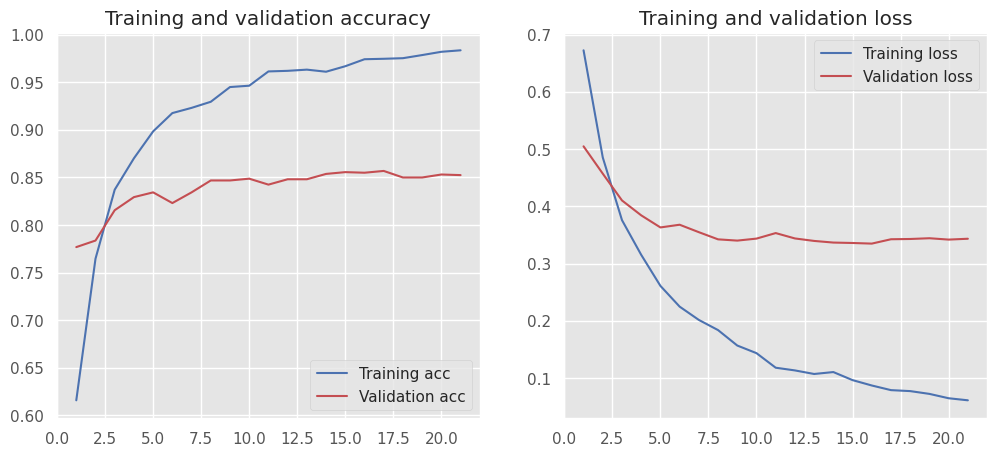

In [97]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=128, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - TextCNN
              precision    recall  f1-score   support

    negative       0.88      0.81      0.84      1025
    positive       0.82      0.88      0.85       975

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion matrix, without normalization


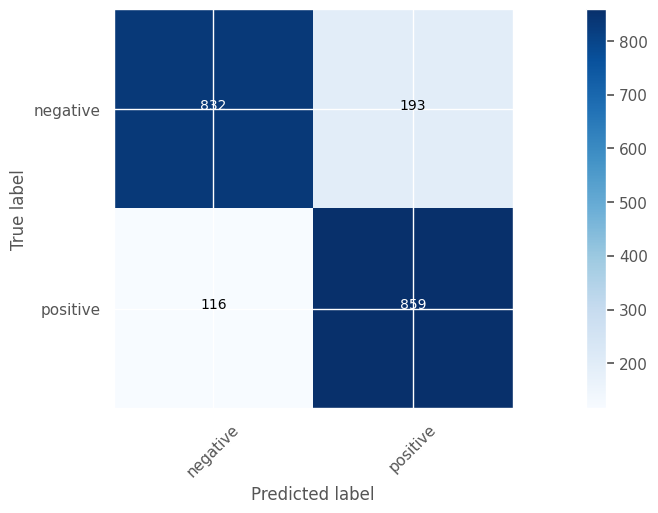


FINAL ACCURACY
0.8455 (84.55%)


In [98]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

Hay un ligero empeoramiento con el tamaño del batch en 128. Algunos artículos muestran que con un batch muy grande aumenta la probabilidad de overfitting.
https://medium.com/@juanc.olamendy/real-world-ml-understanding-batch-size-train-faster-and-better-deep-learning-models-2b24c353e292
- Con batch = 1 tenemos algoritmo de Stochastic Gradient Descent.
- Con batch = Training set tenemos Batch Gradient Descent

Parece que el equilibrio está en **mini-batch** Gradient Descent y hay que tunear el batch generalmente empezando en 32.

### Entrenamiento ID=20 WE - CNN - MLP: CNN con diferentes tamaño de kernel - Aumentar la dimensión de Embeddings

Ahora que hay un entrenamiento relativamente estable. Quiero aumentar la capacidad del modelo para ver si captura mejores representaciones de palabras.
Aumentar la capacidad también aumenta la probabilidad de overfitting y podría funcionar peor. Vamos a ver.

In [99]:
model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=768,
    num_filters=100,
    dropout=0.5
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
TextCNN(
  (embedding): Embedding(41215, 768)
  (convs): ModuleList(
    (0): Conv1d(768, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(768, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(768, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         31,653,120      [41215, 768]        
convs.0.weight                           230,400         [100, 768, 3]       
convs.0.bias                             100             [100]               
convs.1.weight                           307,200         [100, 768, 4]       
convs.1.bias                             100             [100]               
convs.2.weight                           384,000         [100, 768

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6464 - acc: 0.6737 - val_loss: 0.4206 - val_acc: 0.8213
Epoch 2/40 - loss: 0.3995 - acc: 0.8200 - val_loss: 0.3944 - val_acc: 0.8075
Epoch 3/40 - loss: 0.3007 - acc: 0.8703 - val_loss: 0.3628 - val_acc: 0.8462
Epoch 4/40 - loss: 0.2372 - acc: 0.8998 - val_loss: 0.3612 - val_acc: 0.8400
Epoch 5/40 - loss: 0.1785 - acc: 0.9331 - val_loss: 0.3418 - val_acc: 0.8500
Epoch 6/40 - loss: 0.1586 - acc: 0.9381 - val_loss: 0.3417 - val_acc: 0.8431
Epoch 7/40 - loss: 0.1258 - acc: 0.9566 - val_loss: 0.3357 - val_acc: 0.8594
 (patience: 1/5)
Epoch 8/40 - loss: 0.1122 - acc: 0.9631 - val_loss: 0.3521 - val_acc: 0.8394
 (patience: 2/5)
Epoch 9/40 - loss: 0.1003 - acc: 0.9677 - val_loss: 0.3497 - val_acc: 0.8406
Epoch 10/40 - loss: 0.0848 - acc: 0.9728 - val_loss: 0.3326 - val_acc: 0.8569
 (patience: 1/5)
Epoch 11/40 - loss: 0.0766 - acc: 0.9803 - val_loss: 0.3357 - val_acc: 0.8544
 (patience: 2/5)
Epoch 12/40 - loss: 0.0663 - acc: 0.9838 - val_loss: 0.3343 - val_acc: 0.8638
 (pat

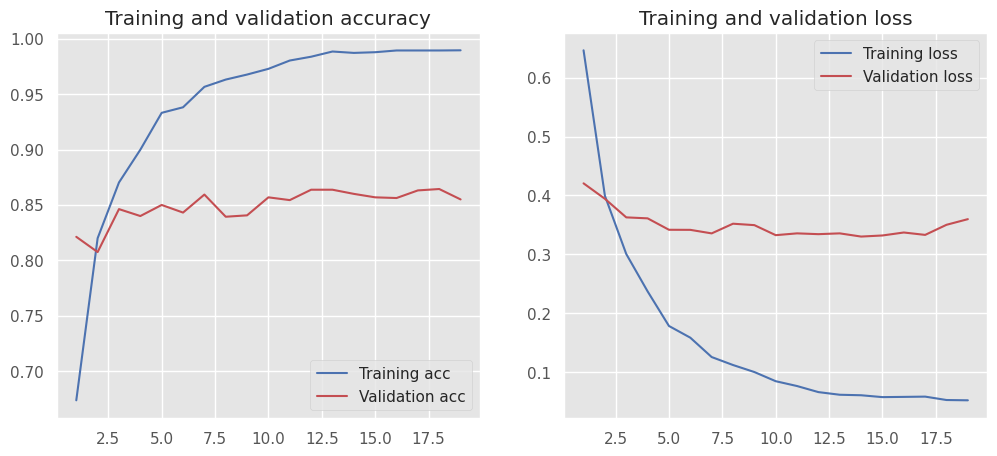

In [100]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - TextCNN
              precision    recall  f1-score   support

    negative       0.85      0.86      0.85      1025
    positive       0.85      0.84      0.84       975

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion matrix, without normalization


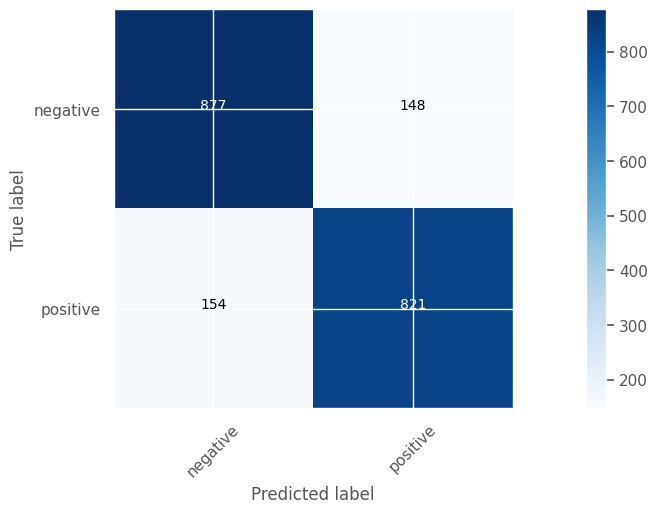


FINAL ACCURACY
0.8490 (84.90%)


In [101]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

La accuracy practicamente no cambia con embedded dim 300 a 768.

### Entrenamiento ID=21 WE - CNN - MLP: CNN con diferentes tamaño de kernel - Batch Normalization
Empleamos otra técnica de regularización que se usa mucho en redes convolucionales profundas.
Antes hemos aumentado la capacidad del modelo, pero no ha resultado en una mejora. Vamos a tratar de ver si se puede reducir aún más el overfitting.

In [102]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, 
                 kernel_sizes=[3, 4, 5], num_filters=100, dropout=0.5):
        super(TextCNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, 
                     out_channels=num_filters, 
                     kernel_size=k)
            for k in kernel_sizes
        ])
        
        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(num_filters)
            for _ in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, 1)
    
    def forward(self, x, verbose=False):
        # [batch_size, seq_len]
        x = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        if verbose:
            print(f"Embedded dim: {x.shape}")
        
        # Permutamos, para cambiar al canal y espacial [batch_size, embedding_dim, seq_len]
        x = x.permute(0, 2, 1)  # [batch_size, embedding_dim, seq_len]
        
        conv_outputs = []
        for idx, (conv, batch_norm) in enumerate(zip(self.convs, self.batch_norms)):
            if verbose:
                print(f"Conv {idx} input shape: {x.shape}")

            conv_out = conv(x)  # [batch_size, num_filters, seq_len - kernel_size + 1]
            conv_out = batch_norm(conv_out)
            conv_out = F.relu(conv_out)

            if verbose:
                print(f"Conv {idx} output shape: {conv_out.shape}")
            pooled = F.max_pool1d(conv_out, conv_out.size(2))  # [batch_size, num_filters, 1]

            if verbose:
                print(f"Pooled output shape: {pooled.shape}")

            conv_outputs.append(pooled.squeeze(2))  # [batch_size, num_filters]
        
        # Concatenate all outputs
        x = torch.cat(conv_outputs, dim=1)  # [batch_size, num_filters * len(kernel_sizes)]
        
        x = self.dropout(x)

        if verbose:
            print(f"FC input shape: {x.shape}")

        x = self.fc(x)  # [batch_size, num_classes]
        
        x = torch.sigmoid(x)

        return x

In [103]:
model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=300,
    num_filters=100,
    dropout=0.5
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
TextCNN(
  (embedding): Embedding(41215, 300)
  (convs): ModuleList(
    (0): Conv1d(300, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(300, 100, kernel_size=(5,), stride=(1,))
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         12,364,500      [41215, 300]        
convs.0.weight                           90,000          [100, 300, 3]       
convs.0.bias                             100             [100]               
convs.1.weight                           120,000         [100, 300, 4]       
convs.1.bias   

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.9868 - acc: 0.5198 - val_loss: 0.6351 - val_acc: 0.6031
Epoch 2/40 - loss: 0.6839 - acc: 0.5934 - val_loss: 0.6161 - val_acc: 0.6750
Epoch 3/40 - loss: 0.6353 - acc: 0.6383 - val_loss: 0.6067 - val_acc: 0.7394
Epoch 4/40 - loss: 0.6346 - acc: 0.6430 - val_loss: 0.5890 - val_acc: 0.7163
Epoch 5/40 - loss: 0.6101 - acc: 0.6670 - val_loss: 0.5790 - val_acc: 0.6919
 (patience: 1/5)
Epoch 6/40 - loss: 0.6186 - acc: 0.6575 - val_loss: 0.5839 - val_acc: 0.7275
Epoch 7/40 - loss: 0.6119 - acc: 0.6637 - val_loss: 0.5759 - val_acc: 0.6944
Epoch 8/40 - loss: 0.5962 - acc: 0.6802 - val_loss: 0.5749 - val_acc: 0.6925
 (patience: 1/5)
Epoch 9/40 - loss: 0.5962 - acc: 0.6811 - val_loss: 0.5813 - val_acc: 0.7388
Epoch 10/40 - loss: 0.5785 - acc: 0.6978 - val_loss: 0.5541 - val_acc: 0.7406
Epoch 11/40 - loss: 0.5600 - acc: 0.7148 - val_loss: 0.5397 - val_acc: 0.7338
 (patience: 1/5)
Epoch 12/40 - loss: 0.5554 - acc: 0.7212 - val_loss: 0.5404 - val_acc: 0.7362
Epoch 13/40 - loss: 0.

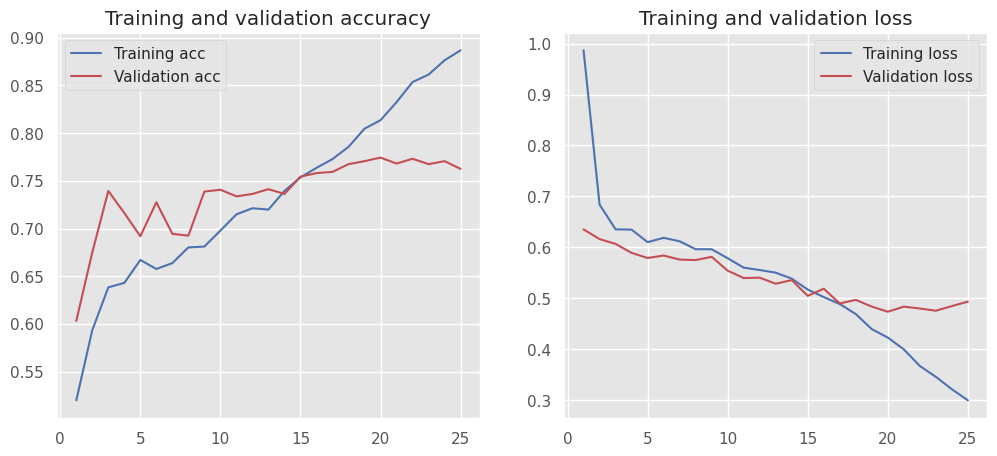

In [104]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - TextCNN
              precision    recall  f1-score   support

    negative       0.82      0.75      0.78      1025
    positive       0.76      0.82      0.79       975

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000

Confusion matrix, without normalization


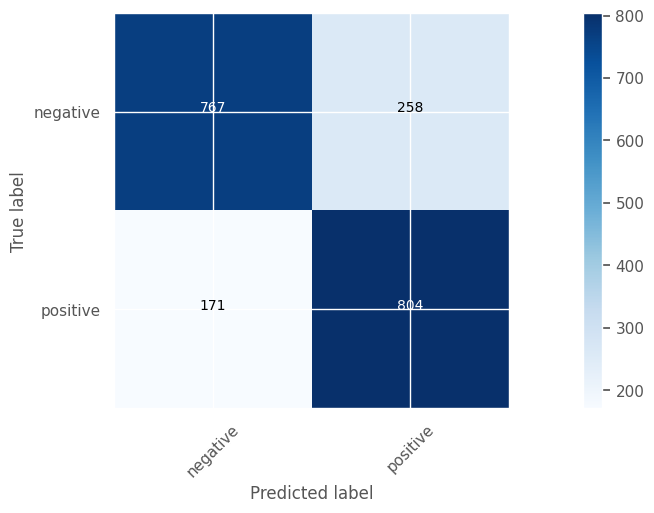


FINAL ACCURACY
0.7855 (78.55%)


In [105]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

Este entrenamiento ha sido más lento (se han usado más epochs) y el resultado es peor. Voy a aumentar un poco el learning rate. Con toda la regularización que hay, quizá se pueda hacer.

### Entrenamiento ID=22 WE - CNN - MLP: CNN con diferentes tamaño de kernel - Aumento de Learning Rate


In [106]:
model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=300,
    num_filters=100,
    dropout=0.5
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
TextCNN(
  (embedding): Embedding(41215, 300)
  (convs): ModuleList(
    (0): Conv1d(300, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(300, 100, kernel_size=(5,), stride=(1,))
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         12,364,500      [41215, 300]        
convs.0.weight                           90,000          [100, 300, 3]       
convs.0.bias                             100             [100]               
convs.1.weight                           120,000         [100, 300, 4]       
convs.1.bias   

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.9117 - acc: 0.5153 - val_loss: 0.6928 - val_acc: 0.4963
Epoch 2/40 - loss: 0.7241 - acc: 0.5277 - val_loss: 0.6867 - val_acc: 0.5212
Epoch 3/40 - loss: 0.7228 - acc: 0.5328 - val_loss: 0.6568 - val_acc: 0.6538
Epoch 4/40 - loss: 0.6796 - acc: 0.6061 - val_loss: 0.5688 - val_acc: 0.7381
Epoch 5/40 - loss: 0.5978 - acc: 0.6970 - val_loss: 0.5287 - val_acc: 0.7381
Epoch 6/40 - loss: 0.5519 - acc: 0.7269 - val_loss: 0.5164 - val_acc: 0.7519
Epoch 7/40 - loss: 0.5450 - acc: 0.7336 - val_loss: 0.5075 - val_acc: 0.7575
Epoch 8/40 - loss: 0.5096 - acc: 0.7598 - val_loss: 0.4787 - val_acc: 0.7794
 (patience: 1/5)
Epoch 9/40 - loss: 0.4801 - acc: 0.7783 - val_loss: 0.4980 - val_acc: 0.7556
Epoch 10/40 - loss: 0.4575 - acc: 0.7914 - val_loss: 0.4494 - val_acc: 0.7825
Epoch 11/40 - loss: 0.4208 - acc: 0.8152 - val_loss: 0.4466 - val_acc: 0.7925
Epoch 12/40 - loss: 0.3653 - acc: 0.8438 - val_loss: 0.3928 - val_acc: 0.8250
Epoch 13/40 - loss: 0.3289 - acc: 0.8586 - val_loss: 0.3

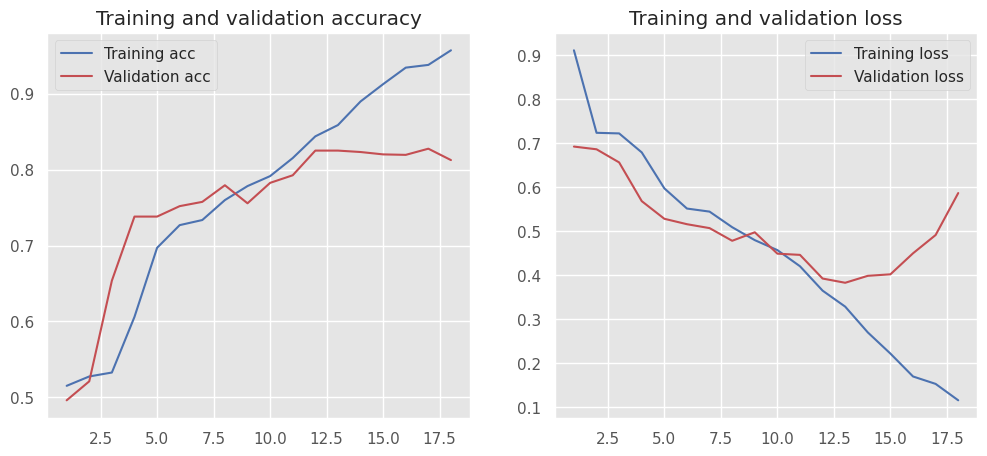

In [107]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - TextCNN
              precision    recall  f1-score   support

    negative       0.84      0.81      0.82      1025
    positive       0.81      0.84      0.82       975

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

Confusion matrix, without normalization


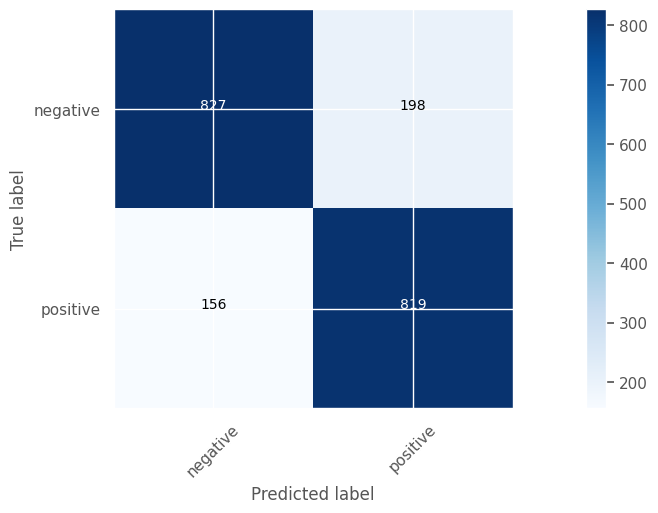


FINAL ACCURACY
0.8230 (82.30%)


In [108]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

Ha mejorado un poco con respecto al entrenamiento anterior.

### Resumen de Word Embeddings + CNN + MLP

Se ha demostrado que Word Embeddings es una representación mucho más apropiada que la representación TF-IDF para las capas convolucionales.

En WE las convoluciones pueden extraer patrones locales dado que la entrada son secuencias ordenadas de representaciones de cada token en un espacio
denso de embedding. Buscar en la literatura alguna arquitectura conocida de CNN's para procesar texto ha dado con una idea que ha aumentado un poco el rendimiento del modelo
en estos datos: Usar convoluciones en paralelo con diferentes tamaños de kernel.

Resultados:
- ID=11 Accuracy=86.95% WE + MLP
- ID=12 Accuracy=80.90% WE + CNN + MLP; kernel size=7
- ID=13 Accuracy=80.35% WE + CNN + MLP; kernel_size=3
- ID=14 Accuracy=81.15% WE + CNN + MLP; kernel_size=3 dropout=0.3
- ID=15 Accuracy=81.35% WE + CNN + MLP; kernel_size=3 dropout=0.5
- ID=16 Accuracy=81.15% WE + CNN + MLP; kernel_size=3 dropout=0.3 cosine_lr_scheduler
- ID=17 Accuracy=83.70% WE + CNN + MLP; Diferentes tamaños de kernel
- ID=18 Accuracy=84.75% WE + CNN + MLP; Diferentes tamaños de kernel weight_decay=1e-4
- ID=19 Accuracy=84.55% WE + CNN + MLP; Diferentes tamaños de kernel batch_size=128 weight_decay
- ID=20 Accuracy=84.90% WE + CNN + MLP; Diferentes tamaños de kernel mayor embedded dim
- ID=21 Accuracy=78.55% WE + CNN + MLP; Diferentes tamaños de kernel batch normalization
- ID=22 Accuracy=82.30% WE + CNN + MLP; Diferentes tamaños de kernel batch normalization mayor lr

Algunas conclusiones:
- **Dropout** ha ayudado a hacer que el modelo generalize mejor.
- El siguiente salto se ha dado usando CNNs con **diferentes tamaños de kernel**.
- Y el último salto ha sido añador **weight_decay** al optimizador Adam.

Batch Normalization no ha funcionado en estos experimentos. Quizá es más útil para estabilizar entrenamientos de modelos con muchas capas CNN en serie (más profundidad).

# Introspección de las activaciones

A continuación vamos a visualizar las activaciones de las convoluciones como manera de dar cierta explicabilidad al modelo.

Para esto, vamos a usar un modelo basado en:
- Word embeddings
- 1 convolución
- Pooling pequeño
- MLP

Como orienta el enunciado de la tarea vamos a visualizar las activaciones en una red convolucional pequeña con una sola
capa de convolución y otra de pooling pequeño.
Vamos a comenzar sin dropout en el modelo. Después veremos qué pasa cuando se introduce Dropout.

In [109]:
class BinaryClassificationTextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, num_filters=25, 
                 filter_size=3, pool_size=3, padding=1, stride=1, dropout=0):
        super(BinaryClassificationTextCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.conv = nn.Conv1d(
            in_channels=embedding_dim,
            out_channels=num_filters,
            kernel_size=filter_size,
            padding=padding,
            stride=stride
        )

        self.pool = nn.MaxPool1d(kernel_size=pool_size)

        self.dropout = nn.Dropout(dropout)

        self.fc = None
        self.output_dim = 1
        self.num_filters = num_filters
        
    def forward(self, text, verbose=False):
        # text: [batch_size, seq_len]

        embedded = self.embedding(text)  # [batch_size, seq_len, embedding_dim]

        if verbose:
            print(f"Embedded dim: {embedded.shape}")

        # Transponer para Conv1d: [batch_size, embedding_dim, seq_len]
        embedded = embedded.permute(0, 2, 1)

        if verbose:
            print(f"Embedded dim transposed: {embedded.shape}")

        x = F.relu(self.conv(embedded))  # [batch_size, num_filters, seq_len]

        if verbose:
            print(f"First convolution shape: {x.shape}")

        # Pooling
        pooled = self.pool(x)  # [batch_size, num_filters, seq_len/pool_size]

        if verbose:
            print(f"Pooled shape: {pooled.shape}")

        # Flatten
        flattened = pooled.view(pooled.size(0), -1)  # [batch_size, num_filters * pooled_len]
        flattened = self.dropout(flattened)

        if verbose:
            print(f"Flattened shape: {flattened.shape}")

        # Fully connected (inicializar si es necesario)
        if self.fc is None:
            self.fc = nn.Linear(flattened.size(1), self.output_dim).to(text.device)

        output_logits = self.fc(flattened)

        output = torch.sigmoid(output_logits)

        return output

## Experimento 1: K=3, S=1, P=1. No dropout

In [110]:
model = BinaryClassificationTextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    num_filters=30,
    filter_size=3,
    pool_size=3,
    padding=1  # Para K=3, S=1, P=1 mantiene el tamaño
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
BinaryClassificationTextCNN(
  (embedding): Embedding(41215, 64, padding_idx=0)
  (conv): Conv1d(64, 30, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,637,760       [41215, 64]         
conv.weight                              5,760           [30, 64, 3]         
conv.bias                                30              [30]                
--------------------------------------------------------------------------------
Total Parameters:                        2,643,550
Trainable Parameters:                    2,643,550
Non-trainable Parameters:                0
Model Size:                              10.08 MB
Embedded dim: to

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6985 - acc: 0.5466 - val_loss: 0.6399 - val_acc: 0.6531
Epoch 2/40 - loss: 0.4855 - acc: 0.7769 - val_loss: 0.4839 - val_acc: 0.7875
Epoch 3/40 - loss: 0.2761 - acc: 0.8903 - val_loss: 0.4459 - val_acc: 0.8181
 (patience: 1/5)
Epoch 4/40 - loss: 0.1532 - acc: 0.9520 - val_loss: 0.4703 - val_acc: 0.8144
 (patience: 2/5)
Epoch 5/40 - loss: 0.0808 - acc: 0.9812 - val_loss: 0.4639 - val_acc: 0.8187
 (patience: 3/5)
Epoch 6/40 - loss: 0.0415 - acc: 0.9928 - val_loss: 0.5043 - val_acc: 0.8200
 (patience: 4/5)
Epoch 7/40 - loss: 0.0211 - acc: 0.9981 - val_loss: 0.5303 - val_acc: 0.8200
 (patience: 5/5)
Early stopping triggered at epoch 8


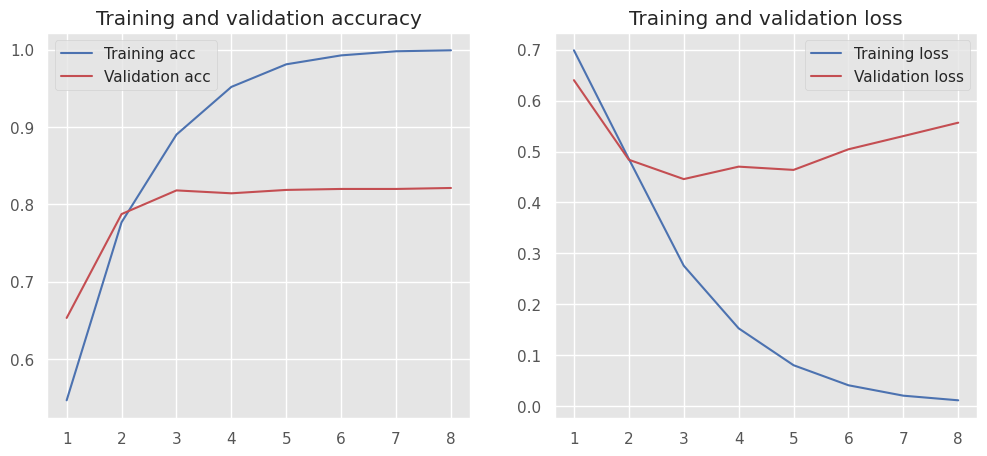

In [111]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassificationTextCNN
              precision    recall  f1-score   support

    negative       0.83      0.81      0.82      1025
    positive       0.81      0.83      0.82       975

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

Confusion matrix, without normalization


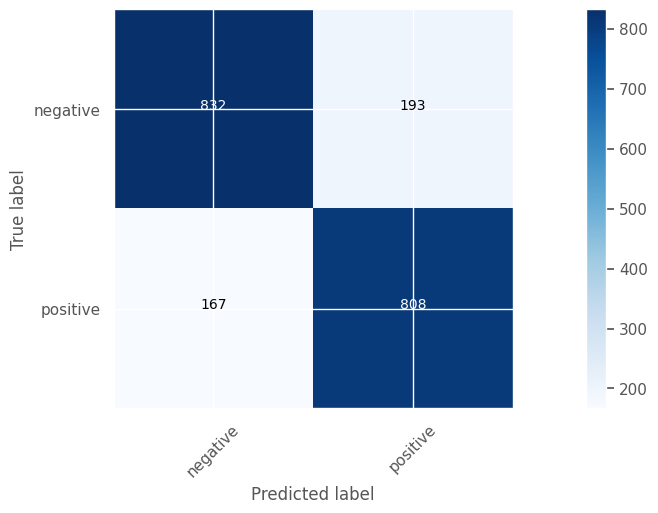


FINAL ACCURACY
0.8200 (82.00%)


In [112]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

El siguiente método crea los gráficos donde se muestran las activaciones.
En los gráficos, el eje Y es el valor float de cada activación y el eje X muestra el n-grama de entrada al filtro
como texto (la entrada al filtro es una ventana con valores numérica).

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_filter_activations_over_text(model, text, tokenizer, tokens_per_subplot=20):
    model.eval()
    device = next(model.parameters()).device

    # Con esto se obtiene el tamaño del kernel
    kernel_size = model.conv.kernel_size[0]
    # También necesitamos saber el stride
    stride = model.conv.stride[0]

    # Se tokeniza el texto de entrada (que viene en raw string)
    encoded = tokenizer.encode_batch([text])
    tokens = np.array(encoded)

    tokens_ids = encoded[0].ids
    tokens = np.array(tokens_ids)

    # Convertir a tensor y mover a device
    # Este tensor ya es compatible con el modelo entrenado
    text_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)  # [B=1, seq_len]

    # Obtener activaciones y predicción
    with torch.no_grad():
        # Accedemos a cada capa del modelo
        # Se puede hacer esto, o un método forward que devuelva todos
        # los tensores de los que estamos interesados
        embedded = model.embedding(text_tensor)
        embedded = embedded.permute(0, 2, 1)
        conved = torch.relu(model.conv(embedded))

        # Nos vamos a quedar con las activaciones de la capa convolucional
        # Eliminando la dimensión del batch.
        activations = conved.squeeze().cpu().numpy()
        prediction = model(text_tensor, verbose=True)

    # Decodificar los tokens
    valid_tokens = tokens[tokens != 0]
    token_texts = []
    for token in valid_tokens:
        # De token id a la "palabra"
        token_text = tokenizer.decode([int(token)])
        token_texts.append(token_text.strip() if token_text.strip() else '<UNK>')

    print(f"Original text: {text}")
    print(f"Prediction (0 negative, 1 positive): {prediction.item():.4f}")
    print(f"Decoded tokens: {token_texts}")

    # Crear n-gramas del tamaño del kernel
    # Y los guardamos en una lista
    ngrams = []
    ngram_positions = []
    # Tenemos en cuenta no solo el tamaño del kernel, sino también el stride
    for i in range(0, len(token_texts) - kernel_size + 1, stride):
        ngram = ' '.join(token_texts[i:i + kernel_size])
        ngrams.append(ngram)
        ngram_positions.append(i)

    activations = activations[:, :len(ngrams)]
    num_filters = activations.shape[0]
    num_ngrams = len(ngrams)

    # Para que la escala sea la misma, calculamos el max y min
    global_min = activations.min()
    global_max = activations.max()

    # Colores para cada filtro
    colors = plt.cm.rainbow(np.linspace(0, 1, num_filters))

    num_subplots = int(np.ceil(num_ngrams / tokens_per_subplot))
    fig, axes = plt.subplots(num_subplots, 1, 
                             figsize=(20, 6 * num_subplots),
                             sharex=False, sharey=False)

    if num_subplots == 1:
        axes = [axes]

    fig.suptitle(f'Activaciones de Filtros CNN a lo Largo del Texto ({kernel_size}-gramas)', fontsize=16)

    # Dividir y graficar cada segmento
    # Crear subplots para partir una frase que sea larga
    for subplot_idx in range(num_subplots):
        ax = axes[subplot_idx]
        # Calcular rango de n-gramas para este subplot
        start_idx = subplot_idx * tokens_per_subplot
        end_idx = min((subplot_idx + 1) * tokens_per_subplot, num_ngrams)

        # Extraer segmento
        segment_ngrams = ngrams[start_idx:end_idx]
        segment_activations = activations[:, start_idx:end_idx]

        # Posiciones x locales para este subplot
        x_positions = np.arange(len(segment_ngrams))

        # Graficar cada filtro
        for filter_idx in range(num_filters):
            # En la x los ngramas y en la y el valor de la activación
            ax.plot(x_positions, segment_activations[filter_idx], 
                   color=colors[filter_idx], 
                   linewidth=2, 
                   alpha=0.7,
                   marker='o',
                   markersize=5,
                   label=f'Filtro {filter_idx+1}' if subplot_idx == 0 else '')

        ax.set_ylim([global_min - 0.1 * (global_max - global_min), 
                     global_max + 0.1 * (global_max - global_min)])

        ax.set_ylabel('Nivel de Activación (Raw)', fontsize=12)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(segment_ngrams, rotation=45, ha='right', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.grid(True, alpha=0.2, axis='x', linestyle=':')

        segment_min = segment_activations.min()
        segment_max = segment_activations.max()
        ax.text(0.02, 0.95, 
               f'{kernel_size}-gramas {start_idx+1}-{end_idx}\nRango: [{segment_min:.3f}, {segment_max:.3f}]', 
               transform=ax.transAxes, fontsize=10, 
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               verticalalignment='top')

        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize=8)

    axes[-1].set_xlabel(f'Texto de Entrada ({kernel_size}-gramas)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.97)
    plt.show()

    # Imprimir información
    full_text = tokenizer.decode(valid_tokens.tolist())
    print("\nTexto analizado:")
    print(f"{full_text}\n")
    print("Estadísticas:")
    print(f"Longitud del texto: {len(token_texts)} tokens")
    print(f"Tamaño del kernel: {kernel_size}")
    print(f"Número de {kernel_size}-gramas: {num_ngrams}")
    print(f"Número de filtros: {num_filters}")
    print(f"Número de subplots: {num_subplots}")
    print(f"{kernel_size}-gramas por subplot: {tokens_per_subplot}")
    print("\nValores de activación:")
    print(f"Mínimo global: {global_min:.4f}")
    print(f"Máximo global: {global_max:.4f}")
    print(f"Media global: {activations.mean():.4f}")
    print(f"Desviación estándar: {activations.std():.4f}")

Embedded dim: torch.Size([1, 2000, 64])
Embedded dim transposed: torch.Size([1, 64, 2000])
First convolution shape: torch.Size([1, 30, 2000])
Pooled shape: torch.Size([1, 30, 666])
Flattened shape: torch.Size([1, 19980])
Original text: bad film meaningless moment dull scene although actor not horrendous
Prediction (0 negative, 1 positive): 0.0458
Decoded tokens: ['bad', 'film', 'meaningless', 'moment', 'dull', 'scene', 'although', 'actor', 'not', 'horrendous']


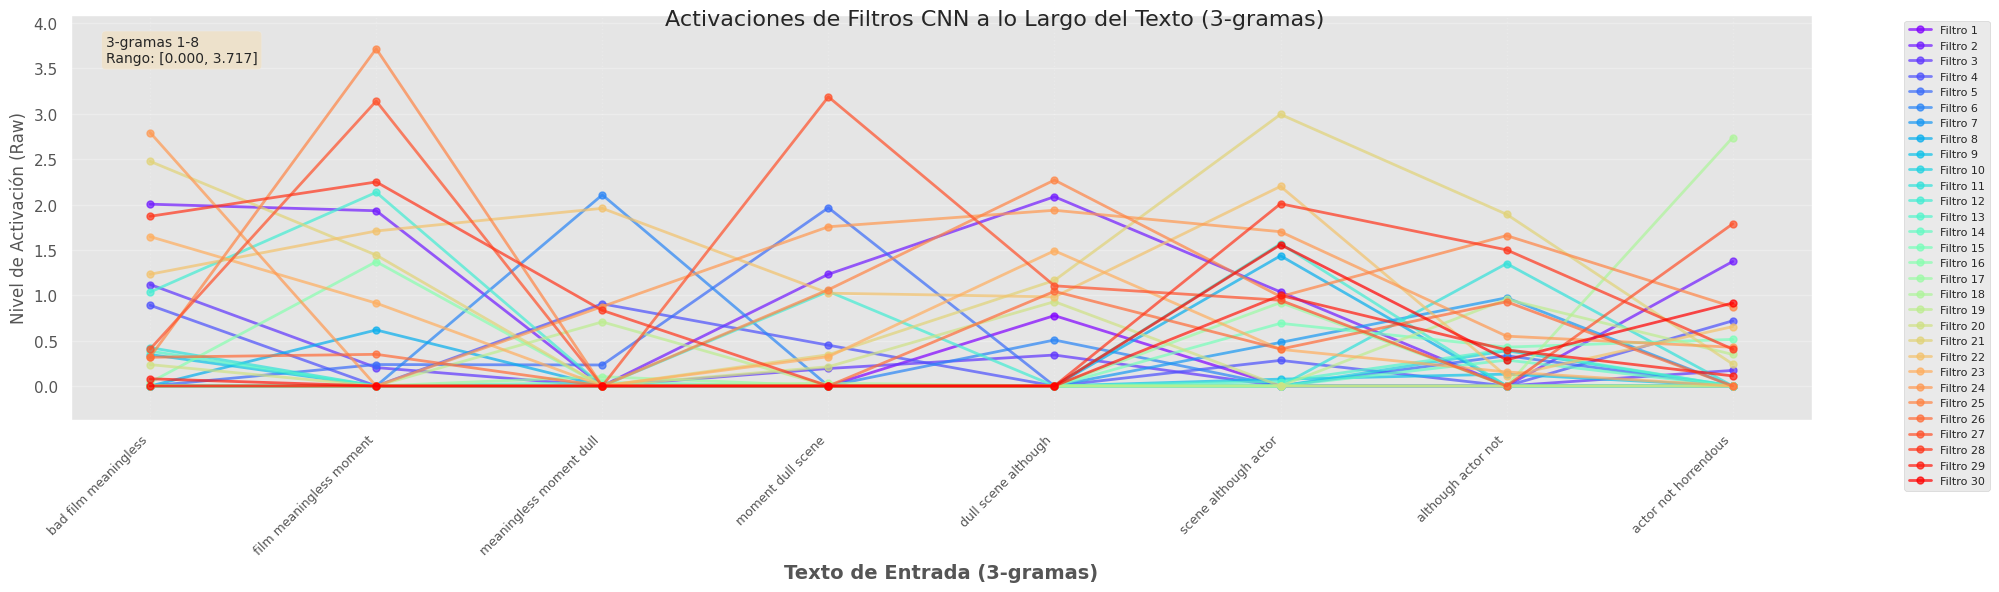


Texto analizado:
bad film meaningless moment dull scene although actor not horrendous

Estadísticas:
Longitud del texto: 10 tokens
Tamaño del kernel: 3
Número de 3-gramas: 8
Número de filtros: 30
Número de subplots: 1
3-gramas por subplot: 20

Valores de activación:
Mínimo global: 0.0000
Máximo global: 3.7167
Media global: 0.4898
Desviación estándar: 0.7548


In [114]:
text = "This is a very bad film with meaningless moments and dull scenes, although the actors are not horrendous."
processed_text = process_text(text, keep_numbers=True)
visualize_filter_activations_over_text(model, processed_text, tokenizer)

El filtro número 26 (un tono de naranja) parece activarse mayormente con "moment dull scene". Vamos a probar si este se activa en otra frase que contenga este trigrama.

Embedded dim: torch.Size([1, 2000, 64])
Embedded dim transposed: torch.Size([1, 64, 2000])
First convolution shape: torch.Size([1, 30, 2000])
Pooled shape: torch.Size([1, 30, 666])
Flattened shape: torch.Size([1, 19980])
Original text: movie boring moment dull scene made hard enjoy despite decent cinematography
Prediction (0 negative, 1 positive): 0.0045
Decoded tokens: ['movie', 'boring', 'moment', 'dull', 'scene', 'made', 'hard', 'enjoy', 'despite', 'decent', 'cinematography']


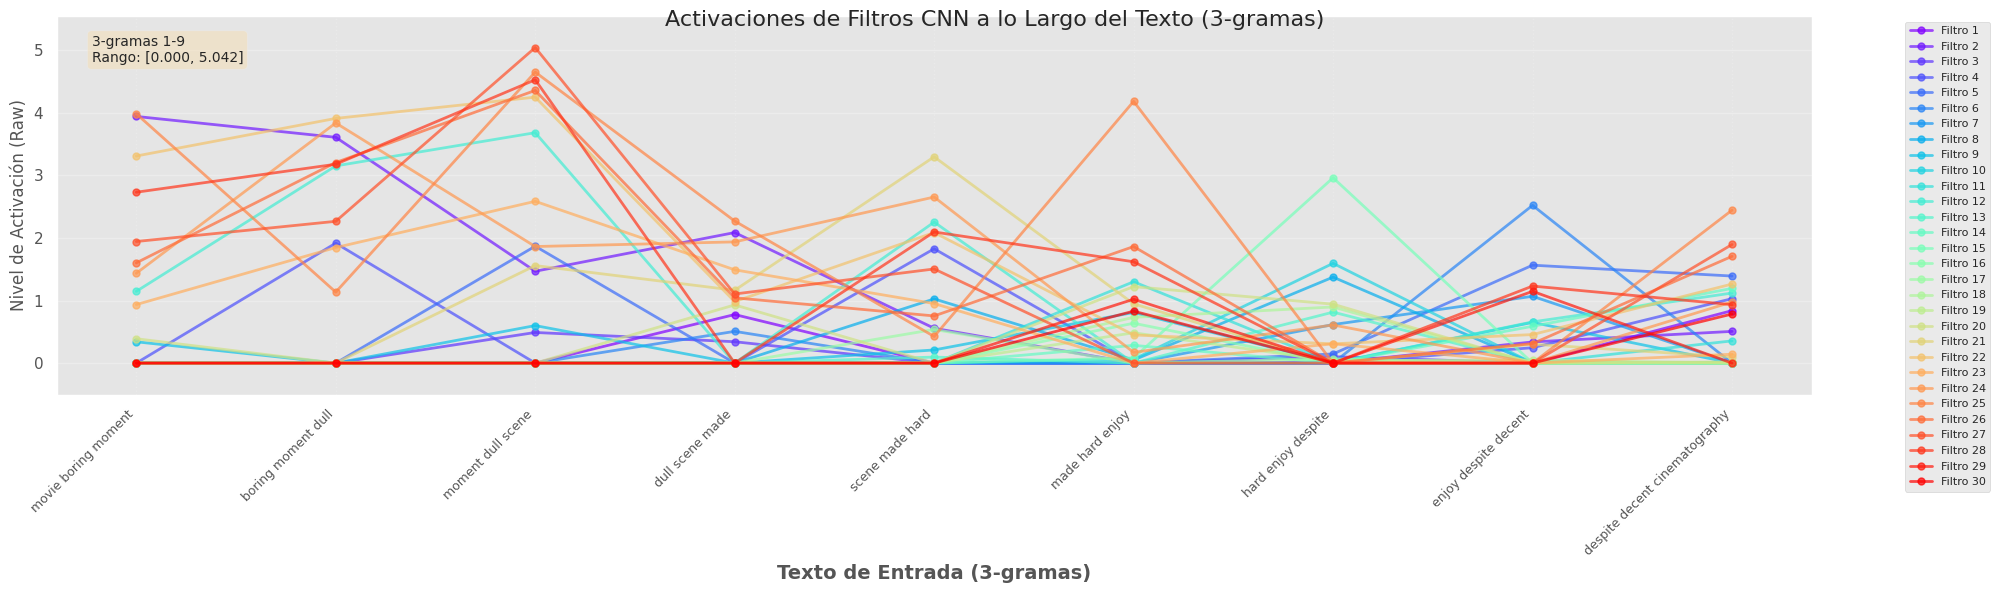


Texto analizado:
movie boring moment dull scene made hard enjoy despite decent cinematography

Estadísticas:
Longitud del texto: 11 tokens
Tamaño del kernel: 3
Número de 3-gramas: 9
Número de filtros: 30
Número de subplots: 1
3-gramas por subplot: 20

Valores de activación:
Mínimo global: 0.0000
Máximo global: 5.0421
Media global: 0.6554
Desviación estándar: 1.0835


In [115]:
text = "The movie had some boring moments and dull scenes that made it hard to enjoy, despite having decent cinematography."
processed_text = process_text(text, keep_numbers=True)
visualize_filter_activations_over_text(model, processed_text, tokenizer)

En esta frase el filtro con id=26 (tono de naranja) también se ha activado al ver el mismo trigrama "moment dull scene" en una frase distinta.
De todas formas, es posible que con 

## Experimento 2: K=5, S=1, P=2. No dropout
Probaremos ahora a visualizar activaciones de filtros con un tamaño del kernel = 5. Para ello, hay que entrenar un modelo nuevo.

In [131]:
model = BinaryClassificationTextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    num_filters=30,
    filter_size=5,
    pool_size=5,
    padding=2  # Mantiene dimensión
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
BinaryClassificationTextCNN(
  (embedding): Embedding(41215, 64, padding_idx=0)
  (conv): Conv1d(64, 30, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,637,760       [41215, 64]         
conv.weight                              9,600           [30, 64, 5]         
conv.bias                                30              [30]                
--------------------------------------------------------------------------------
Total Parameters:                        2,647,390
Trainable Parameters:                    2,647,390
Non-trainable Parameters:                0
Model Size:                              10.10 MB
Embedded dim: to

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64
Epoch 1/40 - loss: 0.6921 - acc: 0.5416 - val_loss: 0.6579 - val_acc: 0.5863
Epoch 2/40 - loss: 0.4977 - acc: 0.7709 - val_loss: 0.4684 - val_acc: 0.7919
Epoch 3/40 - loss: 0.2812 - acc: 0.8905 - val_loss: 0.4519 - val_acc: 0.8025
Epoch 4/40 - loss: 0.1513 - acc: 0.9503 - val_loss: 0.4479 - val_acc: 0.8187
 (patience: 1/5)
Epoch 5/40 - loss: 0.0745 - acc: 0.9830 - val_loss: 0.4764 - val_acc: 0.8275
 (patience: 2/5)
Epoch 6/40 - loss: 0.0355 - acc: 0.9955 - val_loss: 0.5079 - val_acc: 0.8306
 (patience: 3/5)
Epoch 7/40 - loss: 0.0181 - acc: 0.9988 - val_loss: 0.5481 - val_acc: 0.8331
 (patience: 4/5)
Epoch 8/40 - loss: 0.0101 - acc: 0.9992 - val_loss: 0.5821 - val_acc: 0.8275
 (patience: 5/5)
Early stopping triggered at epoch 9


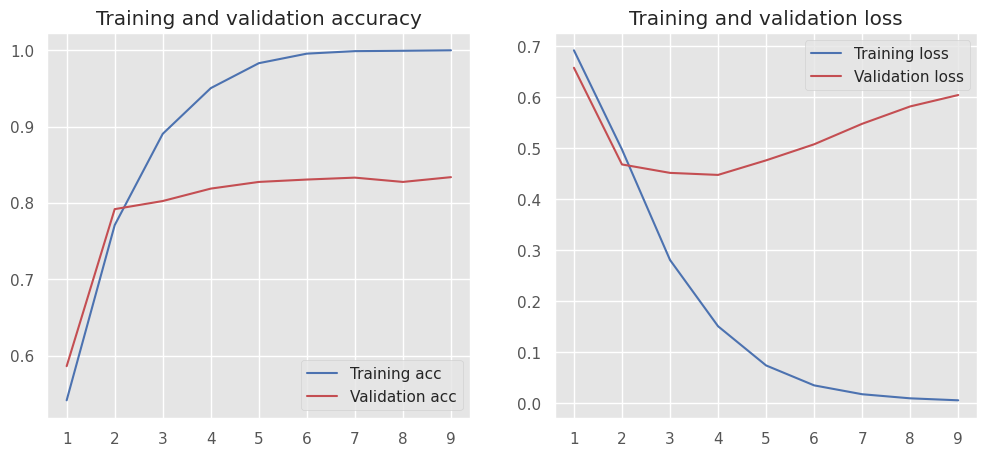

In [132]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassificationTextCNN
              precision    recall  f1-score   support

    negative       0.81      0.82      0.81      1025
    positive       0.81      0.79      0.80       975

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

Confusion matrix, without normalization


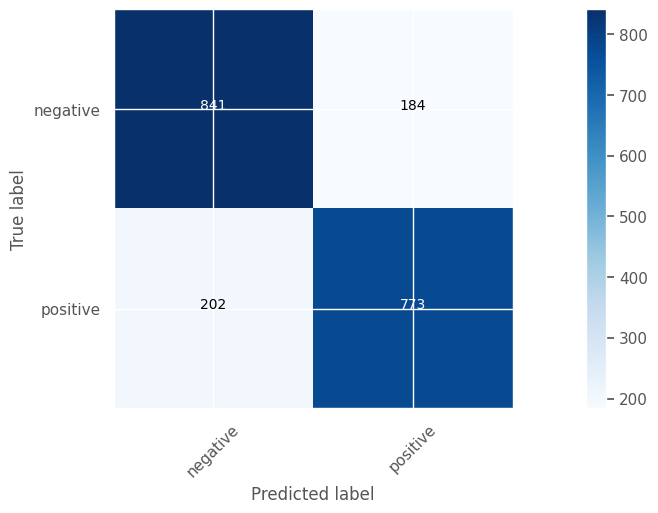


FINAL ACCURACY
0.8070 (80.70%)


In [133]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

Embedded dim: torch.Size([1, 2000, 64])
Embedded dim transposed: torch.Size([1, 64, 2000])
First convolution shape: torch.Size([1, 30, 2000])
Pooled shape: torch.Size([1, 30, 400])
Flattened shape: torch.Size([1, 12000])
Original text: good film meaningful moment engaging scene actor absolutely brilliant
Prediction (0 negative, 1 positive): 0.8204
Decoded tokens: ['good', 'film', 'meaningful', 'moment', 'engaging', 'scene', 'actor', 'absolutely', 'brilliant']


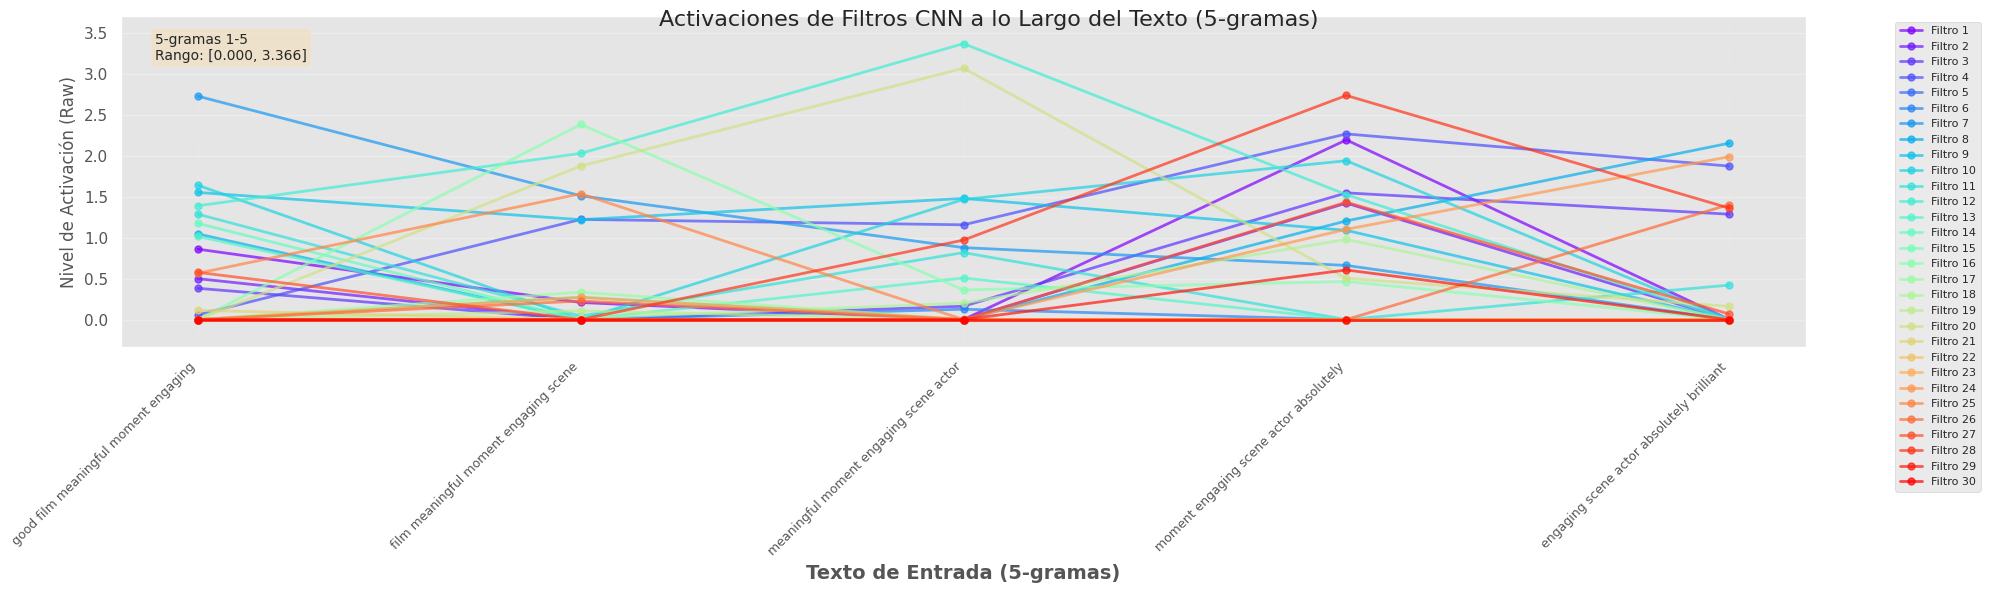


Texto analizado:
good film meaningful moment engaging scene actor absolutely brilliant

Estadísticas:
Longitud del texto: 9 tokens
Tamaño del kernel: 5
Número de 5-gramas: 5
Número de filtros: 30
Número de subplots: 1
5-gramas por subplot: 20

Valores de activación:
Mínimo global: 0.0000
Máximo global: 3.3661
Media global: 0.5002
Desviación estándar: 0.7665


In [134]:
text = "This is a very good film with meaningful moments and engaging scenes, and the actors are absolutely brilliant."
processed_text = process_text(text, keep_numbers=True)
visualize_filter_activations_over_text(model, processed_text, tokenizer)

En esta prueba, el filtro turquesa 12 (casi 3.5) parece ser uno de los que más se activa. Con el 5-grama "meaningful moment engaging scene actor".

Embedded dim: torch.Size([1, 2000, 64])
Embedded dim transposed: torch.Size([1, 64, 2000])
First convolution shape: torch.Size([1, 30, 2000])
Pooled shape: torch.Size([1, 30, 400])
Flattened shape: torch.Size([1, 12000])
Original text: truly impressed outstanding film delivers meaningful moment engaging scene also showcasing exceptional performance kept captivated throughout
Prediction (0 negative, 1 positive): 0.9870
Decoded tokens: ['truly', 'impressed', 'outstanding', 'film', 'delivers', 'meaningful', 'moment', 'engaging', 'scene', 'also', 'showcasing', 'exceptional', 'performance', 'kept', 'captivated', 'throughout']


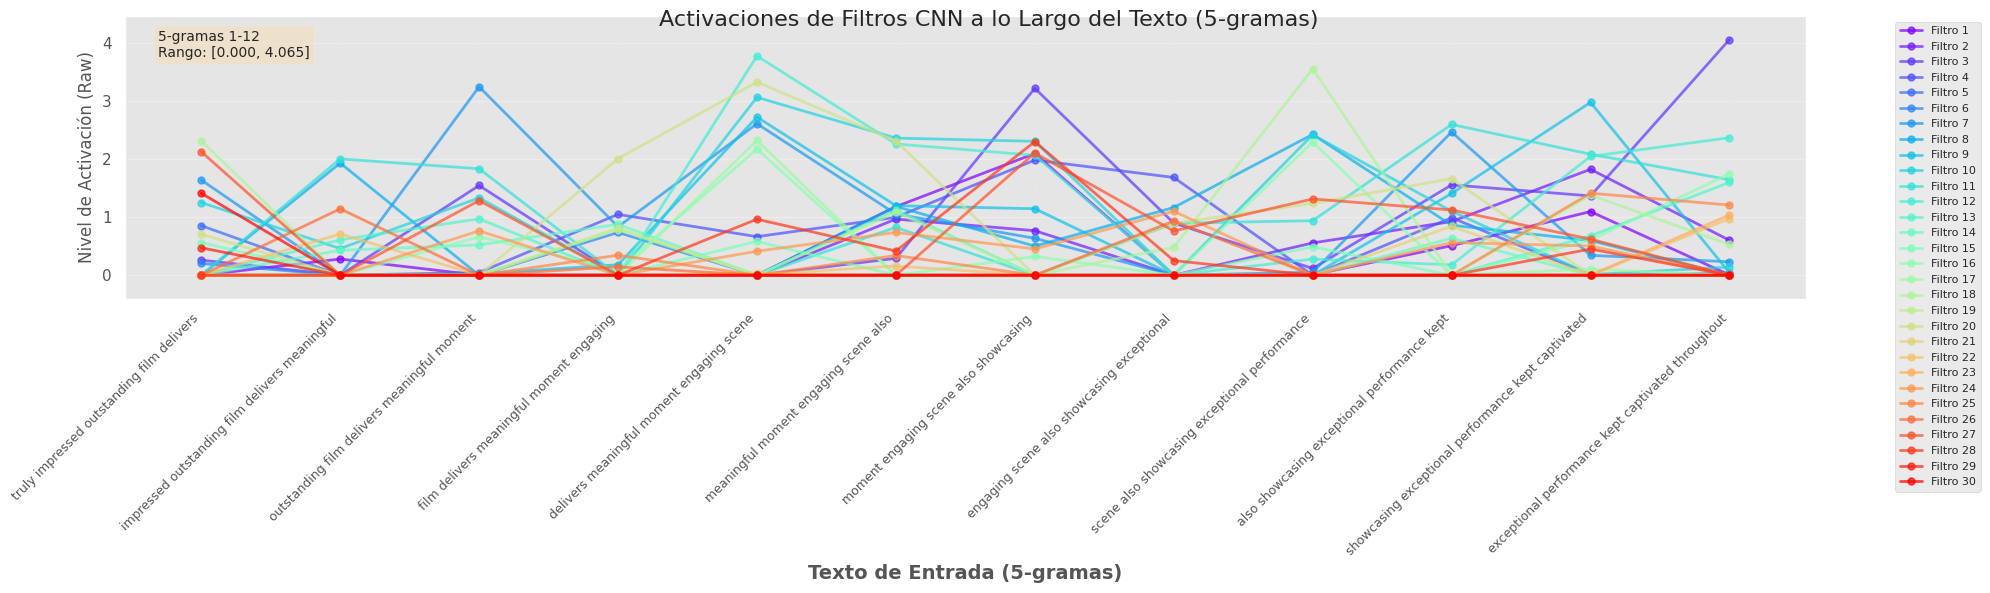


Texto analizado:
truly impressed outstanding film delivers meaningful moment engaging scene also showcasing exceptional performance kept captivated throughout

Estadísticas:
Longitud del texto: 16 tokens
Tamaño del kernel: 5
Número de 5-gramas: 12
Número de filtros: 30
Número de subplots: 1
5-gramas por subplot: 20

Valores de activación:
Mínimo global: 0.0000
Máximo global: 4.0645
Media global: 0.4927
Desviación estándar: 0.8114


In [135]:
text = "I was truly impressed by this outstanding film because it delivers meaningful moments and engaging scenes while also showcasing exceptional performances that kept me captivated throughout."
processed_text = process_text(text, keep_numbers=True)
visualize_filter_activations_over_text(model, processed_text, tokenizer)

En esta otra prueba, el filtro turquesa id=12 también se activa con un 5-grama similar. En este caso con: "delivers meaningful moment engaging scene"

## Experimento 3: K=3, S=3, P=2. No dropout
Vamos a probar con K=3, P=1, Stride=3. Ahora en los n-gramas no debería haber solapamiento.

In [121]:
model = BinaryClassificationTextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=256,
    num_filters=20,
    filter_size=3,
    pool_size=3,
    stride=3, # Saltar 3 posiciones
    padding=1,  # Para K=3, S=1, P=1 mantiene el tamaño
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
BinaryClassificationTextCNN(
  (embedding): Embedding(41215, 256, padding_idx=0)
  (conv): Conv1d(256, 20, kernel_size=(3,), stride=(3,), padding=(1,))
  (pool): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         10,551,040      [41215, 256]        
conv.weight                              15,360          [20, 256, 3]        
conv.bias                                20              [20]                
--------------------------------------------------------------------------------
Total Parameters:                        10,566,420
Trainable Parameters:                    10,566,420
Non-trainable Parameters:                0
Model Size:                              40.31 MB
Embedded dim

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64


Epoch 1/40 - loss: 0.6626 - acc: 0.5941 - val_loss: 0.5614 - val_acc: 0.7400
Epoch 2/40 - loss: 0.4034 - acc: 0.8319 - val_loss: 0.4477 - val_acc: 0.8056
Epoch 3/40 - loss: 0.1923 - acc: 0.9400 - val_loss: 0.4245 - val_acc: 0.8213
 (patience: 1/5)
Epoch 4/40 - loss: 0.0780 - acc: 0.9852 - val_loss: 0.4442 - val_acc: 0.8237
 (patience: 2/5)
Epoch 5/40 - loss: 0.0325 - acc: 0.9972 - val_loss: 0.4787 - val_acc: 0.8269
 (patience: 3/5)
Epoch 6/40 - loss: 0.0168 - acc: 0.9995 - val_loss: 0.5067 - val_acc: 0.8244
 (patience: 4/5)
Epoch 7/40 - loss: 0.0108 - acc: 1.0000 - val_loss: 0.5266 - val_acc: 0.8294
 (patience: 5/5)
Early stopping triggered at epoch 8


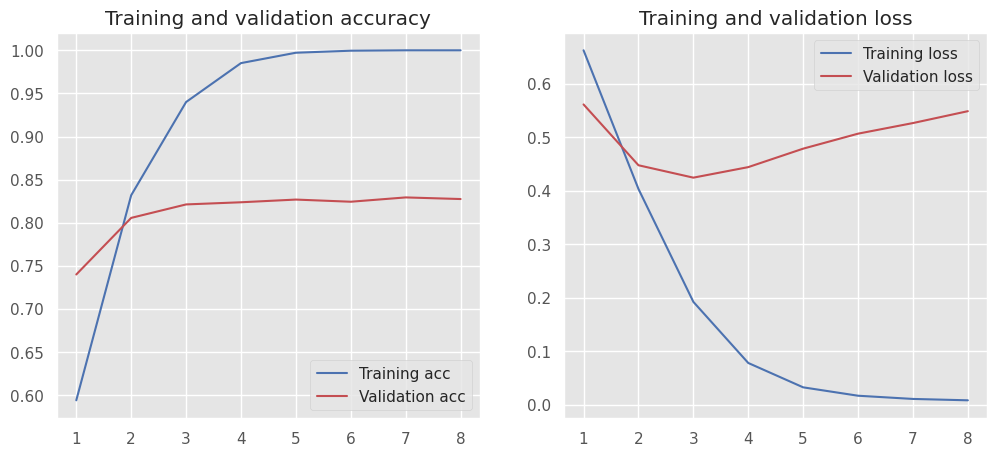

In [122]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5),
  criterion=criterion,
  patience=5)
plot_history(history)


CLASSIFICATION REPORT - BinaryClassificationTextCNN
              precision    recall  f1-score   support

    negative       0.83      0.83      0.83      1025
    positive       0.82      0.82      0.82       975

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

Confusion matrix, without normalization


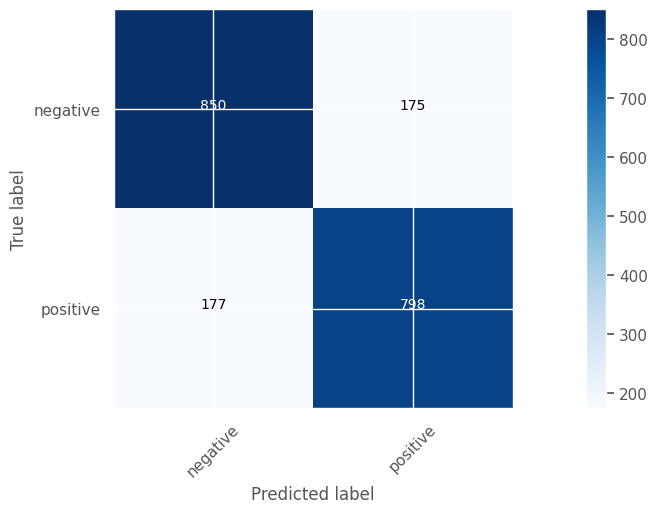


FINAL ACCURACY
0.8240 (82.40%)


In [123]:
y_pred = evaluate_pytorch_model(model, X_test_text, y_test, le, target_labels, device)

Embedded dim: torch.Size([1, 2000, 256])
Embedded dim transposed: torch.Size([1, 256, 2000])
First convolution shape: torch.Size([1, 20, 667])
Pooled shape: torch.Size([1, 20, 222])
Flattened shape: torch.Size([1, 4440])
Original text: director struggled maintain coherent narrative disjointed scene awkward dialogue made difficult stay engaged throughout unnecessarily long runtime cinematography felt uninspired cast seemed lack chemistry resulting performance felt wooden unconvincing
Prediction (0 negative, 1 positive): 0.0047
Decoded tokens: ['director', 'struggled', 'maintain', 'coherent', 'narrative', 'disjointed', 'scene', 'awkward', 'dialogue', 'made', 'difficult', 'stay', 'engaged', 'throughout', 'unnecessarily', 'long', 'runtime', 'cinematography', 'felt', 'uninspired', 'cast', 'seemed', 'lack', 'chemistry', 'resulting', 'performance', 'felt', 'wooden', 'unconvincing']


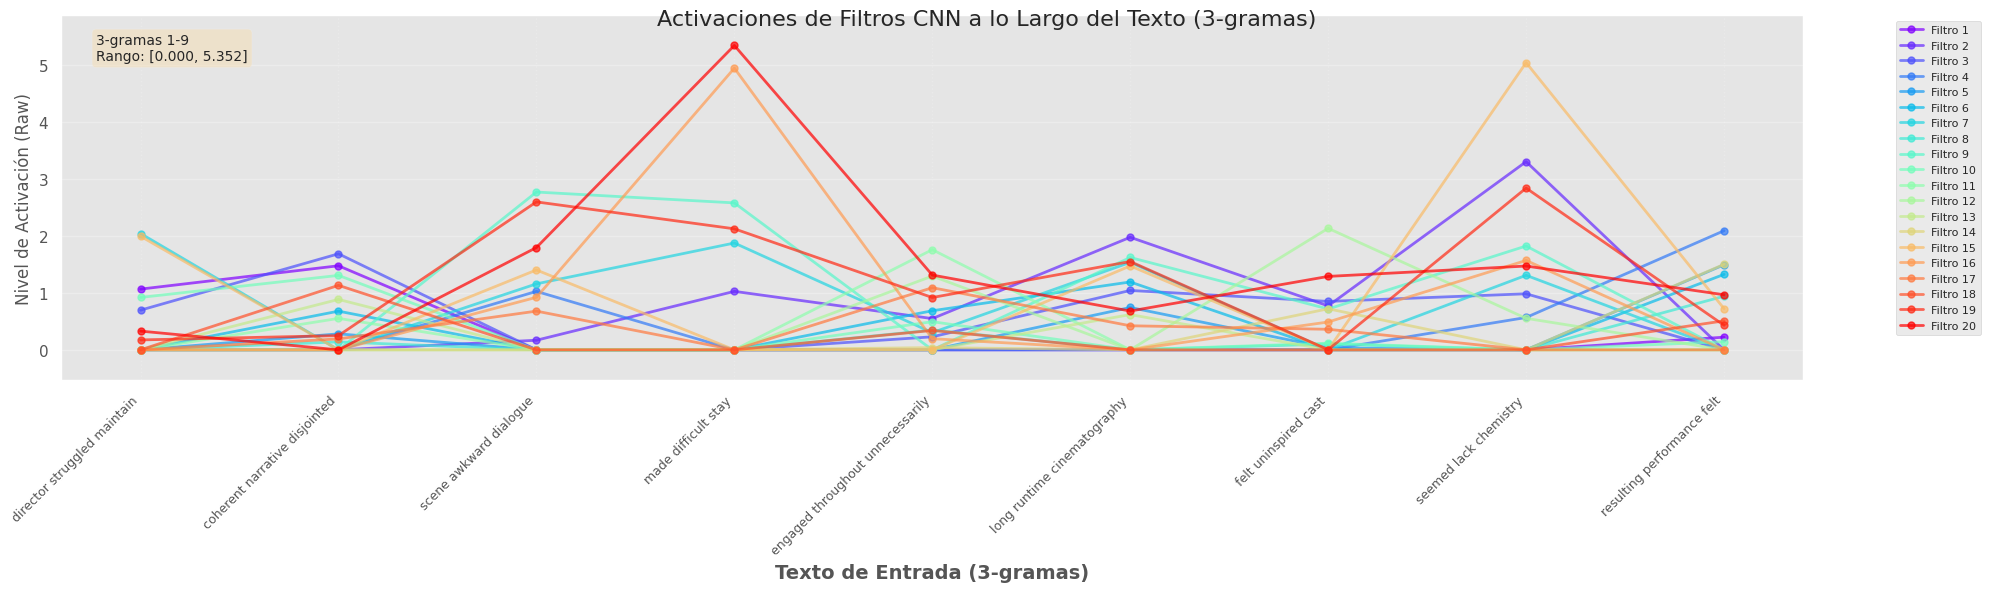


Texto analizado:
director struggled maintain coherent narrative disjointed scene awkward dialogue made difficult stay engaged throughout unnecessarily long runtime cinematography felt uninspired cast seemed lack chemistry resulting performance felt wooden unconvincing

Estadísticas:
Longitud del texto: 29 tokens
Tamaño del kernel: 3
Número de 3-gramas: 9
Número de filtros: 20
Número de subplots: 1
3-gramas por subplot: 20

Valores de activación:
Mínimo global: 0.0000
Máximo global: 5.3525
Media global: 0.5901
Desviación estándar: 0.9318


In [124]:
text = "The director struggled to maintain a coherent narrative with disjointed scenes and awkward dialogue that made it difficult to stay engaged throughout the unnecessarily long runtime, while the cinematography felt uninspired and the cast seemed to lack chemistry, resulting in performances that felt wooden and unconvincing."
processed_text = process_text(text, keep_numbers=True)
visualize_filter_activations_over_text(model, processed_text, tokenizer)

Ahora no debe haber solapamiento de los tri-gramas porque los saltos con el stride son más grandes. Se puede ver que el tri-grama "seemed lack chemistry" activa el filtro naranja claro 15.

Vamos a probar otra frase de prueba que tenga este tri-grama.

Embedded dim: torch.Size([1, 2000, 256])
Embedded dim transposed: torch.Size([1, 256, 2000])
First convolution shape: torch.Size([1, 20, 667])
Pooled shape: torch.Size([1, 20, 222])
Flattened shape: torch.Size([1, 4440])
Original text: director attempted ambitious story lead actor seemed lack chemistry making romantic subplot feel hollow unconvincing despite competent dialogue could not salvage disconnected performance throughout lengthy runtime
Prediction (0 negative, 1 positive): 0.0913
Decoded tokens: ['director', 'attempted', 'ambitious', 'story', 'lead', 'actor', 'seemed', 'lack', 'chemistry', 'making', 'romantic', 'subplot', 'feel', 'hollow', 'unconvincing', 'despite', 'competent', 'dialogue', 'could', 'not', 'salvage', 'disconnected', 'performance', 'throughout', 'lengthy', 'runtime']


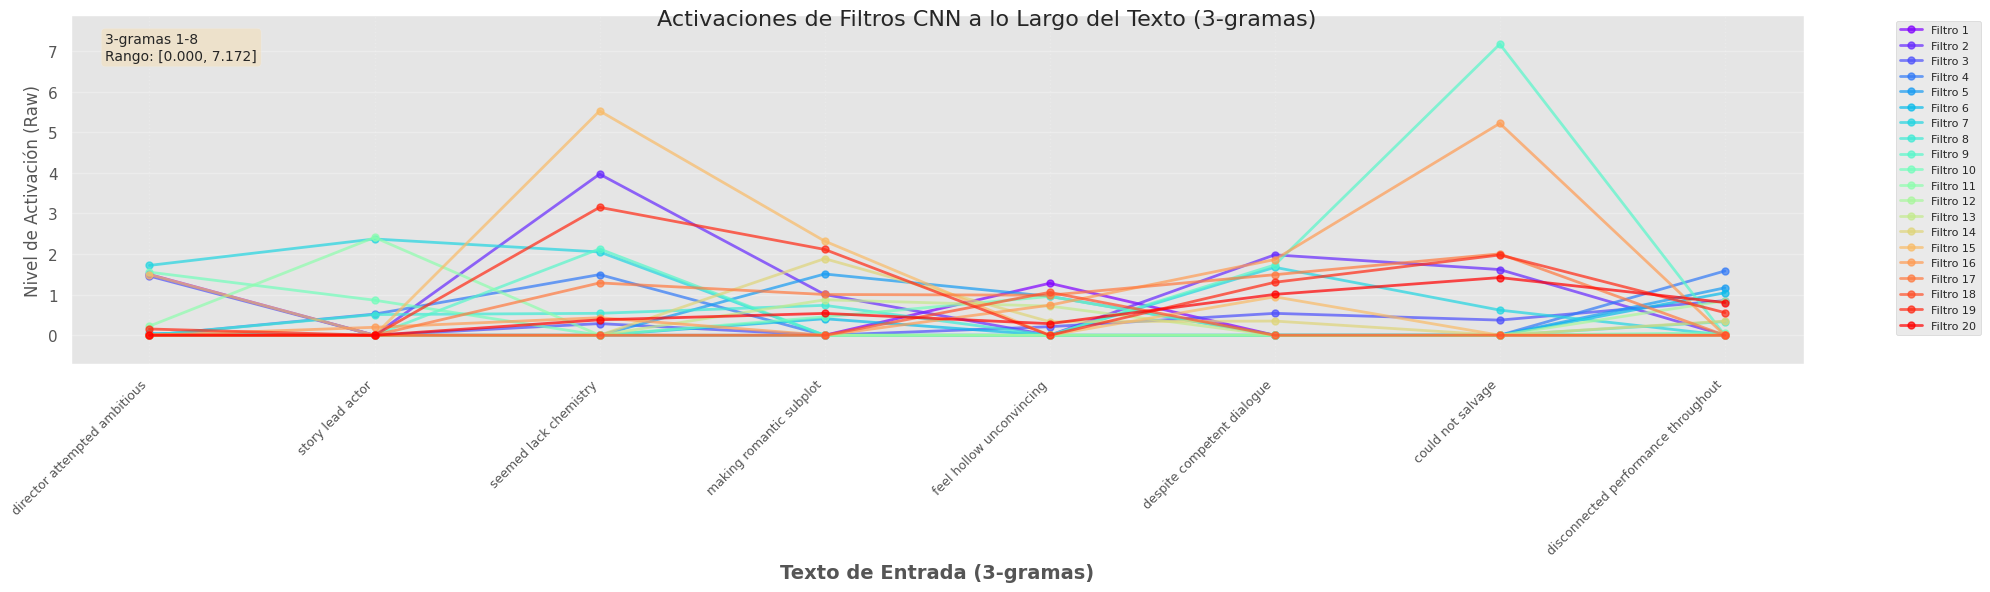


Texto analizado:
director attempted ambitious story lead actor seemed lack chemistry making romantic subplot feel hollow unconvincing despite competent dialogue could not salvage disconnected performance throughout lengthy runtime

Estadísticas:
Longitud del texto: 26 tokens
Tamaño del kernel: 3
Número de 3-gramas: 8
Número de filtros: 20
Número de subplots: 1
3-gramas por subplot: 20

Valores de activación:
Mínimo global: 0.0000
Máximo global: 7.1719
Media global: 0.6099
Desviación estándar: 1.0614


In [125]:
text = "The director attempted an ambitious story but the lead actors seemed to lack chemistry, making the romantic subplot feel hollow and unconvincing despite competent dialogue that couldn't salvage the disconnected performances throughout the lengthy runtime."
processed_text = process_text(text, keep_numbers=True)
visualize_filter_activations_over_text(model, processed_text, tokenizer)

Efectivamente, el mismo filtro (naranja claro 15) se activa cuando ve el mismo tri-grama "seemed lack chemistry".

## Experimento 4: K=5, S=1, P=2. Con dropout
Ahora, al mismo modelo le añadimos Dropout.

In [126]:
model = BinaryClassificationTextCNN(
    vocab_size=VOCAB_SIZE,
    embedding_dim=256,
    num_filters=20,
    filter_size=3,
    pool_size=3,
    stride=3, # Saltar 3 posiciones
    padding=1,  # Para K=3, S=1, P=1 mantiene el tamaño
    dropout=0.5
)
model = model.to(device)
print_model_info(model)
test_input = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_LENGTH), device=device)
_ = model(test_input, verbose=True)

MODEL ARCHITECTURE
BinaryClassificationTextCNN(
  (embedding): Embedding(41215, 256, padding_idx=0)
  (conv): Conv1d(256, 20, kernel_size=(3,), stride=(3,), padding=(1,))
  (pool): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         10,551,040      [41215, 256]        
conv.weight                              15,360          [20, 256, 3]        
conv.bias                                20              [20]                
--------------------------------------------------------------------------------
Total Parameters:                        10,566,420
Trainable Parameters:                    10,566,420
Non-trainable Parameters:                0
Model Size:                              40.31 MB
Embedded d

Train data shape: torch.Size([8000, 2000])
Train data dtype: torch.int64
Epoch 1/40 - loss: 0.6880 - acc: 0.5334 - val_loss: 0.6476 - val_acc: 0.6700
Epoch 2/40 - loss: 0.5310 - acc: 0.7480 - val_loss: 0.4573 - val_acc: 0.8037
Epoch 3/40 - loss: 0.3494 - acc: 0.8494 - val_loss: 0.3994 - val_acc: 0.8275
Epoch 4/40 - loss: 0.2310 - acc: 0.9100 - val_loss: 0.3723 - val_acc: 0.8481
 (patience: 1/5)
Epoch 5/40 - loss: 0.1531 - acc: 0.9489 - val_loss: 0.3759 - val_acc: 0.8475
 (patience: 2/5)
Epoch 6/40 - loss: 0.1149 - acc: 0.9617 - val_loss: 0.3914 - val_acc: 0.8506
 (patience: 3/5)
Epoch 7/40 - loss: 0.0844 - acc: 0.9727 - val_loss: 0.4074 - val_acc: 0.8481
 (patience: 4/5)
Epoch 8/40 - loss: 0.0669 - acc: 0.9784 - val_loss: 0.4371 - val_acc: 0.8481
 (patience: 5/5)
Early stopping triggered at epoch 9


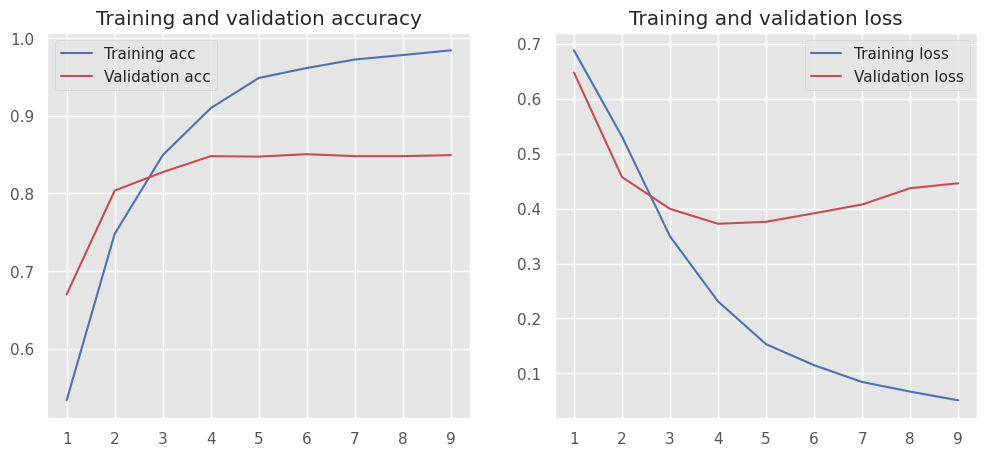

In [127]:
criterion = nn.BCELoss()

print(f"Train data shape: {X_train_text.shape}")
print(f"Train data dtype: {X_train_text.dtype}")

history = train_pytorch_model(
  model,
  X_train_text,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5),
  criterion=criterion,
  patience=5)
plot_history(history)

Embedded dim: torch.Size([1, 2000, 256])
Embedded dim transposed: torch.Size([1, 256, 2000])
First convolution shape: torch.Size([1, 20, 667])
Pooled shape: torch.Size([1, 20, 222])
Flattened shape: torch.Size([1, 4440])
Original text: director struggled maintain coherent narrative disjointed scene awkward dialogue made difficult stay engaged throughout unnecessarily long runtime cinematography felt uninspired cast seemed lack chemistry resulting performance felt wooden unconvincing
Prediction (0 negative, 1 positive): 0.0140
Decoded tokens: ['director', 'struggled', 'maintain', 'coherent', 'narrative', 'disjointed', 'scene', 'awkward', 'dialogue', 'made', 'difficult', 'stay', 'engaged', 'throughout', 'unnecessarily', 'long', 'runtime', 'cinematography', 'felt', 'uninspired', 'cast', 'seemed', 'lack', 'chemistry', 'resulting', 'performance', 'felt', 'wooden', 'unconvincing']


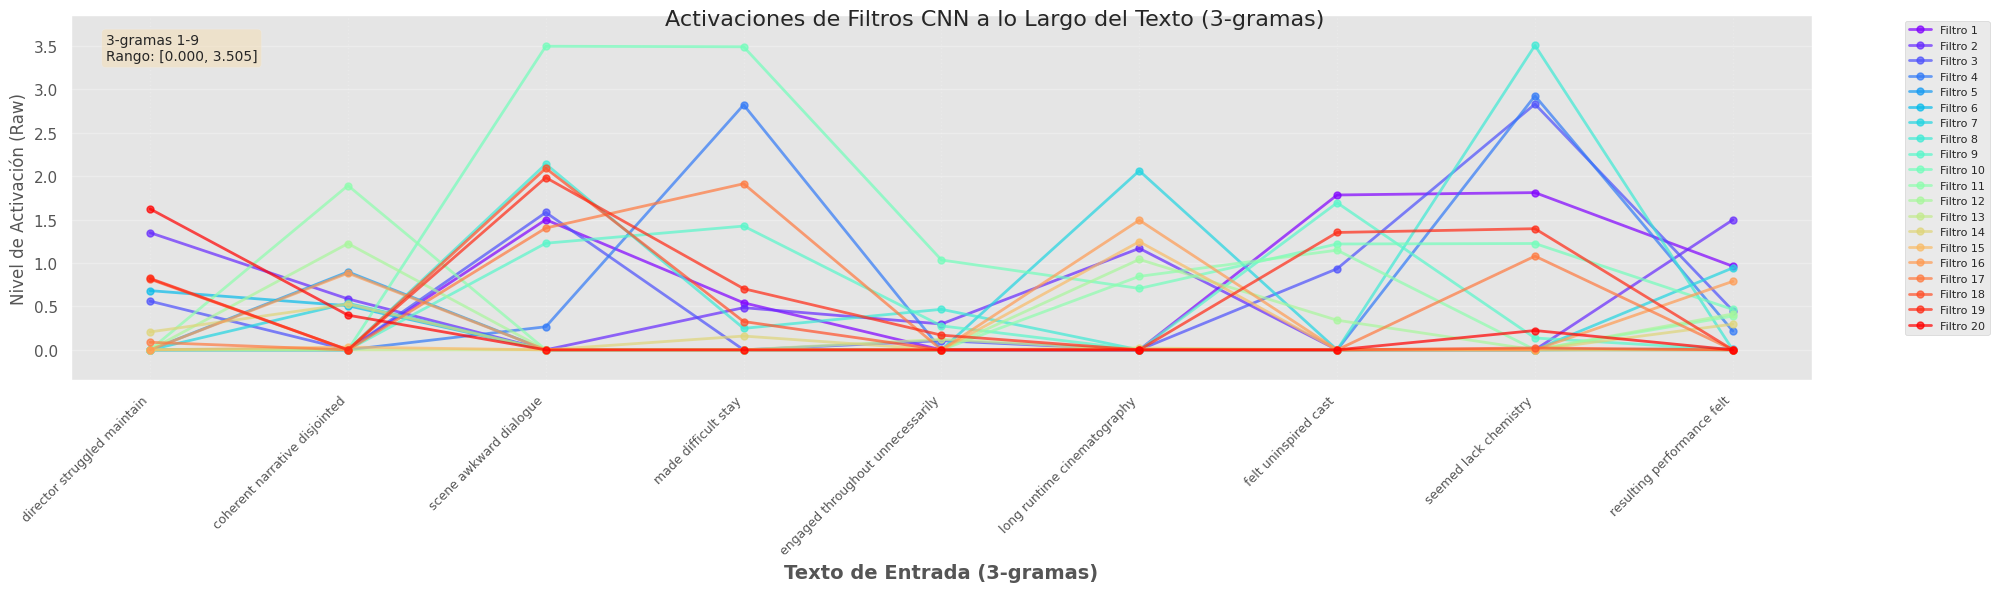


Texto analizado:
director struggled maintain coherent narrative disjointed scene awkward dialogue made difficult stay engaged throughout unnecessarily long runtime cinematography felt uninspired cast seemed lack chemistry resulting performance felt wooden unconvincing

Estadísticas:
Longitud del texto: 29 tokens
Tamaño del kernel: 3
Número de 3-gramas: 9
Número de filtros: 20
Número de subplots: 1
3-gramas por subplot: 20

Valores de activación:
Mínimo global: 0.0000
Máximo global: 3.5046
Media global: 0.4585
Desviación estándar: 0.7616


In [128]:
text = "The director struggled to maintain a coherent narrative with disjointed scenes and awkward dialogue that made it difficult to stay engaged throughout the unnecessarily long runtime, while the cinematography felt uninspired and the cast seemed to lack chemistry, resulting in performances that felt wooden and unconvincing."
processed_text = process_text(text, keep_numbers=True)
visualize_filter_activations_over_text(model, processed_text, tokenizer)

Embedded dim: torch.Size([1, 2000, 256])
Embedded dim transposed: torch.Size([1, 256, 2000])
First convolution shape: torch.Size([1, 20, 667])
Pooled shape: torch.Size([1, 20, 222])
Flattened shape: torch.Size([1, 4440])
Original text: director attempted ambitious story lead actor seemed lack chemistry making romantic subplot feel hollow unconvincing despite competent dialogue could not salvage disconnected performance throughout lengthy runtime
Prediction (0 negative, 1 positive): 0.0990
Decoded tokens: ['director', 'attempted', 'ambitious', 'story', 'lead', 'actor', 'seemed', 'lack', 'chemistry', 'making', 'romantic', 'subplot', 'feel', 'hollow', 'unconvincing', 'despite', 'competent', 'dialogue', 'could', 'not', 'salvage', 'disconnected', 'performance', 'throughout', 'lengthy', 'runtime']


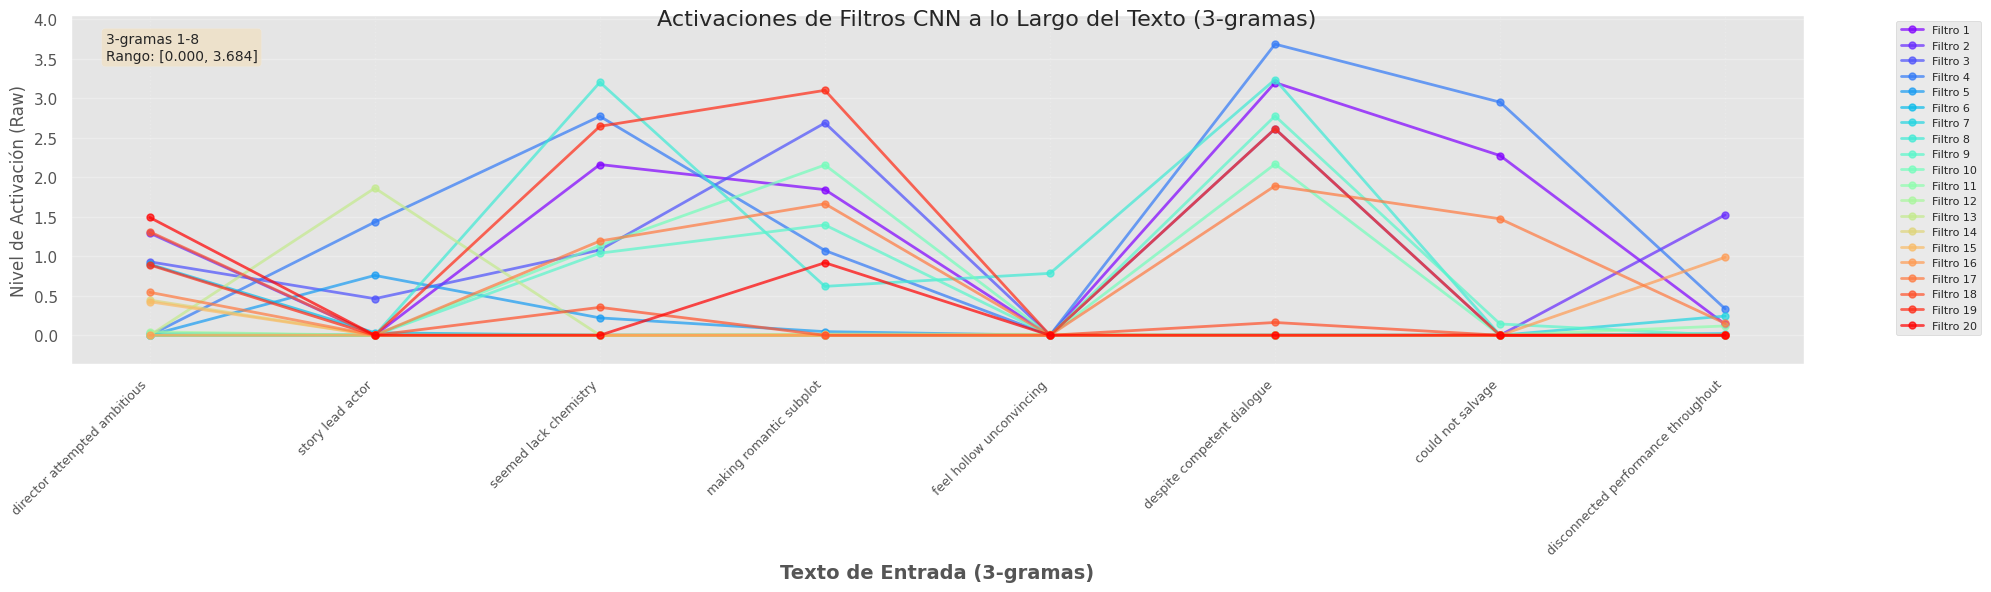


Texto analizado:
director attempted ambitious story lead actor seemed lack chemistry making romantic subplot feel hollow unconvincing despite competent dialogue could not salvage disconnected performance throughout lengthy runtime

Estadísticas:
Longitud del texto: 26 tokens
Tamaño del kernel: 3
Número de 3-gramas: 8
Número de filtros: 20
Número de subplots: 1
3-gramas por subplot: 20

Valores de activación:
Mínimo global: 0.0000
Máximo global: 3.6842
Media global: 0.4852
Desviación estándar: 0.8950


In [129]:
text = "The director attempted an ambitious story but the lead actors seemed to lack chemistry, making the romantic subplot feel hollow and unconvincing despite competent dialogue that couldn't salvage the disconnected performances throughout the lengthy runtime."
processed_text = process_text(text, keep_numbers=True)
visualize_filter_activations_over_text(model, processed_text, tokenizer)

Con dropout no sabría decir si hay mucha diferencia. Espera encontrar, que más filtros se activen a la vez en el mismo tri-grama si este fuese relevante para la clasificación. Es algo que pasa con el tri-grama "despite competent dialog".

Intuitivamente pensaba que el dropout hace que sea más probable que el resultado de la red no dependa de una única neurona, si no que se aprende a crear "redundancias".

# Conclusiones e ideas de los experimentos

De los resultados de esta tarea hay ciertas ideas clave que podemos extraer:

- Las capas **convolucionales no pueden extraer información relevante de los datos representados en TF-IDF**.
  La accuracy en entrenamiento y validación es alrededor de 53%, lo cual es un algoritmo practicamente
  aleatorio en un problema de clasificación binaria. La representación TF-IDF sí nos da información
  de la especificidad o cantidad de inforación de una palabra, pero se pierde información del orden de las palabras y
  su contexto. Las CNNs capturan patrones locales y por este motivo no son capaces de extraer características
  útiles para clasificar.

- La representación TF-IDF funciona mejor si se usa un modelo con MLP + CNN + MLP para clasificar. De aquí, el primer MLP
  convierte la **representación de entrada "sparse" en una representación más densa** que parece más útil para la capa
  convolucional.

- Después hemos cambiado a una representación aprendida basada en **word embeddings** como entrada a la capa convolucional. Se ha demostrado que
  esta representación es **más adecuada como entrada a las capas convolucionales** que la representación TF-IDF. Pienso que se debe a que los word
  embeddings mantienen el orden de la secuencia y además a cada palabra le dan una representación densa. De este tensor
  **[B, emb_dim, seq_len]** las convoluciones sí extraen patrones locales útiles.

- En estos experimentos hemos añadido **Dropout**. Se ha visto que con dropout durante el entrenamiento **se tarda más en hacer overfitting a los datos de entrenamiento**
  (el momento en el que la validation loss comienza a crecer y el training loss sigue disminuyendo). Entonces, dropout se puede usar como un **mecanismo de regularización**.
  Otras técnicas de regularización que hemos utilizado son: **Weight decay** y **Batch Normalization**. Con Weight decay sí se han obtenido mejores resultados.

- Después hemos probado con variantes de la arquitectura Word Embeddings + CNN + MLP. Hemos visto que ha ayudado una capa CNN con
  **diferentes tamaños del kernel en paralelo**. El modelo entonces es capaz de aprender qué tamaño del kernel es mejor o a combinarlos. Pienso que esta es una idea
  ya existente en arquitecturas de visión artificial como el módulo Inception.

- Por último, la combinación WE + CNN se ha utilizado para hacer experimentos y poder **"ver" las activaciones de la salida de filtros convolucionales**. Se ha visto que
  el mismo filtro se activa en el mismo n-grama si este está contenido en dos frases diferentes. Y hemos visto también como cambiar el stride modifica la visualización.

<!--
 Copyright 2025 Keybotic SL
  All Rights Reserved 
  
  Unauthorized copying of this file, via any medium is strictly prohibited, 
  unless it was supplied under the terms of a license agreement or 
  nondisclosure agreement with Keybotic SL. In this case it may not be 
  copied or disclosed except in accordance with the terms of that agreement.
-->

